# Lección 11.2 · Normalización y binomial negativa: factores de tamaño, dispersión y la relación media-varianza

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-11-rnaseq/11.2_normalizacion_binomial_negativa.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 11 — Transcriptómica (RNA-seq)** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Intermedio-avanzado | Lección 11.1 (de lecturas a conteos), distribuciones binomial y de Poisson (Lección 6.3), máxima verosimilitud básica, NumPy y pandas |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** por qué dividir por el total de lecturas (CPM) no basta para comparar un gen entre muestras: el
   **efecto de composición** $\mathbb E[K_{ij}]=N_j\,\mu_{ij}L_i/S_j$.
2. **Calcular** a mano y en código los dos normalizadores estándar: la **media recortada de cocientes (TMM)** de edgeR
   y la **mediana de razones** de DESeq/DESeq2, y **reproducir** los ejemplos del libro
   ($\log_2 f=-0{,}461$; $\hat s=0{,}691;\ 1{,}525;\ 0{,}939$).
3. **Derivar** la binomial negativa como **mezcla gamma-Poisson** y su varianza $\mu+\alpha\mu^2$ con la ley de la
   varianza total, e **interpretar** cada sumando (ruido de muestreo frente a variación biológica).
4. **Leer** la relación media-varianza de datos reales y **argumentar** cuantitativamente por qué más réplicas valen
   más que más profundidad.
5. **Escribir** el modelo lineal generalizado binomial negativo de DESeq2 con **factor de tamaño como desplazamiento**
   y un diseño pareado (`~ línea celular + dexametasona`), y **ajustarlo** con IRLS.
6. **Estimar** dispersiones en tres pasos (gen a gen con Cox-Reid → tendencia $a_0+a_1/\bar\mu$ → contracción
   *a posteriori*) desde cero sobre los conteos reales del experimento *airway*.
7. **Aplicar** la transformación estabilizadora de varianza (VST) y **usar** PCA y distancias entre muestras como
   **control de calidad**, hasta detectar un probable **intercambio de etiquetas** en los metadatos públicos.

## 🗺️ Mapa de la clase

0. El experimento: corticoides en músculo liso de vía aérea (*airway*, Himes et al., 2014)
1. Qué hay que corregir: profundidad y composición
2. El efecto de composición en una simulación (🎬 animación)
3. TMM: media recortada de cocientes
4. La mediana de razones (ejemplo a mano y 🎛️ factores de las 16 muestras reales)
5. De Poisson a la binomial negativa (🎛️ explorador de la dispersión)
6. La relación media-varianza: simulada y real
7. El modelo lineal generalizado y sus pesos IRLS
8. Estimar la dispersión con pocas réplicas: contracción (🎬 animación, 🎛️ dispersiones reales)
9. Conteos normalizados para mirar: VST y control de calidad de las 16 muestras (🎛️ PCA)
10. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, time
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats, special, optimize

t_start = time.time()
RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name):
    """Lee un archivo del curso: 1) copia local ../data; 2) copia del repositorio en GitHub. Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    with urllib.request.urlopen(f"{RAW}/data/{name}", timeout=120) as r:
        return r.read()

print("Listo para la Lección 11.2")

Entorno listo ✔  |  Colab: False


Listo para la Lección 11.2


## 0. El experimento: corticoides en músculo liso de vía aérea

Los **glucocorticoides** inhalados (budesonida, fluticasona…) son la base del tratamiento del asma persistente. Actúan
sobre el **receptor de glucocorticoides** (GR), un factor de transcripción: al unir el fármaco, el GR entra al núcleo y
enciende o apaga cientos de genes. ¿Cuáles, en las células que contraen los bronquios? Himes y colaboradores (2014)
lo midieron con RNA-seq en **músculo liso de vía aérea humana** de **cuatro donantes** (cuatro líneas celulares
primarias), cada una tratada 18 horas de cuatro maneras: sin tratar, **dexametasona** (un corticoide potente),
**albuterol** (un broncodilatador agonista β2) y la combinación. Son 16 bibliotecas, depositadas en GEO (GSE52778) y
SRA (SRP033351). Es el conjunto de datos con el que la documentación de DESeq2 enseña el análisis de expresión
diferencial, y será nuestro hilo en todo el Módulo 11.

Los conteos que usamos provienen de **recount3** (Wilks et al., 2021), que reprocesó de manera uniforme todo SRA:
alineó las lecturas al genoma humano, sumó la **cobertura base a base** sobre los exones de cada gen de GENCODE v26 y
la dividió por el número de bases por fragmento, **redondeando** al entero. Es una aproximación muy buena del número
de fragmentos por gen, con una salvedad que veremos en la sección 8: los genes con parientes casi idénticos en el
genoma (pseudogenes procesados) reciben lecturas ambiguas.

El **diseño principal** del módulo es el mismo que en la viñeta de DESeq2: las **8 muestras sin tratar frente a
dexametasona**, pareadas por línea celular. Las 16 muestras reaparecerán en la sección 9, en el control de calidad.

In [2]:
counts = pd.read_csv(io.BytesIO(course_bytes("airway_SRP033351_counts.tsv.gz")), sep="\t", compression="gzip")
samples = pd.read_csv(io.BytesIO(course_bytes("airway_SRP033351_samples.tsv")), sep="\t")
RUNS = samples["run"].tolist()
K_all = counts[RUNS].to_numpy(dtype=float)          # matriz genes × muestras de conteos crudos K_ij
SYMBOL = counts["symbol"].to_numpy()
GTYPE = counts["gene_type"].to_numpy()

TREAT_ES = {"Untreated": "sin tratar", "Dexamethasone": "dexametasona", "Albuterol": "albuterol",
            "Albuterol_Dexamethasone": "albuterol + dexametasona"}
samples["tratamiento"] = samples["treatment"].map(TREAT_ES)
samples["N_asignadas"] = K_all.sum(axis=0).astype(int)   # lecturas asignadas a genes (N_j)
print(f"{K_all.shape[0]:,} genes × {K_all.shape[1]} muestras".replace(",", " "))
print(counts["gene_type"].value_counts().head(4).to_string())
samples[["run", "cell", "tratamiento", "spots", "N_asignadas"]]

39 123 genes × 16 muestras
gene_type
protein_coding          17883
processed_pseudogene     6299
antisense                4370
lincRNA                  4077


,run,cell,tratamiento,spots,N_asignadas
0,SRR1039508,N61311,sin tratar,22935521,20715203
1,SRR1039509,N61311,dexametasona,21155707,19020171
2,SRR1039510,N61311,albuterol,22852619,20810459
3,SRR1039511,N61311,albuterol + dexametasona,21938637,20050651
4,SRR1039512,N052611,sin tratar,28136282,25861510
5,SRR1039513,N052611,dexametasona,43356464,40820460
6,SRR1039514,N052611,albuterol,40021727,36164336
7,SRR1039515,N052611,albuterol + dexametasona,29454748,26837228
8,SRR1039516,N080611,sin tratar,30043024,27682312
9,SRR1039517,N080611,dexametasona,34298260,31298313


> 🔎 **Qué observamos.** Tenemos 39 123 genes de GENCODE (codificantes, ARN largos no codificantes, pseudogenes…) y
> 16 muestras. La columna `spots` es el número de pares de lecturas secuenciados; `N_asignadas` es la suma de
> conteos por gen, del orden de 20–40 millones. Ya a simple vista las profundidades difieren casi al doble
> (SRR1039509 frente a SRR1039513): sin corregir eso, cualquier gen parecería «más expresado» en SRR1039513.

## 1. Qué hay que corregir: profundidad y composición

Empecemos por una escena de todos los días. Seis amigos piden una pizza de ocho porciones y cada uno come más o menos
lo mismo. Al día siguiente vuelven con un séptimo invitado, un adolescente hambriento que se come **la mitad** de la
pizza. Si solo le enseñan la **fracción** de pizza que comió cada uno, usted concluirá que los seis amigos perdieron
el apetito: cada uno comió un doceavo en lugar de un sexto. Pero nadie cambió de hábitos salvo el invitado; lo que
cambió es el **denominador**. El RNA-seq mide exactamente fracciones de una pizza de tamaño fijo, las lecturas de la
muestra, y un puñado de genes muy expresados puede hacer que todos los demás parezcan disminuir.

### 1.1 La corrección obvia: conteos por millón

El conteo $K_{ij}$ del gen $i$ en la muestra $j$ depende de su expresión, pero también de factores técnicos: la
**profundidad** de secuenciación, la **longitud** del gen, su contenido en GC y la **composición** del transcriptoma.
Para comparar **un mismo gen** entre muestras, la longitud se cancela (salvo cambios de isoforma, que `tximport`
corrige; Lección 11.1), y lo esencial es la profundidad y la composición.

La corrección más obvia divide por el total de lecturas: los **conteos por millón**,

$$
\mathrm{CPM}_{ij}=\frac{10^6\,K_{ij}}{N_j}.
$$

### 1.2 Qué esperamos observar

Escribamos el modelo. Si $\mu_{ij}$ es el número de moléculas del gen $i$ en la muestra $j$ y $L_i$ su longitud, la
fracción de lecturas que produce es $\mu_{ij}L_i/S_j$ (un transcrito más largo aporta más fragmentos), así que

$$
\boxed{\;\mathbb E[K_{ij}]=N_j\,\frac{\mu_{ij}L_i}{S_j},\qquad S_j=\sum_{g=1}^{G}\mu_{gj}L_g\;}
\qquad\text{(ecuación 11-composición del libro)}
$$

| Símbolo | Significado |
|---|---|
| $K_{ij}$ | conteo observado del gen $i$ en la muestra $j$ |
| $N_j$ | total de lecturas asignadas en la muestra $j$ (profundidad) |
| $\mu_{ij},\ L_i$ | número de moléculas del gen $i$ en la muestra $j$ y longitud del gen |
| $S_j$ | «producción total de ARN» de la muestra: el tamaño de la pizza |
| $G$ | número de genes |

Dividir por $N_j$ elimina la profundidad, pero **deja el denominador $S_j$**:
$\mathbb E[\mathrm{CPM}_{ij}]=10^6\,\mu_{ij}L_i/S_j$. Si un conjunto de genes se dispara en la muestra B, $S_B$
crece y **todos los demás** genes ven reducida su fracción aunque su $\mu$ no haya cambiado.

**Ejemplo a mano.** Una muestra A con 4 genes de igual longitud y 10 moléculas cada uno: $S_A=40$, cada gen se lleva
el 25 % de las lecturas. En B el gen 4 sube a 40 moléculas: $S_B=70$, y los genes 1–3 pasan a $10/70=14{,}3\,\%$.
Con 10 millones de lecturas en cada muestra, sus CPM caen de 250 000 a 142 857: un «descenso» de
$\log_2(142\,857/250\,000)=-0{,}81$ en genes que no cambiaron.

¿Cuánto de la pizza se comen unos pocos genes en nuestros datos reales? Calculemos qué fracción de las lecturas se
llevan los 20 genes más expresados de cada muestra.

In [3]:
# Fracción de las lecturas de cada muestra que acaparan sus 20 genes más expresados
frac_top = {}
for j, run in enumerate(RUNS):
    col = K_all[:, j]
    top = np.argsort(-col)[:20]
    frac_top[run] = col[top].sum() / col.sum()
samples["frac_top20"] = samples["run"].map(frac_top)

# ¿Qué genes son? (media de CPM en las 16 muestras)
cpm_all = K_all / K_all.sum(axis=0) * 1e6
mean_cpm = cpm_all.mean(axis=1)
top_genes = np.argsort(-mean_cpm)[:12]
print("Los 12 genes con más lecturas (CPM medio):")
for i in top_genes:
    print(f"  {SYMBOL[i]:<10} {GTYPE[i]:<16} {mean_cpm[i]:>9.0f} CPM  ({mean_cpm[i] / 1e4:.1f} % de las lecturas)")
print(f"\nLos 20 genes más expresados acaparan entre {samples.frac_top20.min():.1%} y {samples.frac_top20.max():.1%} de cada muestra")

Los 12 genes con más lecturas (CPM medio):
  FN1        protein_coding       13476 CPM  (1.3 % de las lecturas)
  DCN        protein_coding       13048 CPM  (1.3 % de las lecturas)
  MT-CO1     protein_coding       10039 CPM  (1.0 % de las lecturas)
  COL1A2     protein_coding        8809 CPM  (0.9 % de las lecturas)
  QSOX1      protein_coding        8504 CPM  (0.9 % de las lecturas)
  IGFBP5     protein_coding        8080 CPM  (0.8 % de las lecturas)
  CCDC80     protein_coding        7533 CPM  (0.8 % de las lecturas)
  FBLN1      protein_coding        7103 CPM  (0.7 % de las lecturas)
  FTL        protein_coding        6932 CPM  (0.7 % de las lecturas)
  MMP2       protein_coding        5612 CPM  (0.6 % de las lecturas)
  GREM1      protein_coding        5557 CPM  (0.6 % de las lecturas)
  EEF1A1P5   processed_pseudogene      5149 CPM  (0.5 % de las lecturas)

Los 20 genes más expresados acaparan entre 11.3% y 15.4% de cada muestra


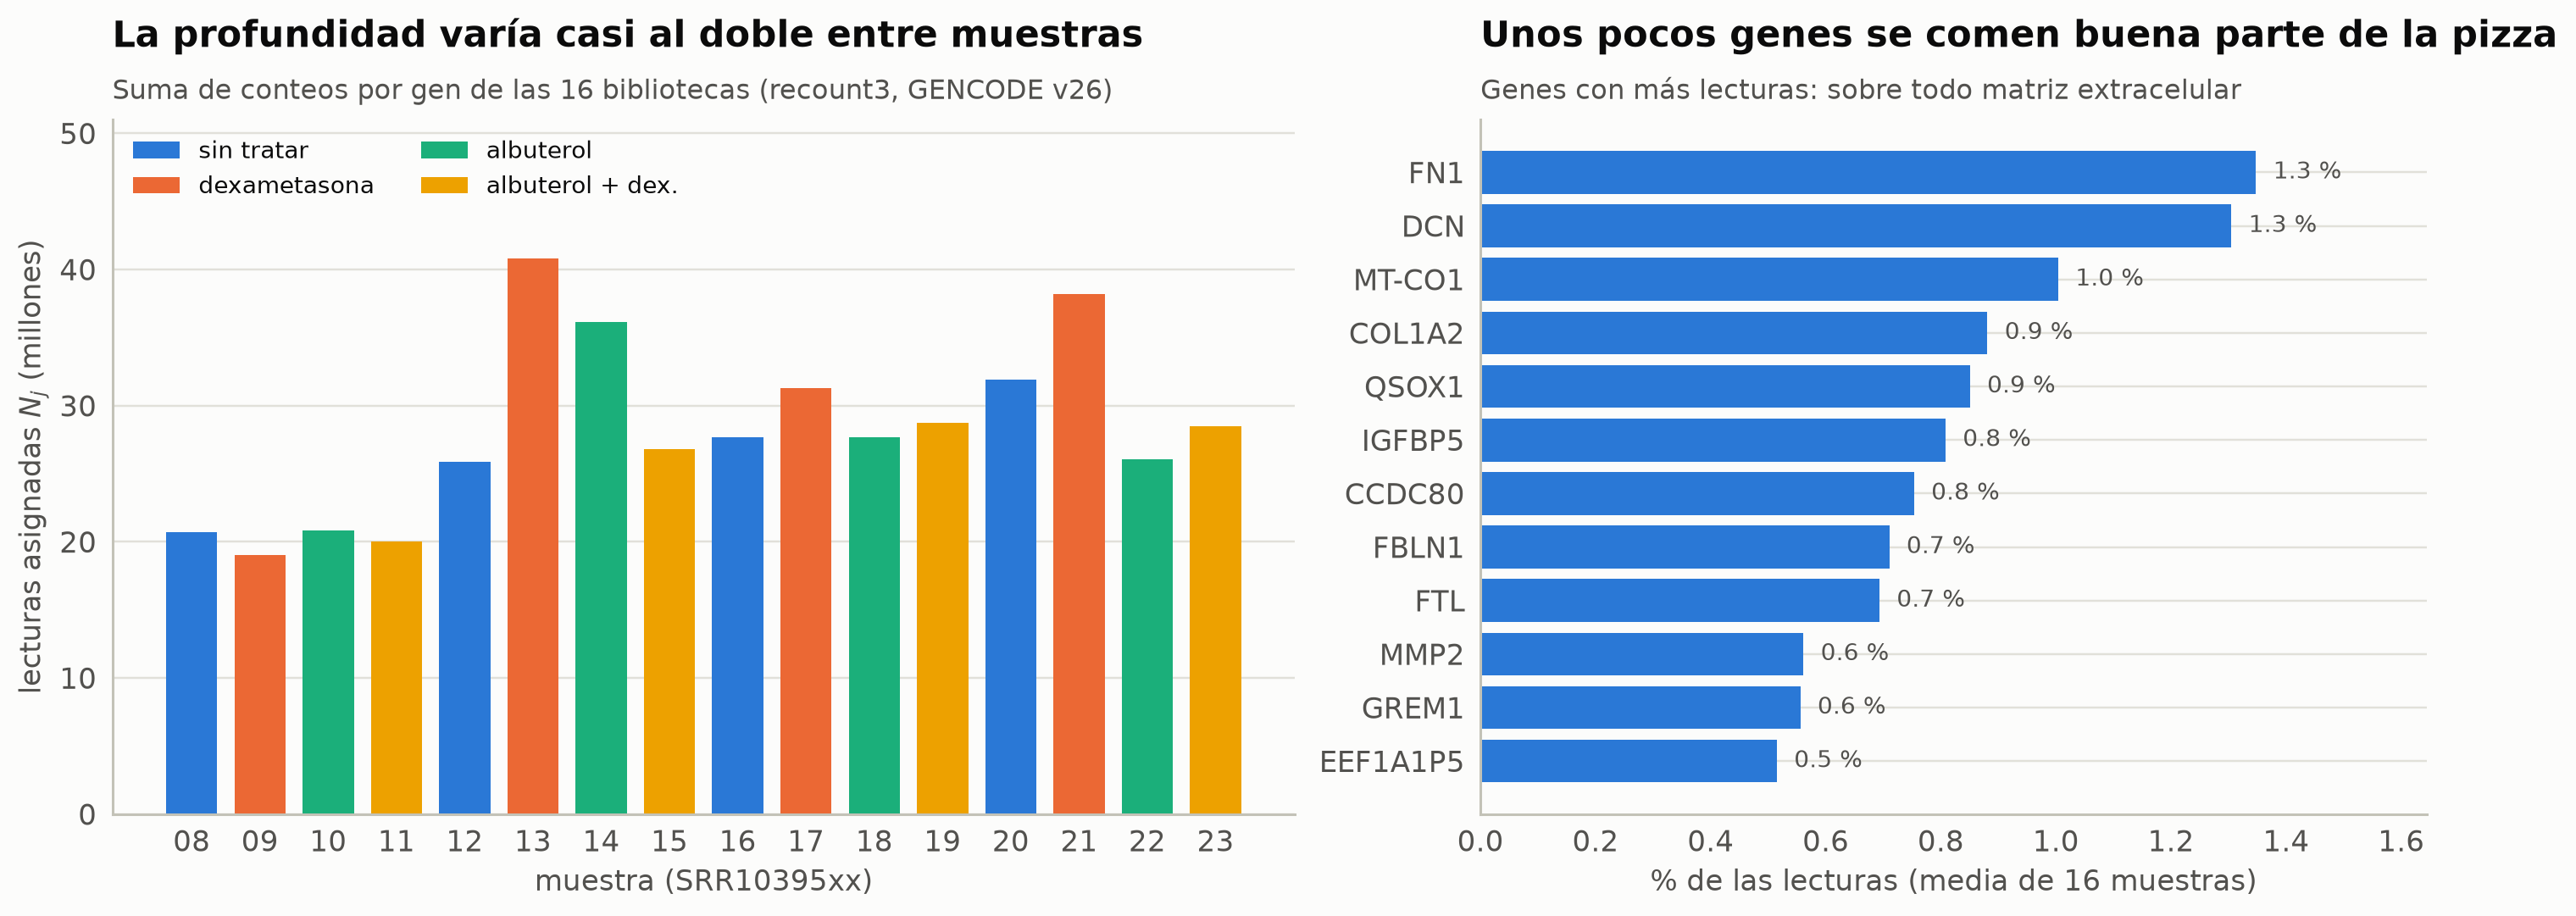

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw=dict(width_ratios=[1.25, 1]))
ax = axes[0]
order_s = np.arange(16)
cols = [ec.CATEGORICAL[["Untreated", "Dexamethasone", "Albuterol", "Albuterol_Dexamethasone"].index(t)]
        for t in samples.treatment]
ax.bar(order_s, samples.N_asignadas / 1e6, color=cols, width=0.75)
ax.set_xticks(order_s, [r[-2:] for r in RUNS])
ax.set_xlabel("muestra (SRR10395xx)"); ax.set_ylabel("lecturas asignadas $N_j$ (millones)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=ec.CATEGORICAL[k], label=t) for k, t in
                   enumerate(["sin tratar", "dexametasona", "albuterol", "albuterol + dex."])],
          loc="upper left", ncol=2, frameon=False, fontsize=9)
ax.set_ylim(0, samples.N_asignadas.max() / 1e6 * 1.25)
ec.title(ax, "La profundidad varía casi al doble entre muestras",
         "Suma de conteos por gen de las 16 bibliotecas (recount3, GENCODE v26)")
ax = axes[1]
ax.barh(np.arange(12)[::-1], mean_cpm[top_genes] / 1e4, color=ec.BLUE)
ax.set_yticks(np.arange(12)[::-1], SYMBOL[top_genes])
ax.set_xlabel("% de las lecturas (media de 16 muestras)")
for y, v in zip(np.arange(12)[::-1], mean_cpm[top_genes] / 1e4):
    ax.text(v + 0.03, y, f"{v:.1f} %", va="center", fontsize=9, color=ec.INK_2)
ax.set_xlim(0, (mean_cpm[top_genes] / 1e4).max() * 1.22)
ec.title(ax, "Unos pocos genes se comen buena parte de la pizza",
         "Genes con más lecturas: sobre todo matriz extracelular")
plt.show()

> 🔎 **Qué observamos.** Izquierda: la profundidad $N_j$ va de unos 19 a unos 41 millones; hay que corregirla.
> Derecha: los genes más expresados de estas células de músculo liso son sobre todo proteínas de **matriz
> extracelular** y su entorno (fibronectina *FN1*, decorina *DCN*, colágeno *COL1A2*, *IGFBP5*, *CCDC80*, fibulina
> *FBLN1*, la metaloproteasa *MMP2*), además de *MT-CO1* (mitocondrial) y un pseudogén del factor de elongación
> (*EEF1A1P5*), que recibe lecturas ambiguas de su gen parental. Esa docena de genes suma alrededor del 10 % de las
> lecturas, y los 20 primeros, entre el 11 % y el 15 % según la muestra. Si un tratamiento duplicara la producción
> de matriz, el denominador $S_j$ subiría de forma apreciable y **todos** los demás genes parecerían bajar con CPM.

## 2. El efecto de composición en una simulación

Robinson y Oshlack (2010) documentaron el efecto con datos reales de hígado y riñón: una parte pequeña de genes muy
expresados en un tejido basta para sesgar el cociente de todos los demás, y la normalización por total convierte ese
sesgo en **miles de falsos positivos**. Para verlo con toda claridad usamos una simulación en la que conocemos la
verdad: **la misma del libro** (figura 11-composición). Dos muestras, A y B, con 4 000 genes y la misma profundidad;
en B, un 5 % de los genes (200) multiplica por **ocho** su expresión. Los demás no cambian.

> 📐 **Reproducir el libro al pie de la letra.** El libro genera todas sus simulaciones del capítulo con **un solo**
> generador de números aleatorios (`default_rng(11)`) y en un orden fijo: primero la nube media-varianza (sección 6),
> luego las dos muestras de composición y por último el experimento 3 frente a 3 (sección 8). Para obtener
> **exactamente** las mismas cifras replicamos ese orden de sorteos en una sola función y guardamos los tres
> «mundos» simulados. Las secciones posteriores los usan sin volver a sortear.

In [5]:
def nb_rvs(mu, a, rng, size=None):
    """Binomial negativa con media mu y dispersión a (Var = mu + a·mu²), como mezcla gamma-Poisson."""
    r = 1.0 / a
    lam = rng.gamma(r, mu / r, size=size)       # expresión "verdadera" de cada réplica biológica
    return rng.poisson(lam)                      # muestreo de lecturas

def book_worlds(seed=11):
    """Replica, sorteo a sorteo, las simulaciones de la sección 11.2 del libro (figuras/cap11/generar.py)."""
    rng = np.random.default_rng(seed)
    W = {}
    # (a) nube media-varianza: 1 500 genes, 6 réplicas técnicas (Poisson) y 6 biológicas (NB, alpha = 0,1)
    mus = np.exp(rng.uniform(np.log(0.5), np.log(2e4), 1500))
    W["mv_pois"] = rng.poisson(np.repeat(mus[:, None], 6, 1))
    W["mv_nb"] = nb_rvs(np.repeat(mus[:, None], 6, 1), 0.1, rng)
    # (b) composición: 4 000 genes; 5 % se multiplican por 8 en la muestra B
    Gc = 4000
    lam = np.exp(rng.normal(3.5, 1.6, Gc))
    lamB = lam.copy()
    up = rng.choice(Gc, int(0.05 * Gc), replace=False)
    lamB[up] *= 8.0
    xa = rng.poisson(lam * 1.0)
    _ = rng.poisson(lamB * 1.0)                  # el libro sortea aquí una muestra B que luego reemplaza
    xb = rng.poisson(lamB * xa.sum() / lamB.sum())   # B con la misma profundidad total que A
    W.update(lam=lam, up=up, xa=xa, xb=xb)
    keep = (xa > 0) & (xb > 0)
    W["sub_comp"] = rng.choice(keep.sum(), 2500, replace=False)   # submuestra que dibuja la figura del libro
    # (c) experimento 3 frente a 3 (10 000 genes, 10 % diferencialmente expresados)
    G = 10000
    glen = np.exp(rng.normal(np.log(2000), 0.8, G))
    rate = np.exp(rng.normal(-4.2, 1.2, G))
    q0 = rate * glen
    disp = (0.05 + 1.0 / q0) * np.exp(rng.normal(0, 0.3, G))   # dispersión verdadera: tendencia × ruido
    de = rng.random(G) < 0.10
    lfc = np.zeros(G)
    lfc[de] = (0.5 + rng.exponential(0.8, de.sum())) * rng.choice([-1, 1], de.sum())
    s_true = np.array([0.8, 1.2, 1.0, 0.9, 1.3, 1.1])
    cond = np.array([0, 0, 0, 1, 1, 1])
    mu = q0[:, None] * 2 ** (lfc[:, None] * cond[None, :]) * s_true[None, :]
    Y = nb_rvs(mu, disp[:, None], rng)
    kg = Y.sum(1) > 0
    W.update(Y=Y[kg], de=de[kg], lfc=lfc[kg], disp=disp[kg], s_true=s_true, cond=cond)
    W["rng"] = rng                               # por si se quiere seguir sorteando como el libro
    return W

BOOK = book_worlds()
xa, xb, up = BOOK["xa"], BOOK["xb"], BOOK["up"]
NA, NB_ = xa.sum(), xb.sum()
print(f"N_A = {NA}, N_B = {NB_}   (libro: 482229 y 482264)")
print(f"fracción de lecturas de B en los genes 'up' = {xb[up].sum() / NB_:.3f} (en A: {xa[up].sum() / NA:.3f});"
      "  libro: 0.327 y 0.057")

N_A = 482229, N_B = 482264   (libro: 482229 y 482264)
fracción de lecturas de B en los genes 'up' = 0.327 (en A: 0.057);  libro: 0.327 y 0.057


Con dos muestras se dibuja el **gráfico MA**: para cada gen, en el eje $x$ la expresión media $A$ y en el eje $y$ el
cociente logarítmico $M$ entre B y A, ambos en escala $\log_2$ CPM. Si nada cambiara, la nube estaría centrada en
$M=0$.

¿Cuánto **debería** bajar el centro? Los genes sin cambio conservan sus moléculas, pero la pizza de B es más grande:
$S_B/S_A=1+7\sum_{i\in\text{up}}\lambda_i/\sum_i\lambda_i$. El desplazamiento teórico es
$\log_2(S_A/S_B)$, que el libro calcula en $-0{,}486$.

> 🤔 **Antes de ejecutar, prediga…** Los genes «up» de B pasan del 6 % al 33 % de las lecturas. ¿Cuánto bajará,
> aproximadamente, el CPM de un gen que no cambió? (Pista: si el resto de la pizza pasa del 94 % al 67 %…)

In [6]:
keep = (xa > 0) & (xb > 0)
M = np.log2((xb[keep] / NB_) / (xa[keep] / NA))
A = 0.5 * np.log2((xb[keep] / NB_) * (xa[keep] / NA)) + np.log2(1e6)     # en escala log2 CPM
is_up = np.isin(np.where(keep)[0], up)
lam = BOOK["lam"]
theo = np.log2(1 / (1 + (lam[up].sum() * 7) / lam.sum()))
print(f"mediana de M en genes sin cambio = {np.median(M[~is_up]):.3f}   (libro: -0.485)")
print(f"desplazamiento teórico log2(S_A/S_B) = {theo:.3f}   (libro: -0.486)")
print(f"regla rápida: log2(0.673/0.943) = {np.log2((1 - 0.327) / (1 - 0.057)):.3f}")

mediana de M en genes sin cambio = -0.485   (libro: -0.485)
desplazamiento teórico log2(S_A/S_B) = -0.486   (libro: -0.486)
regla rápida: log2(0.673/0.943) = -0.487


> ✅ **Compruebe su comprensión.** La regla rápida de la última línea usa sólo las fracciones de lecturas que **no**
> son de los genes «up» en cada muestra (67,3 % y 94,3 %). ¿Por qué da prácticamente el mismo número que la fórmula
> teórica con $S_A$ y $S_B$? *(Porque ambas miden cuánto «espacio» de la biblioteca les queda a los genes que no
> cambiaron.)*

Antes de corregir nada, preparemos los dos normalizadores que el libro compara en esta figura. Los explicaremos con
calma en las secciones 3 y 4; por ahora basta saber que ambos buscan el **centro de la nube de genes que no
cambian**.

In [7]:
def tmm_factor(obs, ref, logratio_trim=0.3, sum_trim=0.05):
    """Factor TMM de la muestra `obs` respecto a la referencia `ref` (Robinson y Oshlack, 2010).
    Recorta el 30 % de cada cola de M y el 5 % de cada cola de A, y promedia M con pesos 1/varianza."""
    obs, ref = np.asarray(obs, float), np.asarray(ref, float)
    n_o, n_r = obs.sum(), ref.sum()
    ok = (obs > 0) & (ref > 0)
    o, r = obs[ok], ref[ok]
    Mg = np.log2((o / n_o) / (r / n_r))
    Ag = 0.5 * np.log2((o / n_o) * (r / n_r))
    v = (n_o - o) / n_o / o + (n_r - r) / n_r / r            # varianza aproximada de M (método delta) = 1/w
    n = len(Mg)
    lo_m, hi_m = np.floor(n * logratio_trim) + 1, n + 1 - np.floor(n * logratio_trim)
    lo_a, hi_a = np.floor(n * sum_trim) + 1, n + 1 - np.floor(n * sum_trim)
    rm, ra = stats.rankdata(Mg), stats.rankdata(Ag)
    sel = (rm >= lo_m) & (rm <= hi_m) & (ra >= lo_a) & (ra <= hi_a)   # conjunto R del doble recorte
    return 2 ** (np.sum(Mg[sel] / v[sel]) / np.sum(1 / v[sel]))

def size_factors(K):
    """Mediana de razones (DESeq): K es la matriz genes × muestras de conteos crudos."""
    K = np.asarray(K, dtype=float)
    ok = (K > 0).all(axis=1)                  # genes sin ceros
    logK = np.log(K[ok])
    log_geo = logK.mean(axis=1, keepdims=True)  # log de la media geométrica: la pseudomuestra de referencia
    return np.exp(np.median(logK - log_geo, axis=0))

f_tmm = tmm_factor(xb, xa)
sf_ab = size_factors(np.column_stack([xa, xb]))
m_tmm = np.log2(f_tmm)
m_mor = np.log2(sf_ab[1] / sf_ab[0] / (NB_ / NA))     # llevado a la escala de CPM
print(f"TMM: log2 f = {m_tmm:.3f} (f = {f_tmm:.3f})            libro: -0.461 (f = 0.726)")
print(f"mediana de razones: s_A = {sf_ab[0]:.3f}, s_B = {sf_ab[1]:.3f} -> log2 = {m_mor:.3f}   libro: 1.173, 0.853, -0.460")

TMM: log2 f = -0.461 (f = 0.726)            libro: -0.461 (f = 0.726)
mediana de razones: s_A = 1.173, s_B = 0.853 -> log2 = -0.460   libro: 1.173, 0.853, -0.460


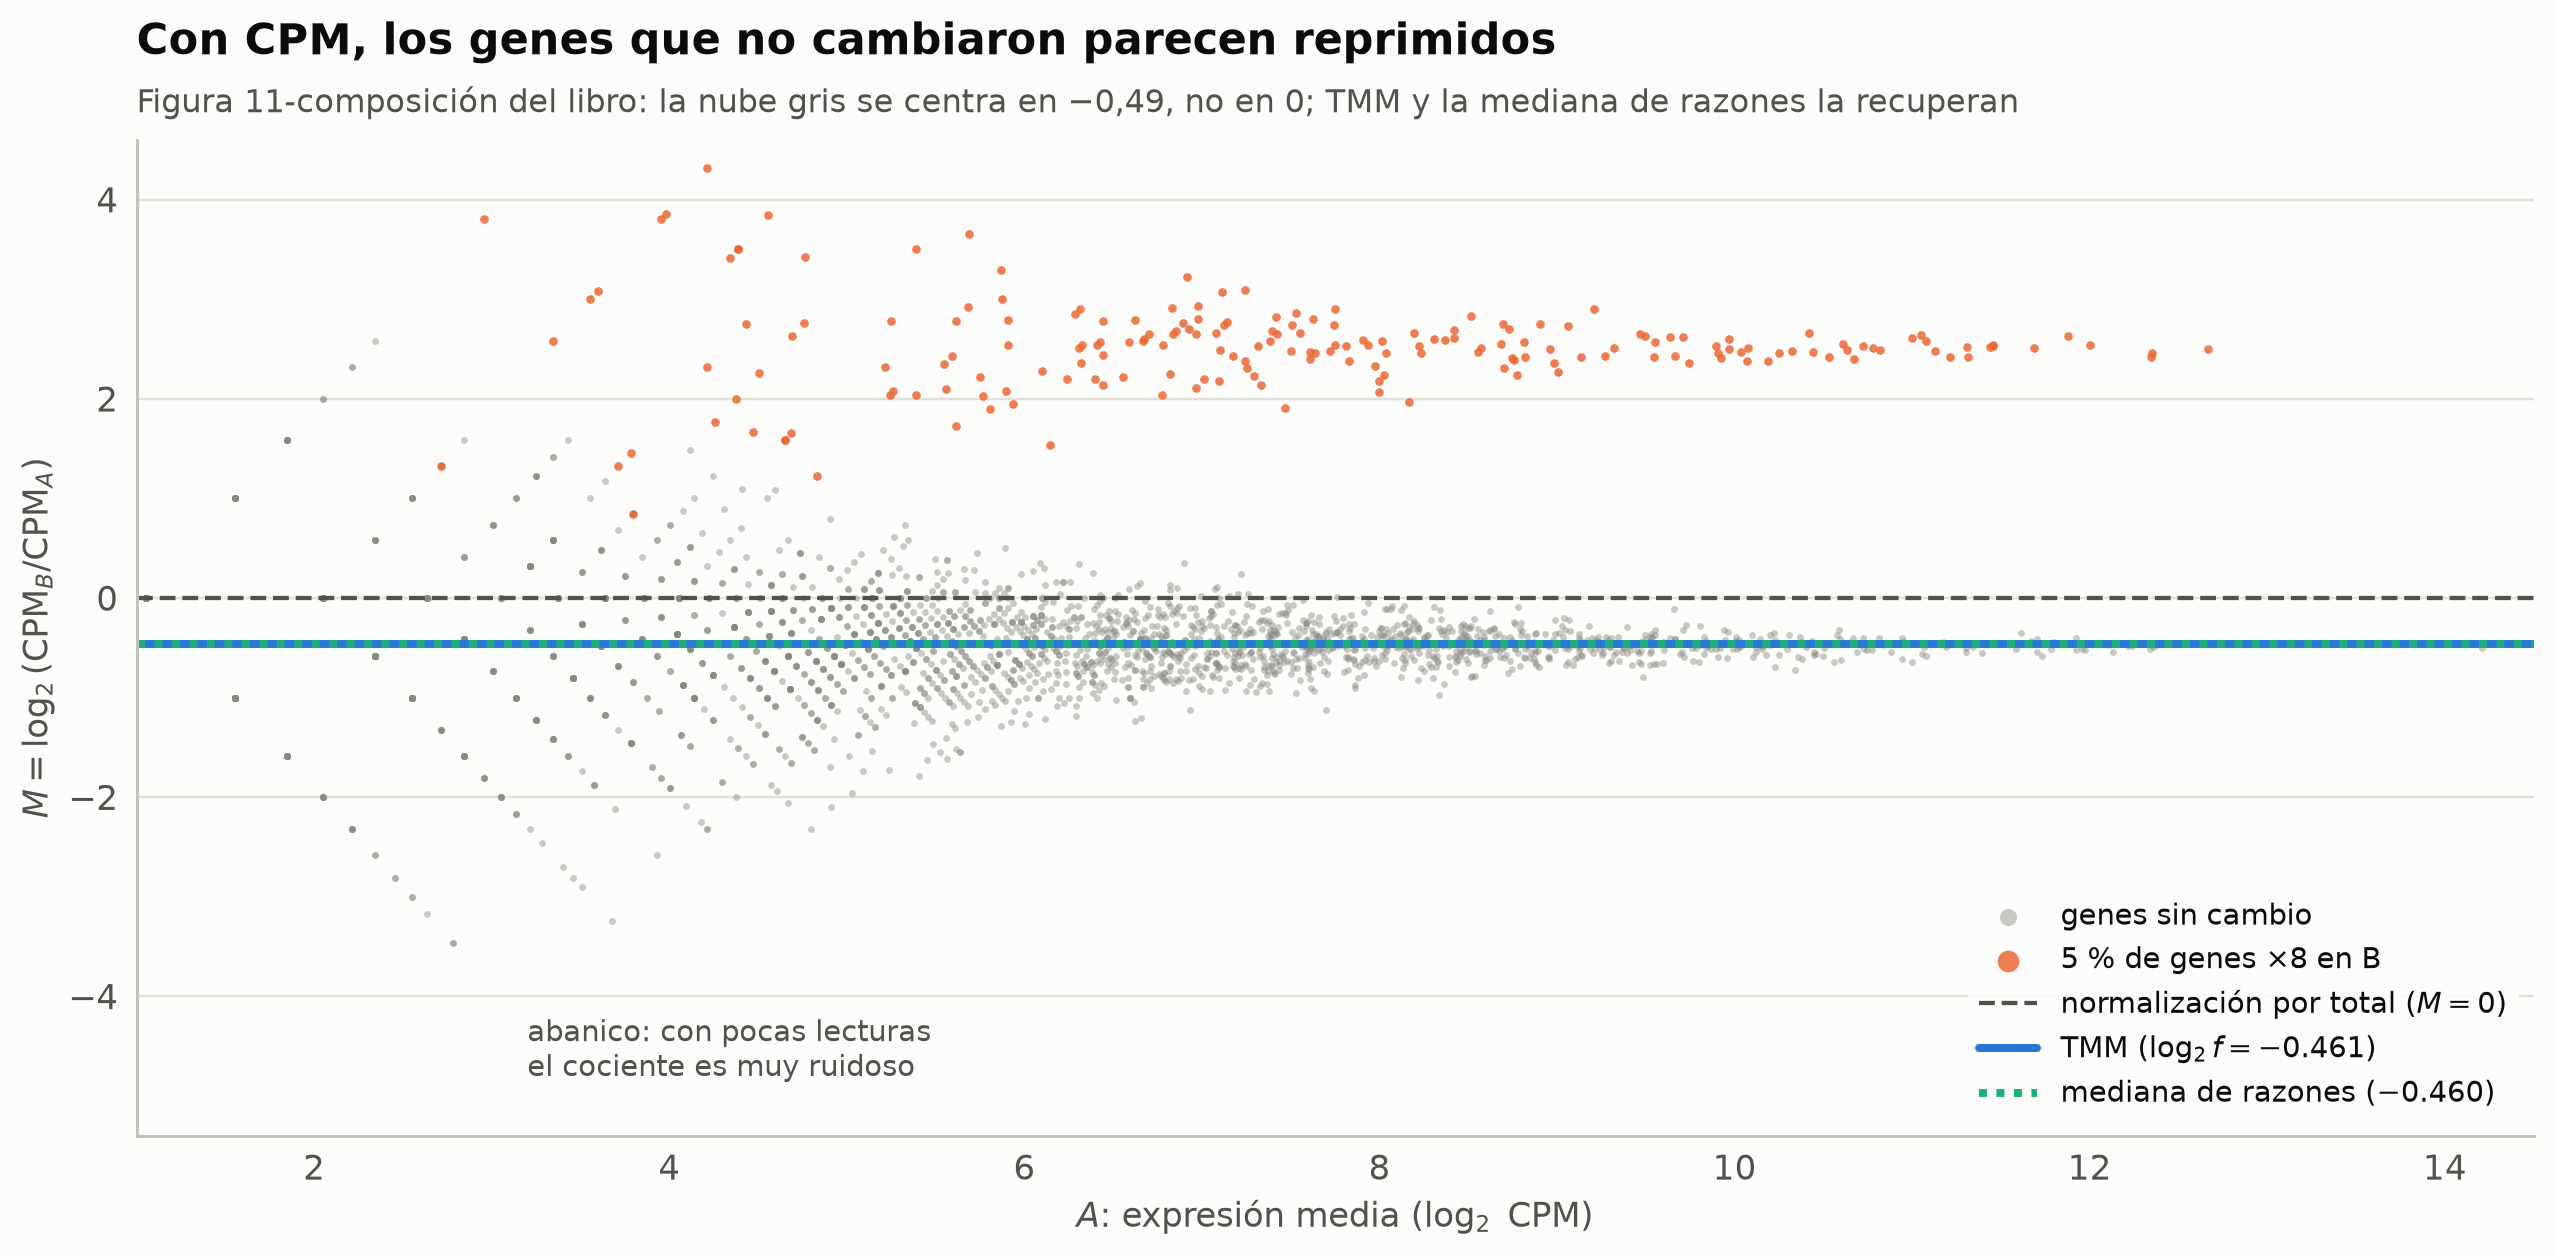

In [8]:
sub = BOOK["sub_comp"]                                  # la misma submuestra de 2 500 genes que dibuja el libro
fig, ax = plt.subplots(figsize=(11.5, 5.6))
ns_sub = sub[~is_up[sub]]
ax.scatter(A[ns_sub], M[ns_sub], s=5, color=ec.MUTED, alpha=0.45, lw=0, label="genes sin cambio")
ax.scatter(A[is_up], M[is_up], s=8, color=ec.ORANGE, alpha=0.85, lw=0, label="5 % de genes ×8 en B")
ax.axhline(0, color=ec.INK_2, ls="--", lw=1.4, label="normalización por total ($M=0$)")
ax.axhline(m_tmm, color=ec.BLUE, lw=2.6, label=f"TMM ($\\log_2 f={m_tmm:.3f}$)")
ax.axhline(m_mor, color=ec.AQUA, lw=2.6, ls=(0, (1, 1.2)), label=f"mediana de razones (${m_mor:.3f}$)")
ax.set_xlim(1, 14.5); ax.set_ylim(-5.4, 4.6)
ax.set_xlabel("$A$: expresión media ($\\log_2$ CPM)")
ax.set_ylabel("$M=\\log_2(\\mathrm{CPM}_B/\\mathrm{CPM}_A)$")
ax.legend(loc="lower right", fontsize=9.5, frameon=True, framealpha=0.9, markerscale=2.5)
ax.annotate("abanico: con pocas lecturas\nel cociente es muy ruidoso", xy=(2.3, -3.2), xytext=(3.2, -4.8),
            fontsize=9.5, color=ec.INK_2, arrowprops=dict(arrowstyle="->", color=ec.INK_2))
ec.title(ax, "Con CPM, los genes que no cambiaron parecen reprimidos",
         "Figura 11-composición del libro: la nube gris se centra en −0,49, no en 0; TMM y la mediana de razones la recuperan")
plt.show()

> 🔎 **Qué observamos.** Los genes naranja suben unas tres unidades de $\log_2$ ($\times 8$), como debía ser. Pero la
> nube gris, que **no cambió**, está centrada claramente por debajo de cero: con la normalización por total, **todos**
> esos genes aparecen como ligeramente reprimidos en B. Con miles de genes y un test estadístico sensible, esa
> diferencia sistemática de $-0{,}49$ en $\log_2$ (un 29 % menos) se convierte en miles de falsos positivos. TMM
> (azul) y la mediana de razones (aqua) caen justo en el centro de la nube gris, prácticamente sobre el valor teórico
> de $-0{,}486$; las dos líneas casi coinciden. A la izquierda ($A\lesssim4$) la nube se abre en abanico: con 1–10
> lecturas, un cociente de conteos es muy ruidoso. Ese abanico es la huella del ruido de Poisson que modelaremos en
> la sección 5.

### 2.1 Animación: el adolescente cada vez más hambriento

¿Qué pasa si el 5 % de los genes no se multiplica por 8 sino por 1, 2, 4… 32? En la animación mantenemos fijo el
«azar» de cada gen (usamos siempre el mismo cuantil de su distribución de Poisson) y sólo cambiamos el factor.

![A medida que el 5 % de los genes multiplica su expresión en B (de ×1 a ×32), la nube de genes sin cambio se hunde con CPM; TMM y la mediana de razones siguen su centro, que coincide con la dilución teórica](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-11-rnaseq/11.2_composicion.gif)

*A medida que el 5 % de los genes multiplica su expresión en B (de ×1 a ×32), la nube de genes sin cambio se hunde con CPM; TMM y la mediana de razones siguen su centro, que coincide con la dilución teórica*

In [9]:
U_b = np.random.default_rng(112).random(len(lam))      # un cuantil fijo por gen: el "azar" no cambia entre cuadros
folds = 2 ** np.linspace(0, 5, 41)                      # de ×1 a ×32

def world_B(fold):
    lamB = lam.copy(); lamB[up] *= fold
    return stats.poisson.ppf(U_b, lamB * NA / lamB.sum()).astype(int)

traj = []
for fo in folds:
    b = world_B(fo)
    lamB = lam.copy(); lamB[up] *= fo
    traj.append((np.log2(tmm_factor(b, xa)),
                 np.log2(size_factors(np.column_stack([xa, b]))[1] / size_factors(np.column_stack([xa, b]))[0] / (b.sum() / NA)),
                 np.log2(lam.sum() / lamB.sum())))
traj = np.array(traj)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.3), gridspec_kw=dict(width_ratios=[1.35, 1]))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.87))
sc_ns = ax1.scatter([], [], s=5, color=ec.MUTED, alpha=0.45, lw=0)
sc_up = ax1.scatter([], [], s=8, color=ec.ORANGE, alpha=0.85, lw=0)
ax1.axhline(0, color=ec.INK_2, ls="--", lw=1.2)
l_tmm = ax1.axhline(0, color=ec.BLUE, lw=2.4)
l_mor = ax1.axhline(0, color=ec.AQUA, lw=2.4, ls=(0, (1, 1.2)))
ax1.set_xlim(1, 15); ax1.set_ylim(-6, 6)
ax1.set_xlabel("$A$ ($\\log_2$ CPM)"); ax1.set_ylabel("$M$ (B frente a A)")
ftxt = ax1.text(0.03, 0.95, "", transform=ax1.transAxes, fontsize=13, fontweight="bold", color=ec.ORANGE, va="top")
ax2.plot(np.log2(folds), traj[:, 2], color=ec.INK, lw=1.2, ls=":", label="dilución teórica $\\log_2(S_A/S_B)$")
p_tmm, = ax2.plot([], [], color=ec.BLUE, lw=2.4, label="TMM")
p_mor, = ax2.plot([], [], color=ec.AQUA, lw=2.4, ls=(0, (1, 1.2)), label="mediana de razones")
ax2.axhline(0, color=ec.INK_2, ls="--", lw=1.2, label="normalización por total")
ax2.set_xlim(0, 5); ax2.set_ylim(-2.4, 0.3)
ax2.set_xticks(range(6), [f"×{2 ** k}" for k in range(6)])
ax2.set_xlabel("factor de los genes «up» en B"); ax2.set_ylabel("centro de los genes sin cambio ($\\log_2$)")
ax2.legend(loc="lower left", fontsize=9, frameon=False)
fig.text(0.01, 0.985, "Cuanto más come el invitado, más parecen adelgazar los demás", fontsize=15,
         fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.935, "Simulación del libro (4 000 genes, 5 % «up»). Izquierda: gráfico MA; derecha: factor de "
         "normalización estimado frente a la dilución real", fontsize=10.5, color=ec.INK_2, va="top")

def update(k):
    b = world_B(folds[k])
    ok = (xa > 0) & (b > 0)
    Mk = np.log2((b[ok] / b.sum()) / (xa[ok] / NA))
    Ak = 0.5 * np.log2((b[ok] / b.sum()) * (xa[ok] / NA)) + np.log2(1e6)
    upk = np.isin(np.where(ok)[0], up)
    nsk = np.where(~upk)[0][::2]
    sc_ns.set_offsets(np.column_stack([Ak[nsk], Mk[nsk]]))
    sc_up.set_offsets(np.column_stack([Ak[upk], Mk[upk]]))
    l_tmm.set_ydata([traj[k, 0]] * 2); l_mor.set_ydata([traj[k, 1]] * 2)
    p_tmm.set_data(np.log2(folds[: k + 1]), traj[: k + 1, 0])
    p_mor.set_data(np.log2(folds[: k + 1]), traj[: k + 1, 1])
    ftxt.set_text(f"genes «up» ×{folds[k]:.1f}")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(folds), interval=140, name="11.2_composicion")
print(f"a ×32: TMM {traj[-1, 0]:.2f}, mediana de razones {traj[-1, 1]:.2f}, teoría {traj[-1, 2]:.2f}")
anim_html

a ×32: TMM -1.44, mediana de razones -1.46, teoría -1.47


▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Con ×1 nada se mueve. A medida que crece el factor, los genes naranja suben y **arrastran
> hacia abajo** a la nube gris: la dilución llega a más de una unidad de $\log_2$ (la mitad del CPM) con ×32. Las dos
> estimaciones robustas siguen a la curva teórica punteada casi sin error, porque el 95 % de los genes sí cumple el
> supuesto «no cambio». La normalización por total, en cambio, se queda clavada en cero.

## 3. TMM: media recortada de cocientes

La idea de Robinson y Oshlack (2010) parte de un supuesto biológico: **la mayoría de los genes no cambia**. Si es así,
sus cocientes de expresión entre muestras deben estar centrados en cero después de normalizar, y el desplazamiento de
su centro **mide** el sesgo de composición. Es como estimar la inflación: no se mira el precio de un solo producto,
sino el centro de muchos precios, descartando los que se dispararon por razones propias.

Con una muestra de referencia $r$, se definen para cada gen el cociente logarítmico y la expresión media:

$$
M_i=\log_2\frac{K_{ij}/N_j}{K_{ir}/N_r},\qquad
A_i=\tfrac12\log_2\!\left(\frac{K_{ij}}{N_j}\cdot\frac{K_{ir}}{N_r}\right).
\qquad\text{(ecuación 11-ma)}
$$

Se descartan los genes con $M$ extremo (por defecto, el **30 % de cada cola**) y con $A$ extremo (el **5 %**), y se
promedian los $M$ restantes con pesos iguales al inverso de su varianza aproximada:

$$
\boxed{\;\log_2 f_j=\frac{\sum_{i\in\mathcal R} w_i M_i}{\sum_{i\in\mathcal R} w_i},\qquad
w_i^{-1}=\frac{N_j-K_{ij}}{N_jK_{ij}}+\frac{N_r-K_{ir}}{N_rK_{ir}}\;}
\qquad\text{(ecuación 11-tmm)}
$$

| Símbolo | Significado |
|---|---|
| $M_i,\ A_i$ | cociente logarítmico y expresión media del gen $i$ entre la muestra $j$ y la referencia $r$ |
| $\mathcal R$ | genes que sobreviven al doble recorte |
| $w_i$ | peso: inverso de la varianza aproximada (método delta) de $M_i$ |
| $f_j$ | factor TMM; el **tamaño efectivo** de la biblioteca es $N_jf_j$ |

**¿De dónde sale $w_i^{-1}$?** Si $K\sim\mathrm{Bin}(N,p)$, el método delta da
$\operatorname{Var}[\log K]\approx\operatorname{Var}[K]/\mathbb E[K]^2=Np(1-p)/(Np)^2=(N-K)/(NK)$ al sustituir
$p\approx K/N$. El cociente $M_i$ es una diferencia de dos logaritmos independientes, así que sus varianzas se suman.
Un gen con 10 lecturas tiene $w^{-1}\approx0{,}1+0{,}1=0{,}2$; uno con 10 000, $\approx0{,}0002$: **mil veces más
voz**.

El recorte cumple el papel de la mediana: vuelve el estimador inmune a los genes que realmente cambian, siempre que
sean minoría o que se repartan de forma aproximadamente simétrica entre subidas y bajadas.

Veamos qué genes sobreviven al recorte en la simulación.

genes con conteo > 0 en ambas: 3875;  sobreviven al recorte: 1389 (36%)
genes 'up' dentro de R: 0 de 198


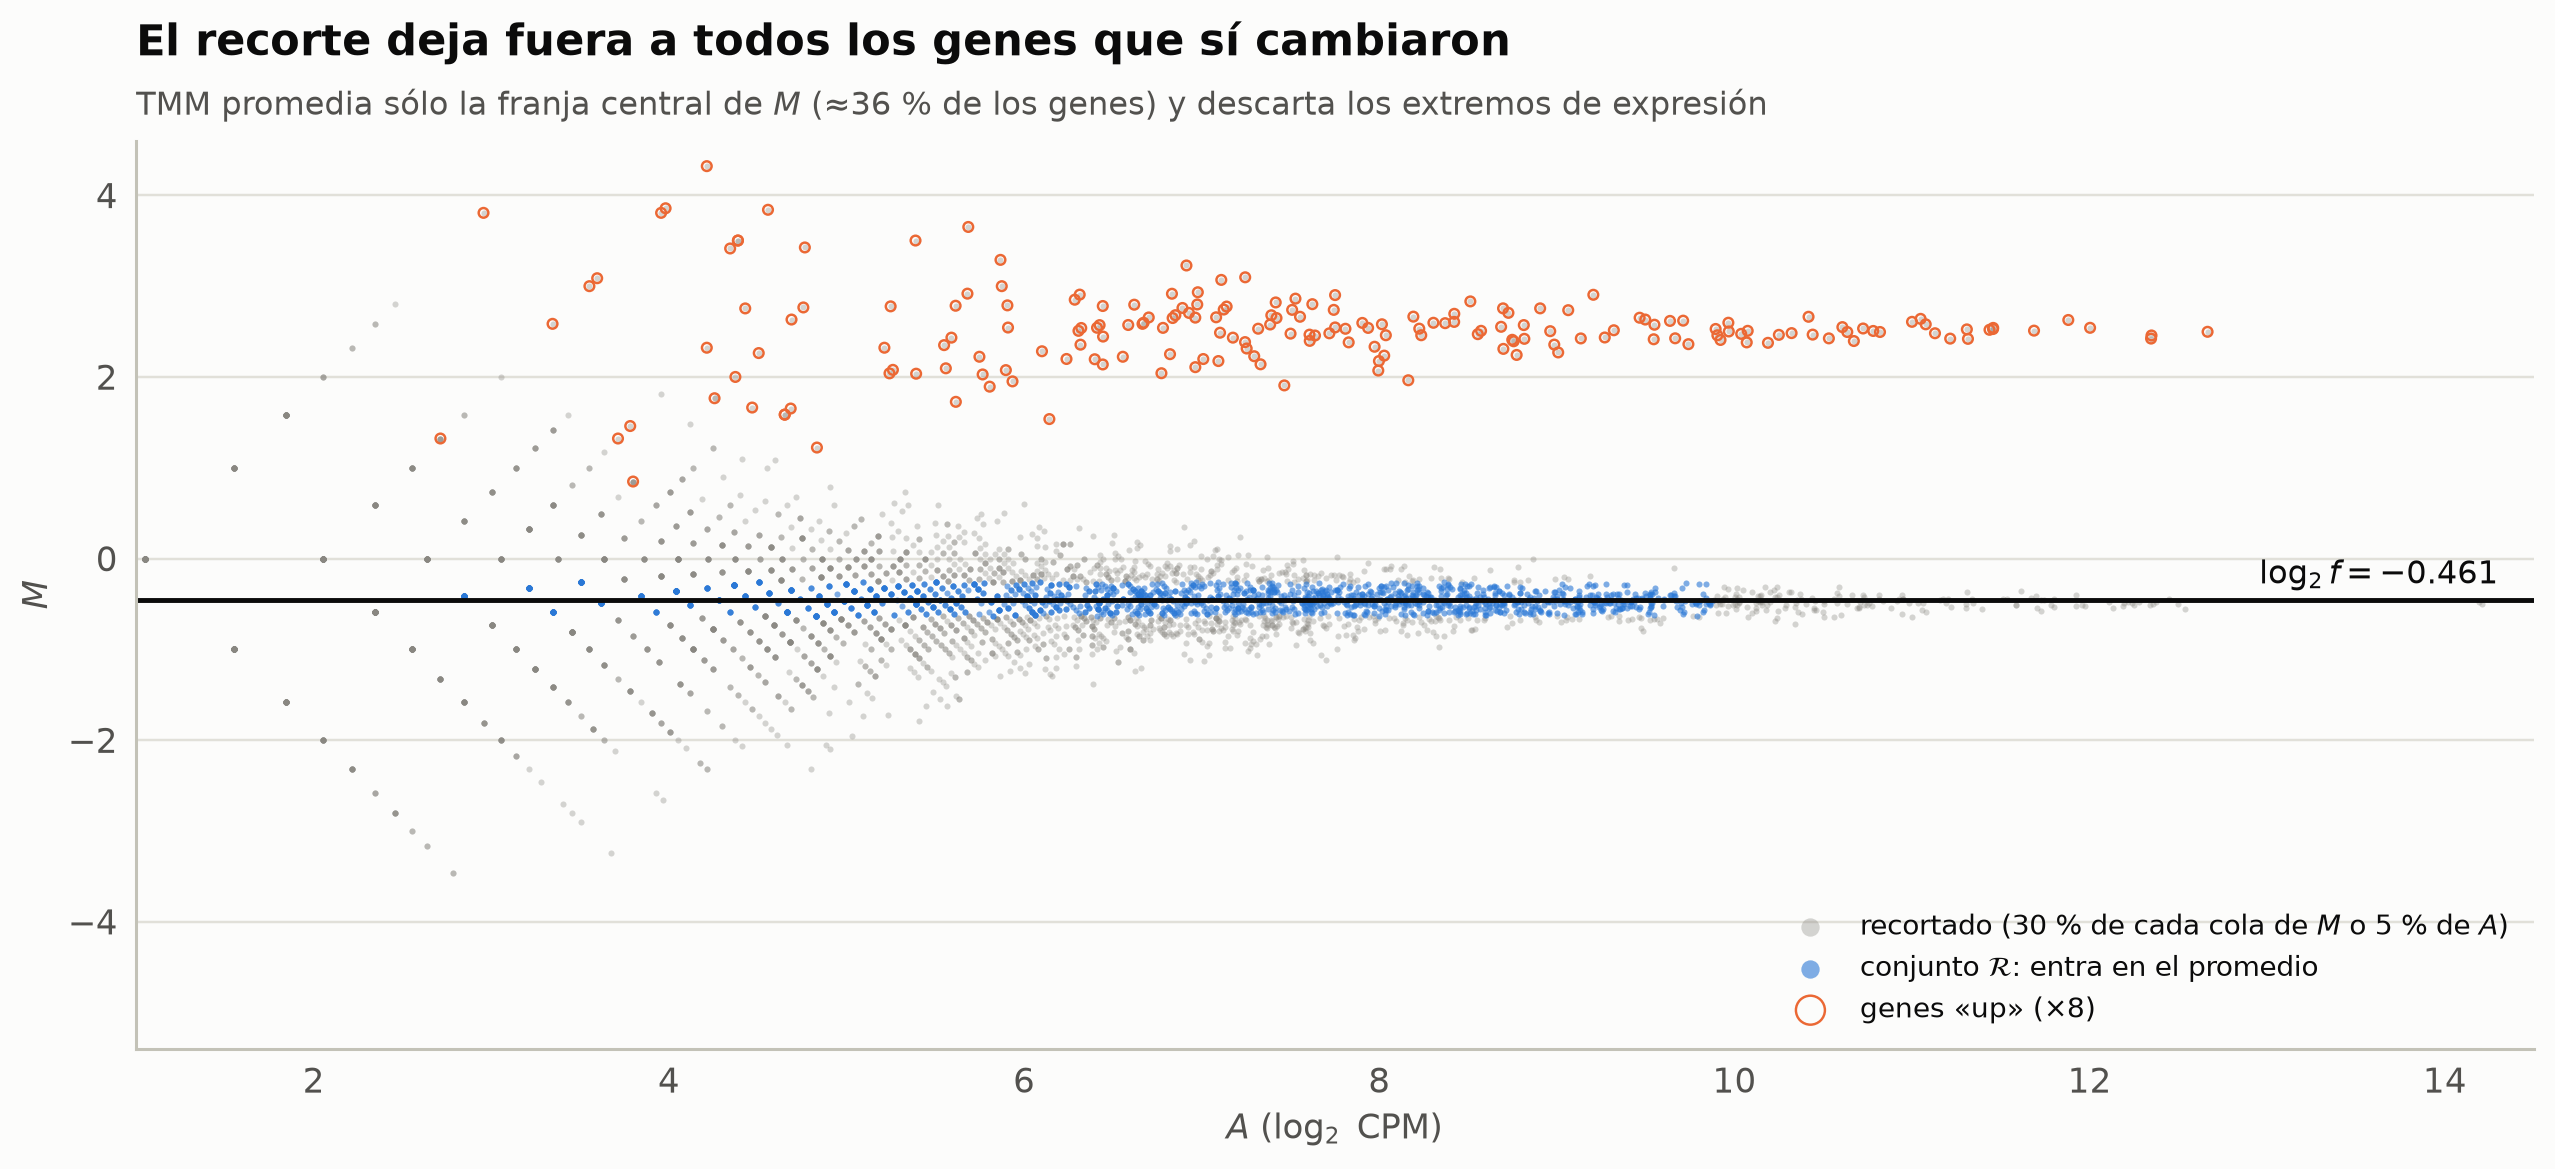

In [10]:
# Qué genes quedan en el conjunto R del doble recorte (misma lógica que tmm_factor, pero devolviendo la máscara)
n = len(M)
rm, ra = stats.rankdata(M), stats.rankdata(A)
sel_M = (rm >= np.floor(n * 0.3) + 1) & (rm <= n + 1 - np.floor(n * 0.3))
sel_A = (ra >= np.floor(n * 0.05) + 1) & (ra <= n + 1 - np.floor(n * 0.05))
R = sel_M & sel_A
print(f"genes con conteo > 0 en ambas: {n};  sobreviven al recorte: {R.sum()} ({R.mean():.0%})")
print(f"genes 'up' dentro de R: {(R & is_up).sum()} de {is_up.sum()}")

fig, ax = plt.subplots(figsize=(11.5, 5.2))
ax.scatter(A[~R], M[~R], s=4, color=ec.MUTED, alpha=0.35, lw=0, label="recortado (30 % de cada cola de $M$ o 5 % de $A$)")
ax.scatter(A[R], M[R], s=4, color=ec.BLUE, alpha=0.6, lw=0, label="conjunto $\\mathcal{R}$: entra en el promedio")
ax.scatter(A[is_up], M[is_up], s=10, facecolor="none", edgecolor=ec.ORANGE, lw=0.8, label="genes «up» (×8)")
ax.axhline(m_tmm, color=ec.INK, lw=1.6)
ax.text(14.3, m_tmm + 0.18, f"$\\log_2 f={m_tmm:.3f}$", ha="right", fontsize=10.5)
ax.set_xlim(1, 14.5); ax.set_ylim(-5.4, 4.6)
ax.set_xlabel("$A$ ($\\log_2$ CPM)"); ax.set_ylabel("$M$")
ax.legend(loc="lower right", fontsize=9, markerscale=3, framealpha=0.9)
ec.title(ax, "El recorte deja fuera a todos los genes que sí cambiaron",
         "TMM promedia sólo la franja central de $M$ (≈36 % de los genes) y descarta los extremos de expresión")
plt.show()

> 🔎 **Qué observamos.** La franja azul (1 389 genes, el 40 % central de los cocientes $M$ menos los extremos de
> $A$) contiene genes sin cambio y **ninguno** de los 198 genes «up» con lecturas en ambas muestras, que quedan todos en la cola superior recortada. Por eso el promedio de la franja
> estima limpiamente el desplazamiento de composición. Los pesos hacen que los genes de la derecha (muchas lecturas,
> cociente preciso) cuenten más que los del abanico de la izquierda.

> ✅ **Compruebe su comprensión.** Si en lugar del 5 % subiera el 45 % de los genes, ¿seguiría funcionando el
> recorte del 30 % por cola? *(No: los genes «up» ocuparían también la franja central y arrastrarían el promedio.
> El supuesto «la mayoría no cambia» es imprescindible.)*

### 3.1 TMM en las muestras reales

edgeR elige como referencia la muestra cuyo cuartil superior de CPM está más cerca de la media de los cuartiles
superiores, y calcula $f_j$ de cada muestra frente a ella. Después reescala los factores para que su media geométrica
sea 1. Hagamos lo mismo con las 16 muestras de *airway*.

In [11]:
N_j = K_all.sum(axis=0)
uq = np.quantile(K_all / N_j, 0.75, axis=0)
ref = int(np.argmin(np.abs(uq - uq.mean())))
f_real = np.array([tmm_factor(K_all[:, j], K_all[:, ref]) for j in range(16)])
f_real /= np.exp(np.log(f_real).mean())                  # media geométrica 1, como edgeR
samples["TMM_f"] = f_real
samples["N_efectivo"] = N_j * f_real
print(f"muestra de referencia: {RUNS[ref]} ({samples.cell[ref]}, {samples.tratamiento[ref]})")
print(f"factores TMM: de {f_real.min():.3f} a {f_real.max():.3f}")
samples[["run", "cell", "tratamiento", "N_asignadas", "TMM_f"]].round(3)

muestra de referencia: SRR1039512 (N052611, sin tratar)
factores TMM: de 0.911 a 1.068


,run,cell,tratamiento,N_asignadas,TMM_f
0,SRR1039508,N61311,sin tratar,20715203,1.064
1,SRR1039509,N61311,dexametasona,19020171,1.033
2,SRR1039510,N61311,albuterol,20810459,1.068
3,SRR1039511,N61311,albuterol + dexametasona,20050651,1.036
4,SRR1039512,N052611,sin tratar,25861510,0.982
5,SRR1039513,N052611,dexametasona,40820460,0.930
6,SRR1039514,N052611,albuterol,36164336,0.911
7,SRR1039515,N052611,albuterol + dexametasona,26837228,0.985
8,SRR1039516,N080611,sin tratar,27682312,1.034
9,SRR1039517,N080611,dexametasona,31298313,0.975


> 🔎 **Qué observamos.** Los factores TMM reales se mueven entre ~0,91 y ~1,07: la composición cambia hasta un 16 %
> entre muestras. Es menos dramático que en la simulación porque la dexametasona no dispara genes que se coman la
> pizza, pero no es despreciable: un 10 % de sesgo sistemático bastaría para que cientos de genes sin cambio
> resultaran «significativos» en un experimento bien replicado.

## 4. La mediana de razones

Anders y Huber (2010) propusieron, para DESeq, un estimador todavía más directo. Se construye una **pseudomuestra de
referencia** con la **media geométrica** de cada gen a través de todas las muestras, y el **factor de tamaño** de
cada muestra es la mediana de sus cocientes con esa referencia:

$$
\boxed{\;\hat s_j=\operatorname*{mediana}_{i:\,K_{iv}>0\ \forall v}\;
\frac{K_{ij}}{\left(\prod_{v=1}^{m}K_{iv}\right)^{1/m}}\;}
\qquad\text{(ecuación 11-mor)}
$$

| Símbolo | Significado |
|---|---|
| $\hat s_j$ | factor de tamaño de la muestra $j$; los conteos normalizados son $K_{ij}/\hat s_j$ |
| $m$ | número de muestras |
| $\left(\prod_v K_{iv}\right)^{1/m}$ | media geométrica del gen $i$: la pseudomuestra de referencia |

La mediana se calcula **sólo sobre genes sin ceros**, porque un cero anula la media geométrica. Como la media
geométrica es simétrica respecto a todas las muestras, **no hace falta elegir una referencia**, y el producto de los
factores es aproximadamente 1.

### Ejemplo a mano: factores de tamaño (ejemplo 11-mor del libro)

Cinco genes en tres muestras:

| Gen | $K_{i1}$ | $K_{i2}$ | $K_{i3}$ | media geom. |
|---|---:|---:|---:|---:|
| g1 | 500 | 1100 | 700 | 727,5 |
| g2 | 80 | 190 | 105 | 116,9 |
| g3 | 1200 | 2600 | 1550 | 1691,1 |
| g4 | 30 | 64 | 42 | 43,2 |
| g5 | 10 | 0 | 9 | — |

**Paso 1: fuera los genes con ceros.** g5 tiene un cero en la muestra 2 y queda fuera.

**Paso 2: medias geométricas.** Para g1, $(500\cdot1100\cdot700)^{1/3}=(3{,}85\times10^{8})^{1/3}=727{,}5$.

**Paso 3: cocientes.** Muestra 1: $500/727{,}5=0{,}687$; $80/116{,}9=0{,}685$; $1200/1691{,}1=0{,}710$;
$30/43{,}2=0{,}694$.

**Paso 4: mediana.** Ordenados, $0{,}685;\ 0{,}687;\ 0{,}694;\ 0{,}710$; con cuatro valores la mediana es el promedio
de los dos centrales: $\hat s_1=(0{,}687+0{,}694)/2=0{,}691$. Del mismo modo, $\hat s_2=1{,}525$ y $\hat s_3=0{,}939$.

La muestra 2 se secuenció, en efecto, a algo más del doble de profundidad que la 1. Observe que los cocientes de cada
columna son muy parecidos entre sí: esa **coherencia** es la que justifica usar su mediana como factor común.

> 🤔 **Antes de ejecutar, prediga…** ¿Cuánto vale el producto $\hat s_1\hat s_2\hat s_3$? ¿Exactamente 1?

In [12]:
K_toy = np.array([[500, 1100, 700], [80, 190, 105], [1200, 2600, 1550], [30, 64, 42], [10, 0, 9]], float)
ok = (K_toy > 0).all(axis=1)
geo = np.exp(np.log(K_toy[ok]).mean(axis=1))
ratios = K_toy[ok] / geo[:, None]
print("medias geométricas:", geo.round(2), "   libro: [727.48 116.86 1691.07 43.2]")
print("cocientes (genes × muestras):\n", ratios.round(3))
s_toy = size_factors(K_toy)
print("factores de tamaño:", s_toy.round(3), "   libro: [0.691 1.525 0.939]")
print(f"producto de los factores = {s_toy.prod():.3f}")
print("conteos normalizados K/s:\n", (K_toy / s_toy).round(0))

medias geométricas: [ 727.48  116.86 1691.07   43.2 ]    libro: [727.48 116.86 1691.07 43.2]
cocientes (genes × muestras):
 [[0.687 1.512 0.962]
 [0.685 1.626 0.898]
 [0.71  1.537 0.917]
 [0.694 1.481 0.972]]
factores de tamaño: [0.691 1.525 0.939]    libro: [0.691 1.525 0.939]
producto de los factores = 0.989
conteos normalizados K/s:
 [[ 724.  721.  745.]
 [ 116.  125.  112.]
 [1737. 1705. 1650.]
 [  43.   42.   45.]
 [  14.    0.   10.]]


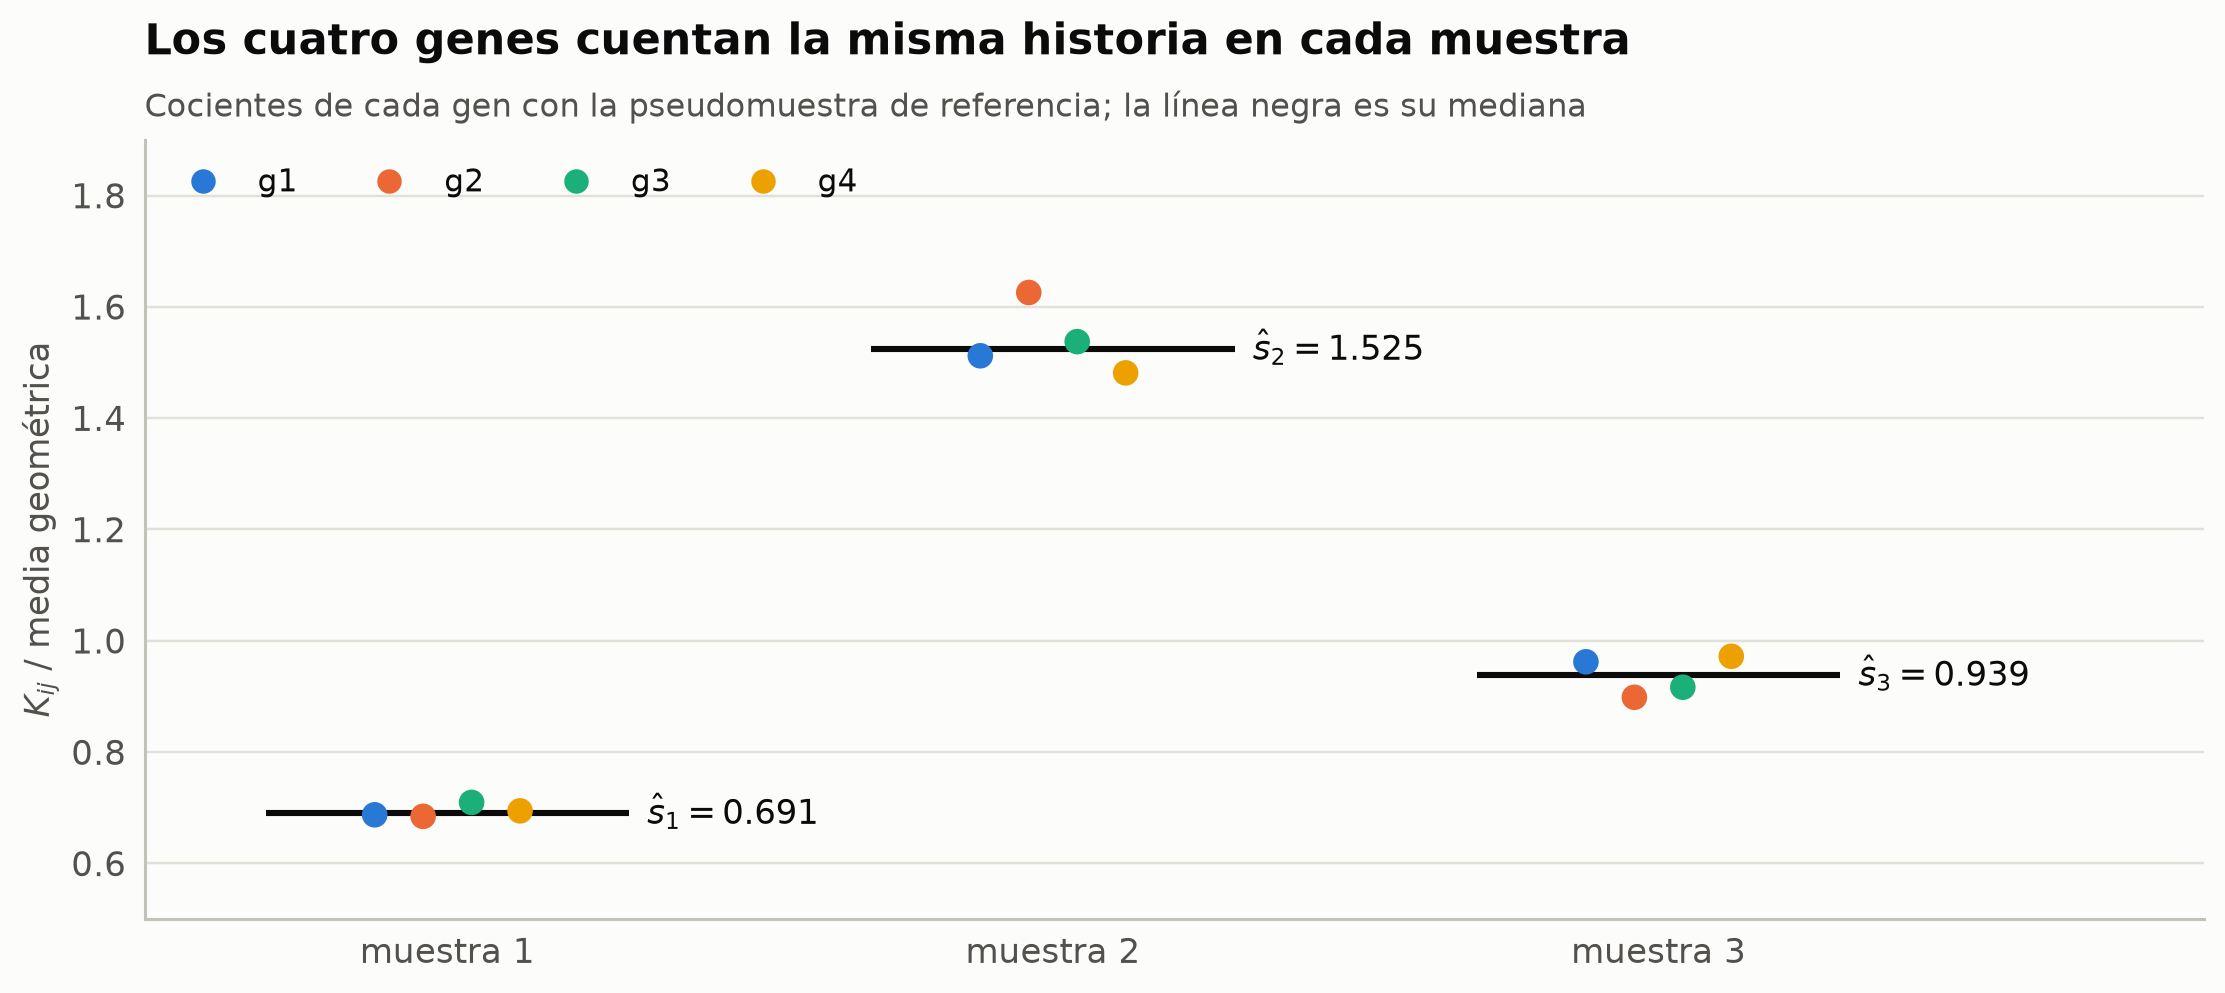

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.4))
for j in range(3):
    xs = np.full(4, j) + np.linspace(-0.12, 0.12, 4)
    ax.scatter(xs, ratios[:, j], s=70, color=ec.CATEGORICAL[:4], zorder=3, edgecolor="white")
    ax.hlines(s_toy[j], j - 0.3, j + 0.3, color=ec.INK, lw=2)
    ax.text(j + 0.33, s_toy[j], f"$\\hat s_{j + 1}={s_toy[j]:.3f}$", va="center", fontsize=11)
for g in range(4):
    ax.plot([], [], "o", color=ec.CATEGORICAL[g], label=f"g{g + 1}")
ax.set_xticks(range(3), ["muestra 1", "muestra 2", "muestra 3"])
ax.set_xlim(-0.5, 2.9)
ax.set_ylabel("$K_{ij}$ / media geométrica")
ax.legend(ncol=4, loc="upper left", frameon=False)
ax.set_ylim(0.5, 1.9)
ec.title(ax, "Los cuatro genes cuentan la misma historia en cada muestra",
         "Cocientes de cada gen con la pseudomuestra de referencia; la línea negra es su mediana")
plt.show()

> 🔎 **Qué observamos.** En cada columna los cuatro puntos están muy juntos (por ejemplo, entre 1,48 y 1,63 en la
> muestra 2): cada gen, por separado, «vota» por un factor parecido. La mediana resume esos votos y es inmune a
> que uno o dos genes voten muy distinto porque cambiaron de verdad. El producto de los factores es 0,989, muy
> cercano a 1, como se anunció. Los conteos normalizados $K_{ij}/\hat s_j$ de g1 (724, 721, 745) ya son
> comparables entre muestras.

### 4.1 La mediana de razones en las 16 muestras reales

Ahora con datos de verdad. Para cada muestra dibujamos el histograma de $\log_2$ de los cocientes de sus genes con la
pseudomuestra; la mediana de ese histograma es $\log_2\hat s_j$. Si el método funciona, cada histograma debe ser un
pico estrecho y simétrico.

genes sin ceros en las 16 muestras: 22 190
correlación entre log(N_j·f_j) de TMM y log(s_j): 0.9992


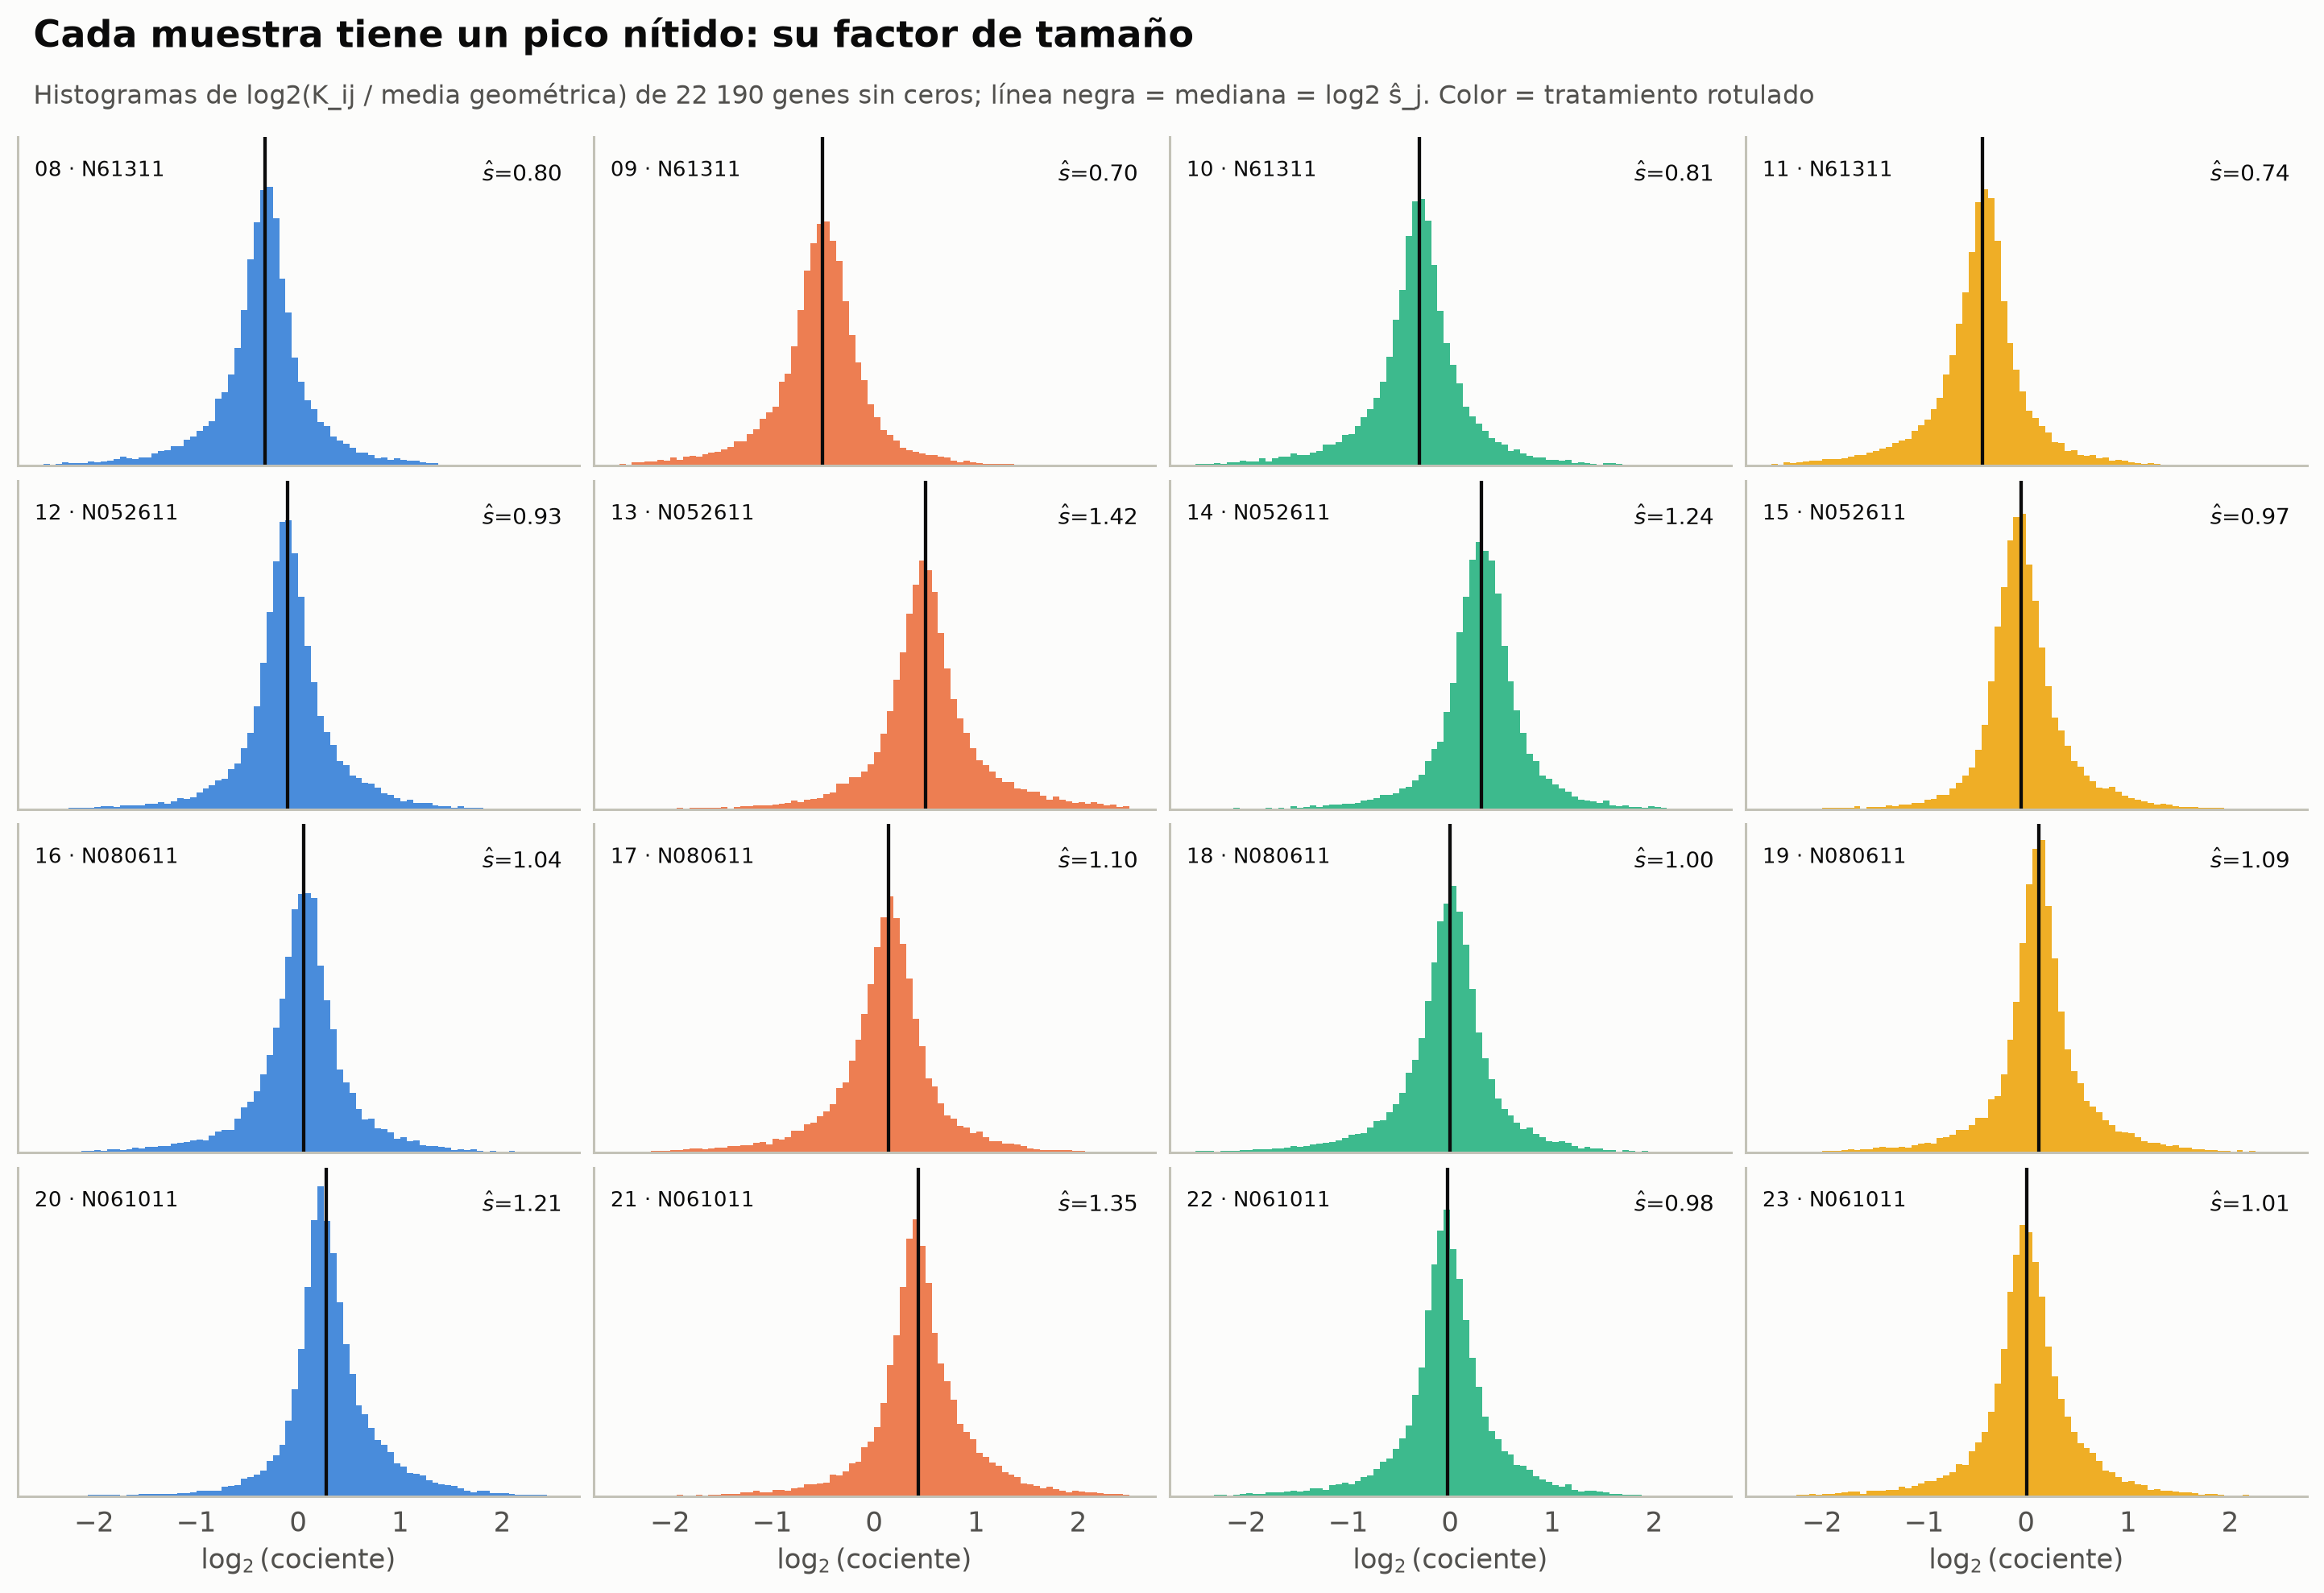

In [14]:
s16 = size_factors(K_all)
okz = (K_all > 0).all(axis=1)
lr = np.log2(K_all[okz]) - np.log2(K_all[okz]).mean(axis=1, keepdims=True)
samples["s_MoR"] = s16
print(f"genes sin ceros en las 16 muestras: {okz.sum():,}".replace(",", " "))
print("correlación entre log(N_j·f_j) de TMM y log(s_j):",
      f"{np.corrcoef(np.log(samples.N_efectivo), np.log(s16))[0, 1]:.4f}")

fig, axes = plt.subplots(4, 4, figsize=(13, 8.2), sharex=True, sharey=True)
bins = np.linspace(-2.5, 2.5, 81)
for j, ax in enumerate(axes.flat):
    ax.hist(lr[:, j], bins=bins, color=cols[j], alpha=0.85)
    ax.axvline(np.log2(s16[j]), color=ec.INK, lw=1.4)
    ax.text(0.03, 0.93, f"{RUNS[j][-2:]} · {samples.cell[j]}", transform=ax.transAxes, fontsize=8.5, va="top")
    ax.text(0.97, 0.93, f"$\\hat s$={s16[j]:.2f}", transform=ax.transAxes, fontsize=9, va="top", ha="right")
    ax.set_yticks([])
for ax in axes[-1]:
    ax.set_xlabel("$\\log_2$(cociente)")
ec.fig_title(fig, "Cada muestra tiene un pico nítido: su factor de tamaño",
             "Histogramas de log2(K_ij / media geométrica) de 22 190 genes sin ceros; línea negra = mediana = log2 ŝ_j. "
             "Color = tratamiento rotulado")
plt.show()

> 🔎 **Qué observamos.** Los 16 histogramas son picos estrechos y casi simétricos: la inmensa mayoría de los genes
> «vota» por el mismo factor, que va de ~0,70 (SRR1039509) a ~1,42 (SRR1039513). Las colas son genes que cambian de
> verdad o que tienen pocas lecturas. La correlación entre el tamaño efectivo de TMM y el factor de la mediana de
> razones es 0,999: en datos reales, igual que en la simulación, **los dos métodos coinciden** casi exactamente.

### 🎛️ Interactivo: profundidad, TMM y mediana de razones

Pase el cursor sobre cada muestra. El eje $x$ es la profundidad relativa $N_j/\bar N_{\text{geo}}$ (lo que haría CPM);
el eje $y$, el factor de tamaño $\hat s_j$. Si sólo importara la profundidad, los puntos caerían sobre la diagonal.

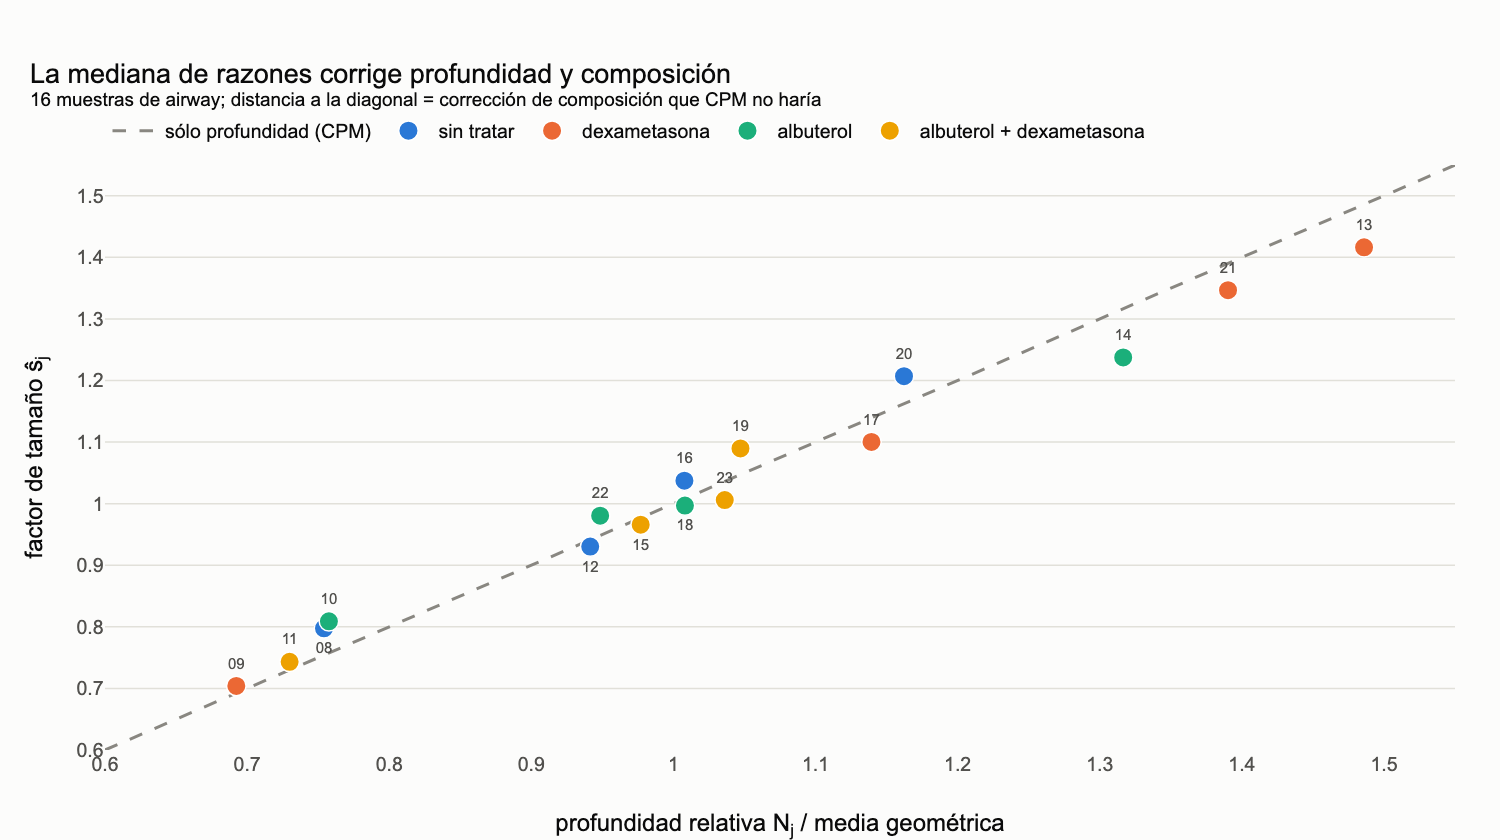

In [15]:
geo_N = np.exp(np.log(N_j).mean())
df_sf = samples.assign(N_rel=N_j / geo_N, eff_rel=samples.N_efectivo / np.exp(np.log(samples.N_efectivo).mean()),
                       comp=s16 / (N_j / geo_N))
fig = go.Figure()
lim = [0.6, 1.55]
fig.add_trace(go.Scatter(x=lim, y=lim, mode="lines", line=dict(color=ec.MUTED, dash="dash"),
                         name="sólo profundidad (CPM)", hoverinfo="skip"))
for k, t in enumerate(["Untreated", "Dexamethasone", "Albuterol", "Albuterol_Dexamethasone"]):
    d = df_sf[df_sf.treatment == t]
    fig.add_trace(go.Scatter(
        x=d.N_rel, y=d.s_MoR, mode="markers+text", text=[r[-2:] for r in d.run],
        textposition=["bottom center" if r[-2:] in ("08", "12", "18", "15") else "top center" for r in d.run],
        textfont=dict(size=10, color=ec.INK_2),
        marker=dict(size=13, color=ec.CATEGORICAL[k], line=dict(color="white", width=1)), name=TREAT_ES[t],
        customdata=np.column_stack([d.run, d.cell, d.tratamiento, d.N_asignadas / 1e6, d.TMM_f, d.eff_rel, d.comp]),
        hovertemplate=("<b>%{customdata[0]}</b> · línea %{customdata[1]} · %{customdata[2]}<br>"
                       "N<sub>j</sub> = %{customdata[3]:.1f} M lecturas → profundidad relativa %{x:.3f}<br>"
                       "mediana de razones: ŝ<sub>j</sub> = %{y:.3f}<br>"
                       "TMM: f<sub>j</sub> = %{customdata[4]:.3f} → N<sub>j</sub>f<sub>j</sub> relativo = %{customdata[5]:.3f}<br>"
                       "ŝ / profundidad = %{customdata[6]:.3f} (efecto de composición)<extra></extra>")))
fig.update_layout(
    title="La mediana de razones corrige profundidad y composición<br><sup>16 muestras de airway; distancia a la "
          "diagonal = corrección de composición que CPM no haría</sup>",
    xaxis_title="profundidad relativa N<sub>j</sub> / media geométrica", yaxis_title="factor de tamaño ŝ<sub>j</sub>",
    xaxis=dict(range=lim), yaxis=dict(range=lim), height=560, margin=dict(t=110, l=70, r=30, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

> 🔎 **Qué observamos.** Los puntos siguen de cerca la diagonal: la profundidad es, con mucho, el factor dominante.
> Pero no caen exactamente encima: el cociente $\hat s_j/(N_j/\bar N)$ (en el cursor) va de ~0,93 a ~1,06. Esa
> diferencia es la corrección de composición. Compare cada muestra con la **sin tratar de su misma línea celular**:
> las tratadas con **dexametasona** quedan sistemáticamente un 4–6 % más abajo (N61311: 1,058 → 1,017; N061011:
> 1,039 → 0,969). La dexametasona cambia la expresión de cientos de genes a la vez y redistribuye la pizza. Guarde
> un detalle para la sección 9: en las líneas N052611 y N080611 el descenso lo muestran las muestras rotuladas
> «albuterol», y no las rotuladas «albuterol + dexametasona».

> ⚠️ **Cuando la mayoría sí cambia.** TMM y la mediana de razones suponen que la mayoría de los genes no cambia, o
> que los cambios son equilibrados. Ese supuesto falla en situaciones como una **amplificación transcripcional
> global** (células con MYC hiperactivo que producen más ARN de todo tipo) o al comparar tejidos muy distintos. En
> esos casos ninguna normalización interna es fiable, y se recurre a **controles externos** añadidos en cantidad
> conocida a cada muestra (*spike-ins*, como los ERCC) o a un número de células conocido.

## 5. De Poisson a la binomial negativa

Ya sabemos poner las muestras en la misma escala. La siguiente pregunta es: una vez normalizados, **¿cuánto varían
los conteos** de un gen entre réplicas? Sin esa respuesta no hay prueba estadística posible: un cambio de 100 a 150
lecturas puede ser enorme o trivial según el ruido esperado.

### 5.1 Réplicas técnicas: Poisson

Si una biblioteca contiene un gen en proporción $p$ y secuenciamos $N$ fragmentos, el número de lecturas del gen es
una binomial $\mathrm{Bin}(N,p)$; con $N$ enorme y $p$ diminuta, eso es prácticamente una **Poisson** de media
$\mu=Np$, cuya varianza es **igual** a la media (Lección 6.3). Las **réplicas técnicas**, secuenciar dos veces la
misma biblioteca, se comportan en efecto así.

### 5.2 Réplicas biológicas: una Poisson cuya media también varía

Pero las **réplicas biológicas** (cuatro donantes, cuatro ratones, cuatro cultivos) añaden una segunda fuente de
variación: la proporción $p$ misma cambia de un individuo a otro. Piense en un café de barrio: el número de clientes
de un martes es aleatorio (Poisson), pero además hay martes de lluvia y martes de sol, que cambian la media de ese
día. La cuenta final es más variable que una Poisson con la media de todo el año. El modelo natural es
**jerárquico**:

> **Teorema (mezcla gamma-Poisson).** Si $\lambda\sim\mathrm{Gamma}(\text{forma}=1/\alpha,\ \text{escala}=\alpha\mu)$
> y, condicionado a $\lambda$, $K\sim\mathrm{Poisson}(\lambda)$, entonces $K$ sigue una **binomial negativa** con
>
> $$
> \Pr(K=k)=\frac{\Gamma(k+1/\alpha)}{\Gamma(1/\alpha)\,k!}\left(\frac{1}{1+\alpha\mu}\right)^{1/\alpha}
> \left(\frac{\alpha\mu}{1+\alpha\mu}\right)^{k}
> \qquad\text{(ecuación 11-nbpmf)}
> $$
>
> y sus dos primeros momentos son
>
> $$
> \boxed{\;\mathbb E[K]=\mu,\qquad \operatorname{Var}[K]=\mu+\alpha\mu^2\;}
> \qquad\text{(ecuación 11-nbvar)}
> $$

| Símbolo | Significado |
|---|---|
| $\lambda$ | expresión «verdadera» del gen en un individuo concreto (variable entre réplicas biológicas) |
| $\mu$ | media poblacional del conteo |
| $\alpha$ | **dispersión**: $\sqrt\alpha$ es el coeficiente de variación biológico de $\lambda$ |
| $\Gamma(\cdot)$ | función gamma ($\Gamma(n)=(n-1)!$ para enteros) |

**La varianza sin la función de masa.** Con la ley de la varianza total,

$$
\operatorname{Var}[K]=\underbrace{\mathbb E[\operatorname{Var}(K\mid\lambda)]}_{\mathbb E[\lambda]=\mu}
+\underbrace{\operatorname{Var}[\mathbb E(K\mid\lambda)]}_{\operatorname{Var}[\lambda]=\alpha\mu^2}
=\mu+\alpha\mu^2,
$$

porque una gamma de forma $a=1/\alpha$ y escala $b=\alpha\mu$ tiene media $ab=\mu$ y varianza $ab^2=\alpha\mu^2$.
Los dos sumandos tienen una lectura transparente:

* $\mu$ es el **ruido de Poisson** del muestreo de lecturas; domina en genes poco expresados.
* $\alpha\mu^2$ es la **variación biológica**; domina en genes muy expresados.

Dividiendo por $\mu^2$, el coeficiente de variación al cuadrado es $\mathrm{CV}^2=1/\mu+\alpha$, y **tiende a
$\alpha$ por mucho que se secuencie**. *Más profundidad reduce el primer término; sólo más réplicas permiten estimar
y promediar el segundo.* Es el argumento cuantitativo a favor de las réplicas.

### Ejemplo: un gen con media 20

Tomemos $\mu=20$ y $\alpha=0{,}2$ (un coeficiente de variación biológico de $\sqrt{0{,}2}=45\,\%$, típico de muestras
humanas). Entonces $\operatorname{Var}=20+0{,}2\cdot400=100$: **cinco veces** la varianza de Poisson. ¿Qué
probabilidad tiene un conteo de 40 o más, el doble de la media?

> 🤔 **Antes de ejecutar, prediga…** Bajo Poisson, 40 está a $20/\sqrt{20}\approx4{,}5$ desviaciones típicas de la
> media. Bajo la binomial negativa, a $20/\sqrt{100}=2$. ¿Cuántos órdenes de magnitud cree que separan ambas
> probabilidades?

In [16]:
def nb_pmf(k, mu, a):
    """Función de masa de la binomial negativa (ecuación 11-nbpmf), en escala log para estabilidad."""
    r = 1.0 / a
    logp = (special.gammaln(k + r) - special.gammaln(r) - special.gammaln(k + 1)
            + r * np.log(1 / (1 + a * mu)) + k * np.log(a * mu / (1 + a * mu)))
    return np.exp(logp)

mu0, a0 = 20.0, 0.2
k = np.arange(0, 71)
pois = stats.poisson.pmf(k, mu0)
nbp = nb_pmf(k, mu0, a0)
r0 = 1 / a0
print("comprobación con scipy (n = 1/α, p = n/(n+μ)):", np.allclose(nbp, stats.nbinom.pmf(k, r0, r0 / (r0 + mu0))))
print(f"Var NB = {mu0 + a0 * mu0 ** 2:.0f};  P(K=0) NB = {nbp[0]:.4f}")
print(f"P(K ≥ 40): Poisson = {stats.poisson.sf(39, mu0):.2e}   NB = {stats.nbinom.sf(39, r0, r0 / (r0 + mu0)):.3f}"
      "    (libro: 5.32e-05 y 0.044)")

# Verificación por simulación de la mezcla jerárquica: primero λ (gamma), luego K | λ (Poisson)
rng_mix = np.random.default_rng(2014)
lam_mix = rng_mix.gamma(1 / a0, a0 * mu0, 200_000)
K_mix = rng_mix.poisson(lam_mix)
print(f"simulación gamma-Poisson (200 000 réplicas): media = {K_mix.mean():.2f}, varianza = {K_mix.var():.1f}, "
      f"P(K ≥ 40) = {np.mean(K_mix >= 40):.3f}")

comprobación con scipy (n = 1/α, p = n/(n+μ)): True
Var NB = 100;  P(K=0) NB = 0.0003
P(K ≥ 40): Poisson = 5.32e-05   NB = 0.044    (libro: 5.32e-05 y 0.044)
simulación gamma-Poisson (200 000 réplicas): media = 19.98, varianza = 99.9, P(K ≥ 40) = 0.044


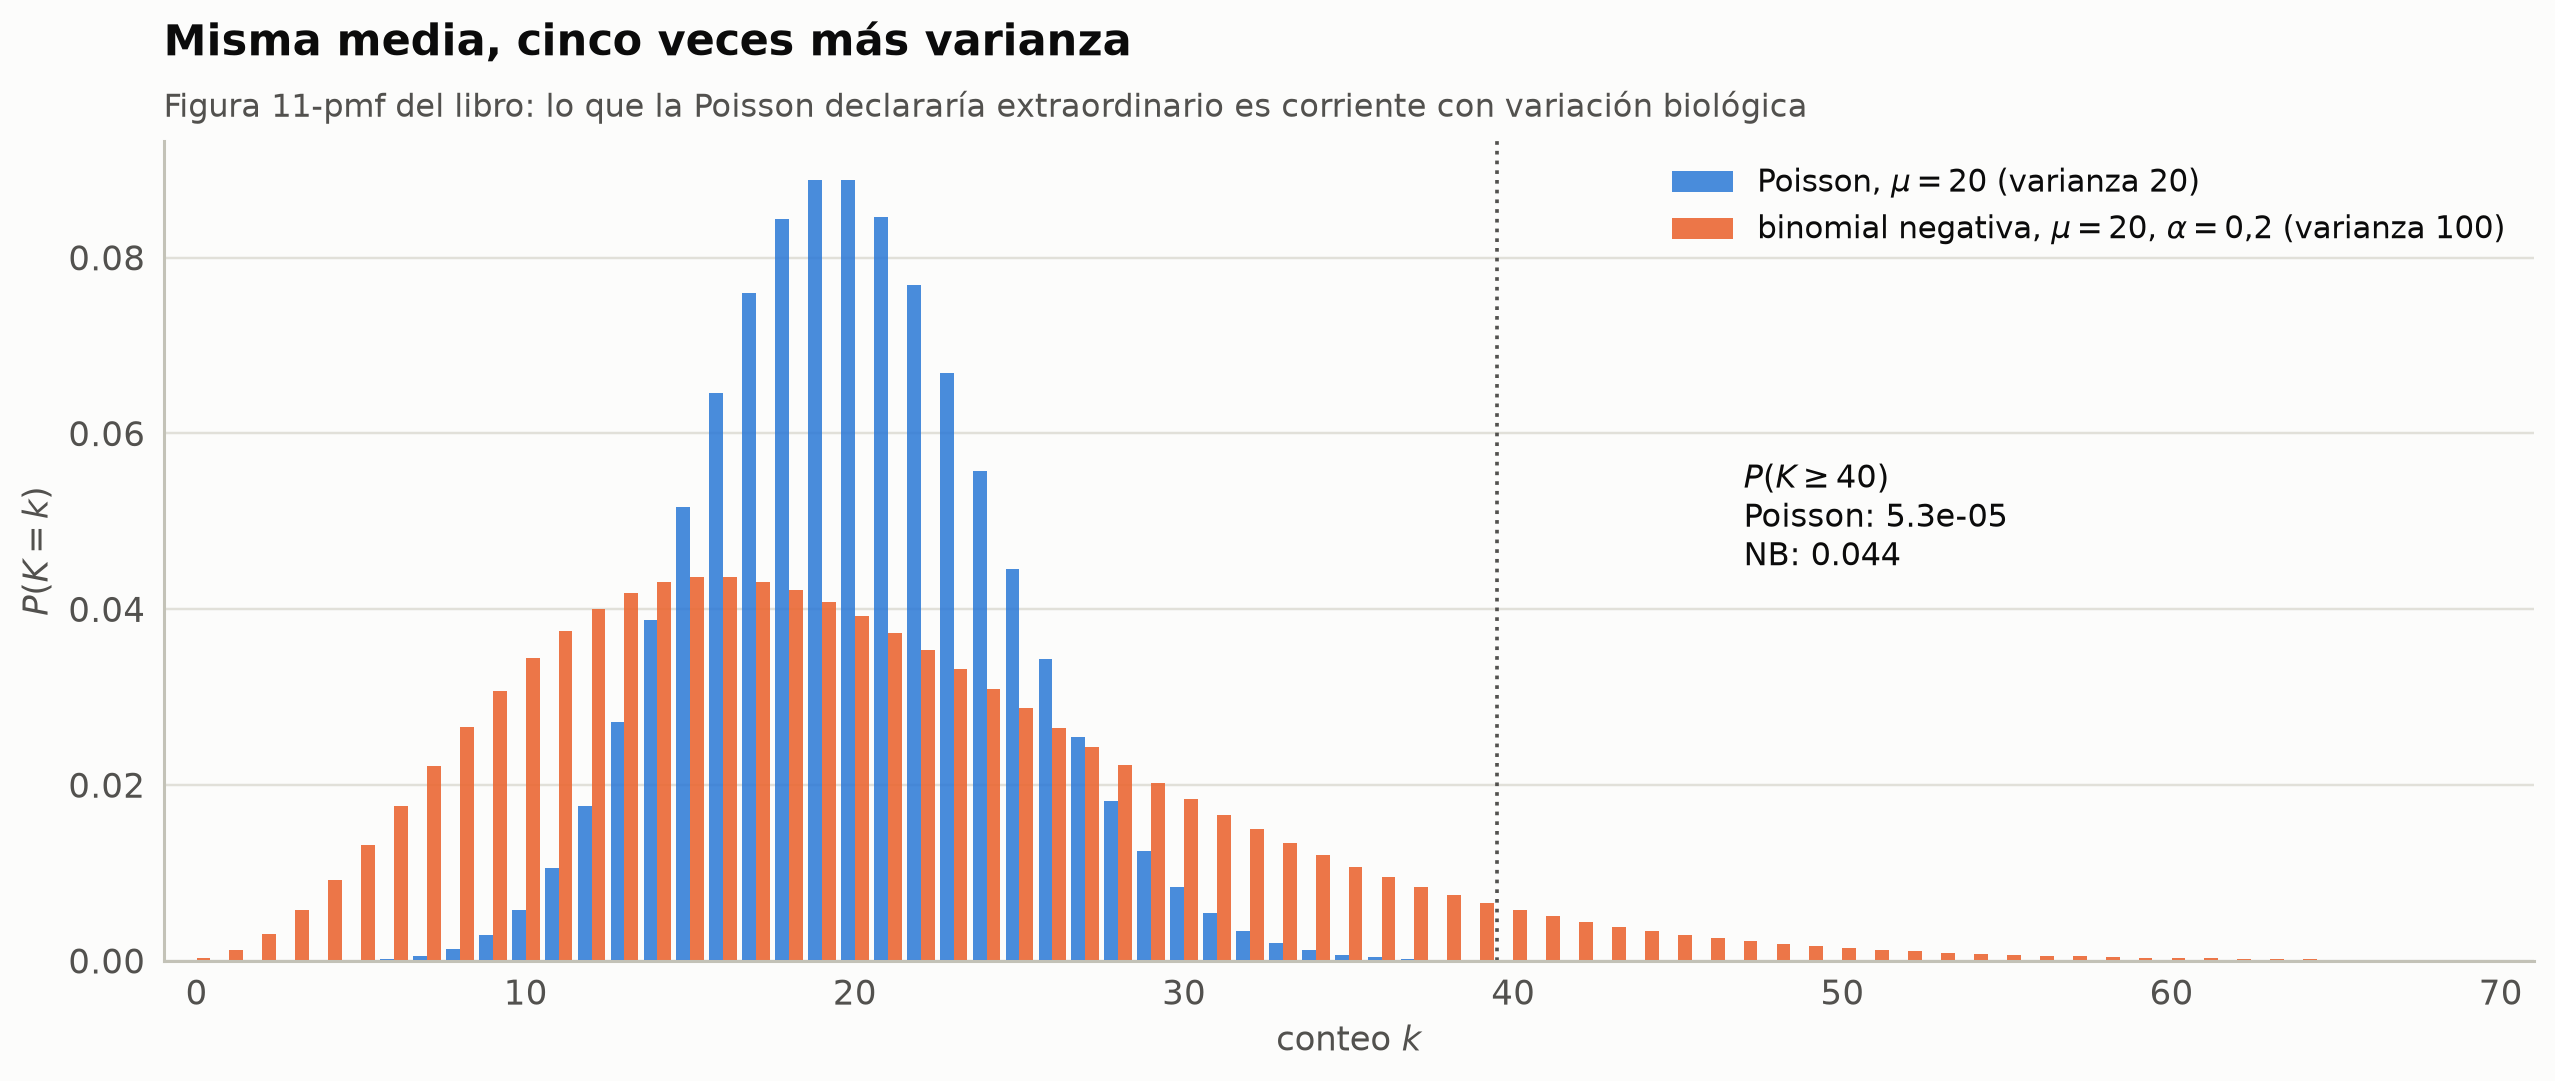

In [17]:
fig, ax = plt.subplots(figsize=(11.5, 4.8))
ax.bar(k - 0.21, pois, width=0.42, color=ec.BLUE, alpha=0.85, label="Poisson, $\\mu=20$ (varianza 20)")
ax.bar(k + 0.21, nbp, width=0.42, color=ec.ORANGE, alpha=0.9, label="binomial negativa, $\\mu=20$, $\\alpha=0{,}2$ (varianza 100)")
ax.axvline(39.5, color=ec.INK_2, ls=":", lw=1.2)
ax.annotate(f"$P(K\\geq40)$\nPoisson: {stats.poisson.sf(39, mu0):.1e}\nNB: {stats.nbinom.sf(39, r0, r0 / (r0 + mu0)):.3f}",
            xy=(40, 0.012), xytext=(47, 0.045), fontsize=10.5, color=ec.INK,
            arrowprops=dict(arrowstyle="->", color=ec.INK_2))
ax.set_xlim(-1, 71); ax.set_xlabel("conteo $k$"); ax.set_ylabel("$P(K=k)$")
ax.legend(loc="upper right", frameon=False)
ec.title(ax, "Misma media, cinco veces más varianza",
         "Figura 11-pmf del libro: lo que la Poisson declararía extraordinario es corriente con variación biológica")
plt.show()

> 🔎 **Qué observamos.** La Poisson (azul) concentra la masa entre 12 y 28 lecturas; la binomial negativa (naranja)
> es mucho más ancha y asimétrica, con una cola derecha larga y hasta un poco de masa en cero. Un conteo de 40 o más
> tiene probabilidad $5\times10^{-5}$ bajo la Poisson, pero $0{,}044$ bajo la binomial negativa: **tres órdenes de
> magnitud**. Si analizáramos réplicas biológicas con un modelo de Poisson, declararíamos «cambio extraordinario»
> lo que en realidad ocurre en una de cada 23 réplicas. La simulación jerárquica (gamma y luego Poisson) confirma
> media 20, varianza ≈ 100 y la misma cola.

### 🎛️ Interactivo: mueva la dispersión

Use el deslizador para cambiar $\alpha$ con $\mu=20$ fijo. Pase el cursor por las barras: verá la probabilidad de cada
conteo bajo ambos modelos y cuántas veces más probable es bajo la binomial negativa.

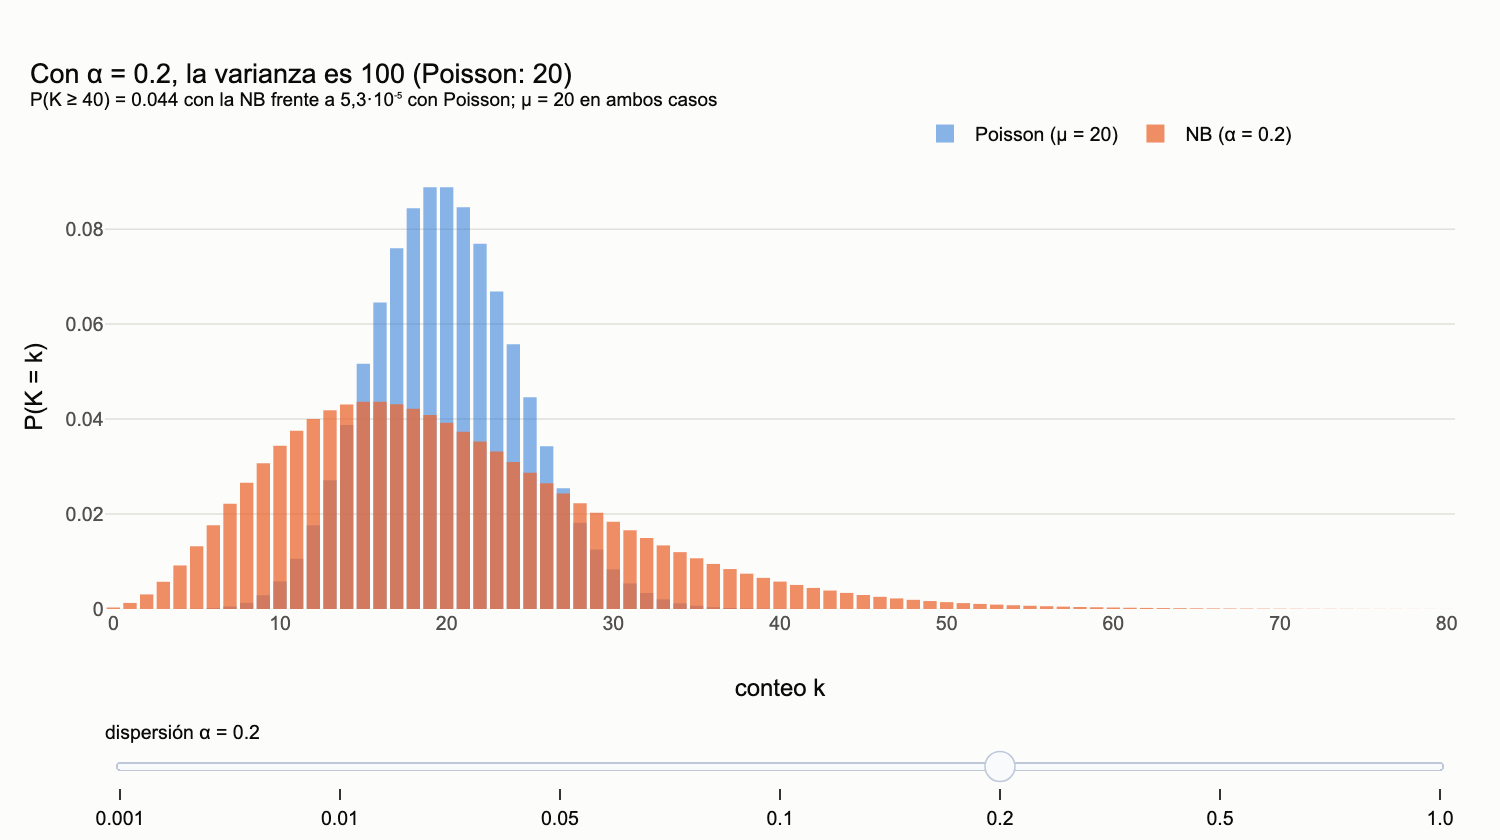

In [18]:
alphas_ui = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
k_ui = np.arange(0, 81)
fig = go.Figure()
fig.add_trace(go.Bar(x=k_ui, y=stats.poisson.pmf(k_ui, 20), name="Poisson (μ = 20)", marker_color=ec.BLUE, opacity=0.55,
                     hovertemplate="k = %{x}<br>Poisson: P = %{y:.4f}<extra></extra>"))
for a in alphas_ui:
    p_nb = nb_pmf(k_ui, 20.0, a)
    ratio = p_nb / np.maximum(stats.poisson.pmf(k_ui, 20), 1e-300)
    fig.add_trace(go.Bar(
        x=k_ui, y=p_nb, name=f"NB (α = {a})", marker_color=ec.ORANGE, opacity=0.75, visible=(a == 0.2),
        customdata=np.column_stack([stats.poisson.pmf(k_ui, 20), ratio]),
        hovertemplate=(f"k = %{{x}}<br>NB (α = {a}, varianza = {20 + a * 400:.0f}): P = %{{y:.4f}}<br>"
                       "Poisson: P = %{customdata[0]:.2e}<br>la NB lo hace %{customdata[1]:.3g} veces más probable"
                       f"<br>CV biológico √α = {np.sqrt(a):.0%}<extra></extra>")))
steps = []
for i, a in enumerate(alphas_ui):
    vis = [True] + [j == i for j in range(len(alphas_ui))]
    tail = stats.nbinom.sf(39, 1 / a, (1 / a) / (1 / a + 20))
    steps.append(dict(method="update", label=str(a),
                      args=[{"visible": vis},
                            {"title.text": f"Con α = {a}, la varianza es {20 + a * 400:.0f} (Poisson: 20)"
                                           f"<br><sup>P(K ≥ 40) = {tail:.2g} con la NB frente a 5,3·10⁻⁵ con Poisson; "
                                           "μ = 20 en ambos casos</sup>"}]))
fig.update_layout(
    barmode="overlay", height=560, margin=dict(t=110, b=150, l=70, r=30),
    title="Con α = 0.2, la varianza es 100 (Poisson: 20)<br><sup>P(K ≥ 40) = 0.044 con la NB frente a 5,3·10⁻⁵ "
          "con Poisson; μ = 20 en ambos casos</sup>",
    xaxis_title="conteo k", yaxis_title="P(K = k)",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0.6),
    sliders=[dict(active=4, steps=steps, currentvalue=dict(prefix="dispersión α = "), pad=dict(t=70))])
fig.show()

> 🔎 **Qué observamos.** Con $\alpha=0{,}001$ las dos distribuciones son indistinguibles: sin variación biológica la
> binomial negativa **es** una Poisson. A medida que $\alpha$ crece, la masa huye del centro hacia cero y hacia la
> cola derecha. Con $\alpha=1$ (CV biológico del 100 %, típico de muestras clínicas muy heterogéneas), el conteo más
> probable es 0 y un 20 % de las réplicas superaría las 40 lecturas.

> ✅ **Compruebe su comprensión.** Un gen tiene $\mu=1000$ y $\alpha=0{,}05$. ¿Qué parte de su varianza es ruido de
> Poisson? *(Var $=1000+0{,}05\cdot10^6=51\,000$; el ruido de Poisson es sólo $1000/51\,000\approx2\,\%$. Secuenciar
> el doble apenas cambiaría la precisión con la que medimos ese gen.)*

## 6. La relación media-varianza

### 6.1 En la simulación del libro

La huella de la binomial negativa en un experimento completo es la **relación media-varianza**: para cada gen se
calcula la media y la varianza entre réplicas, y se dibuja una contra otra en escala doble logarítmica. Reproducimos
la figura 11-mediavar del libro: 1 500 genes con seis réplicas técnicas (Poisson) y seis biológicas (NB con
$\alpha=0{,}1$).

genes con media > 1000: mediana Var/media  Poisson = 0.84, NB = 332.9    (libro: 0.84 y 332.9)


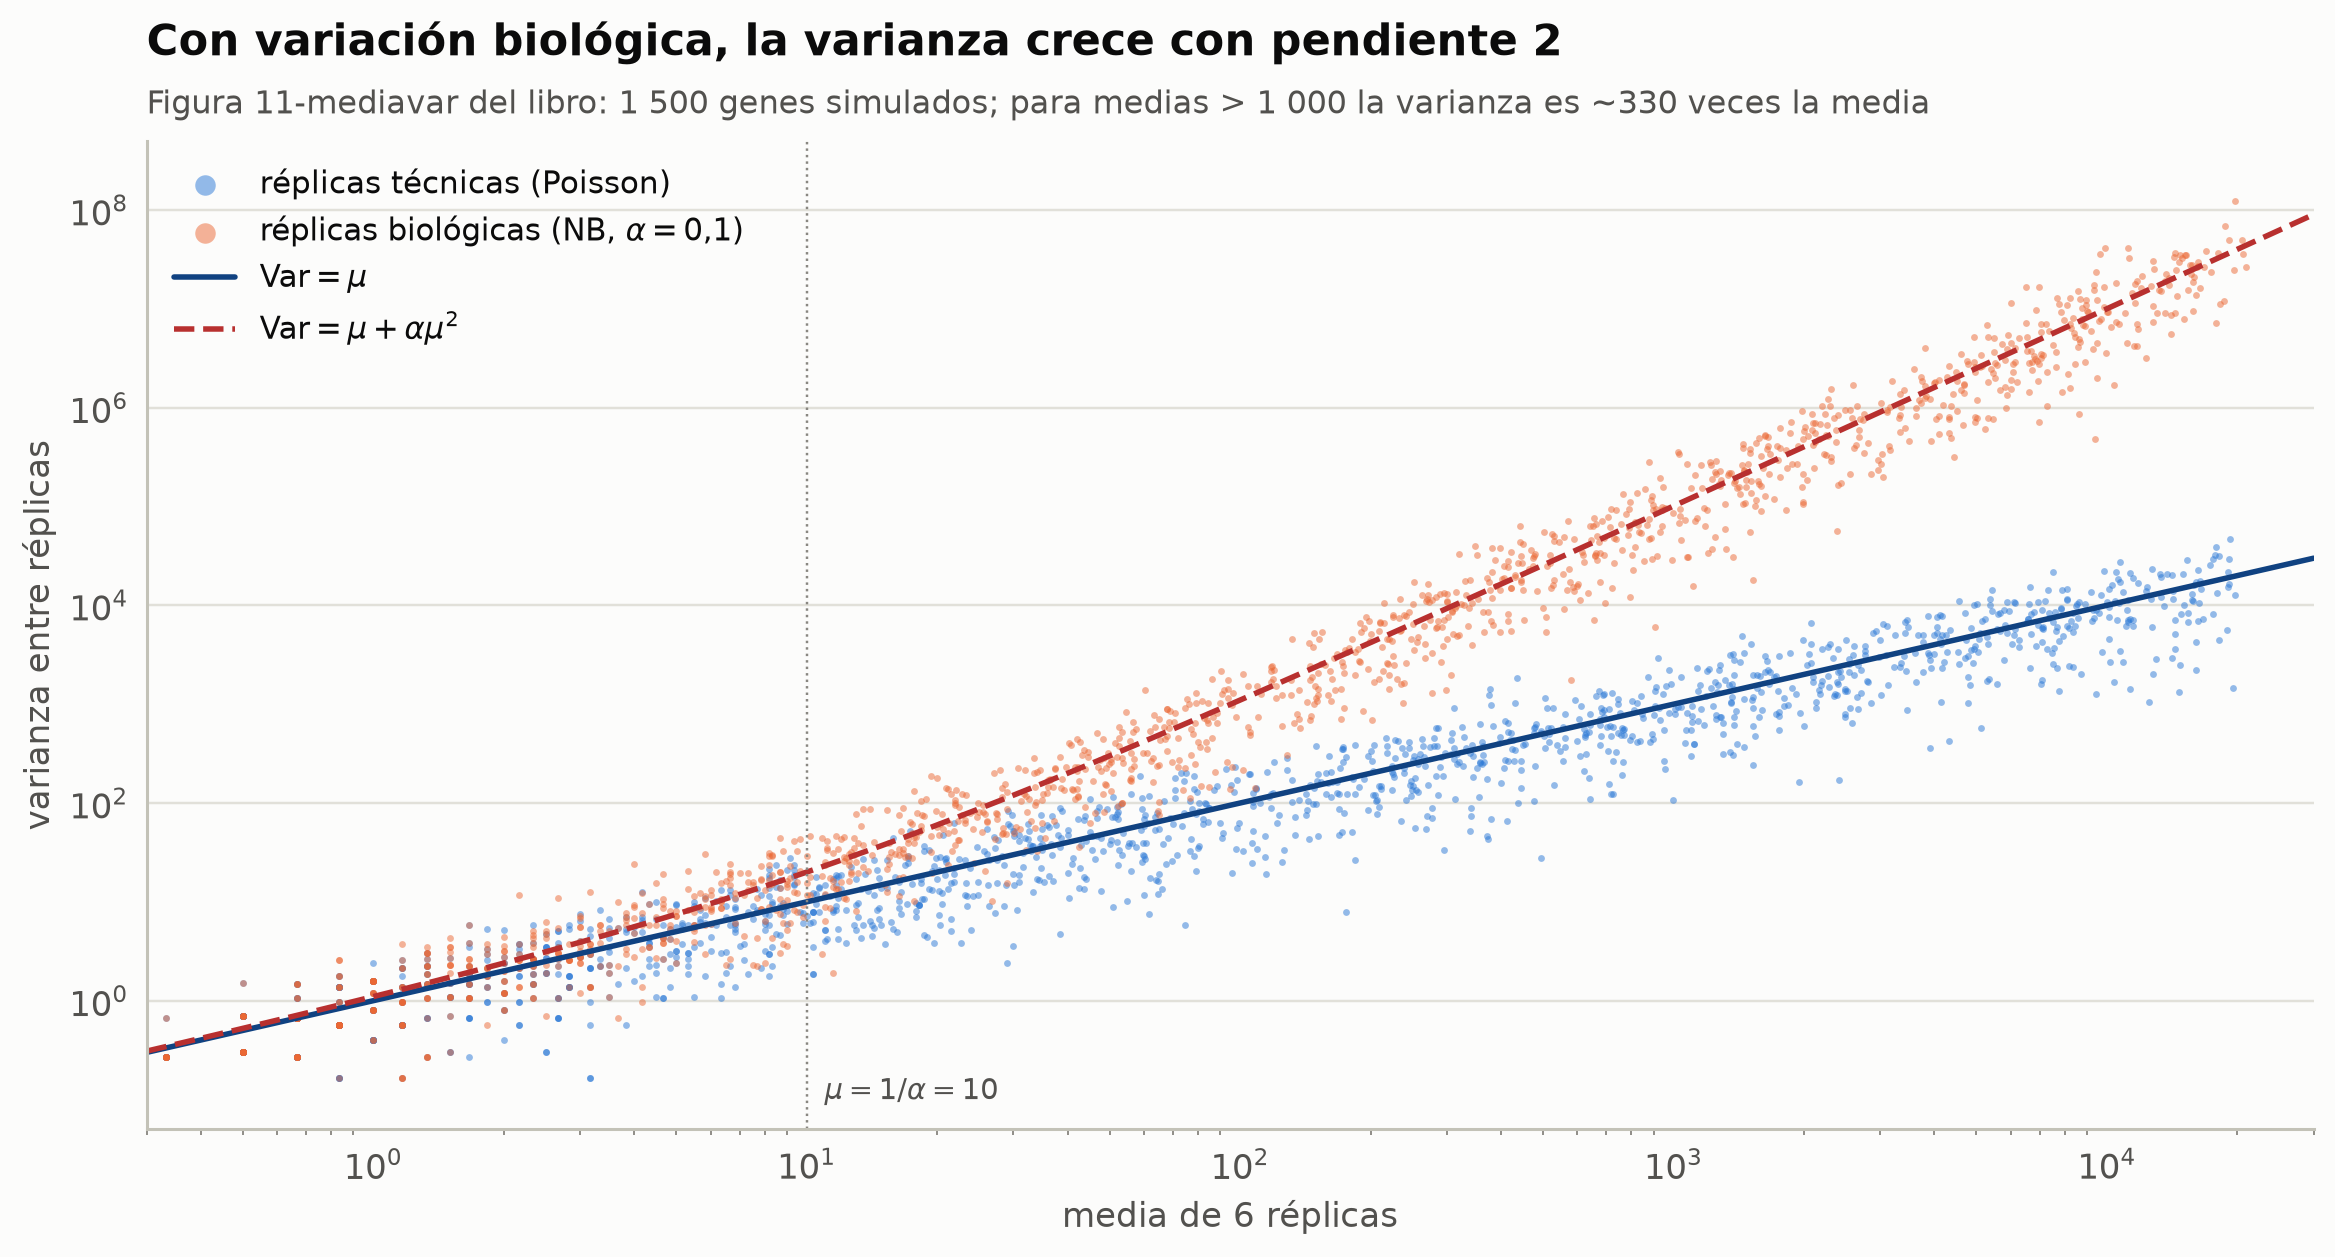

In [19]:
def mean_var(Y):
    m, v = Y.mean(1), Y.var(1, ddof=1)
    ok = (m > 0) & (v > 0)
    return m[ok], v[ok]

mp, vp = mean_var(BOOK["mv_pois"])
mn, vn = mean_var(BOOK["mv_nb"])
print(f"genes con media > 1000: mediana Var/media  Poisson = {np.median(vp[mp > 1000] / mp[mp > 1000]):.2f}, "
      f"NB = {np.median(vn[mn > 1000] / mn[mn > 1000]):.1f}    (libro: 0.84 y 332.9)")

fig, ax = plt.subplots(figsize=(10.5, 5.6))
ax.scatter(mp, vp, s=5, color=ec.BLUE, alpha=0.5, lw=0, label="réplicas técnicas (Poisson)")
ax.scatter(mn, vn, s=5, color=ec.ORANGE, alpha=0.5, lw=0, label="réplicas biológicas (NB, $\\alpha=0{,}1$)")
xx = np.logspace(np.log10(0.3), np.log10(3e4), 100)
ax.plot(xx, xx, color="#104281", lw=1.8, label="$\\mathrm{Var}=\\mu$")
ax.plot(xx, xx + 0.1 * xx ** 2, color="#b8302f", lw=1.8, ls="--", label="$\\mathrm{Var}=\\mu+\\alpha\\mu^2$")
ax.axvline(10, color=ec.MUTED, lw=0.8, ls=":")
ax.text(11, 0.1, "$\\mu=1/\\alpha=10$", color=ec.INK_2, fontsize=9.5)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(0.3, 3e4); ax.set_ylim(0.05, 5e8)
ax.set_xlabel("media de 6 réplicas"); ax.set_ylabel("varianza entre réplicas")
ax.legend(loc="upper left", frameon=False, markerscale=3)
ec.title(ax, "Con variación biológica, la varianza crece con pendiente 2",
         "Figura 11-mediavar del libro: 1 500 genes simulados; para medias > 1 000 la varianza es ~330 veces la media")
plt.show()

> 🔎 **Qué observamos.** Con variación puramente técnica (azul), la nube sigue la diagonal $\mathrm{Var}=\mu$ en todo
> el rango. Con variación biológica (naranja) coincide con ella para genes poco expresados, donde manda el ruido de
> muestreo, pero se **separa con pendiente 2** a partir de $\mu\approx1/\alpha=10$. Para medias superiores a 1 000, la
> varianza es unas 330 veces la media. La dispersión de los puntos alrededor de cada curva es el ruido de estimar una
> varianza con sólo seis observaciones, y anticipa el problema de la sección 8: **estimar $\alpha$ gen a gen es muy
> impreciso**.

### 6.2 En los datos reales

Las cuatro muestras **sin tratar** son réplicas biológicas: cuatro donantes distintos, misma condición. Calculamos
media y varianza de los conteos normalizados $K_{ij}/\hat s_j$ para cada gen. Con conteos normalizados, la parte de
Poisson se multiplica por la media de $1/\hat s_j$, así que la curva de referencia es
$\mathrm{Var}=\mu\,\overline{1/s}+\alpha\mu^2$. Estimamos un $\alpha$ «común» por el método de los momentos con los
genes de más de 1 000 lecturas.

genes con media > 0 5: 29 340
α común (momentos, mediana en genes con media > 1000): 0.0082  →  CV biológico ≈ 9%
en esos genes, Var/media mediana = 20


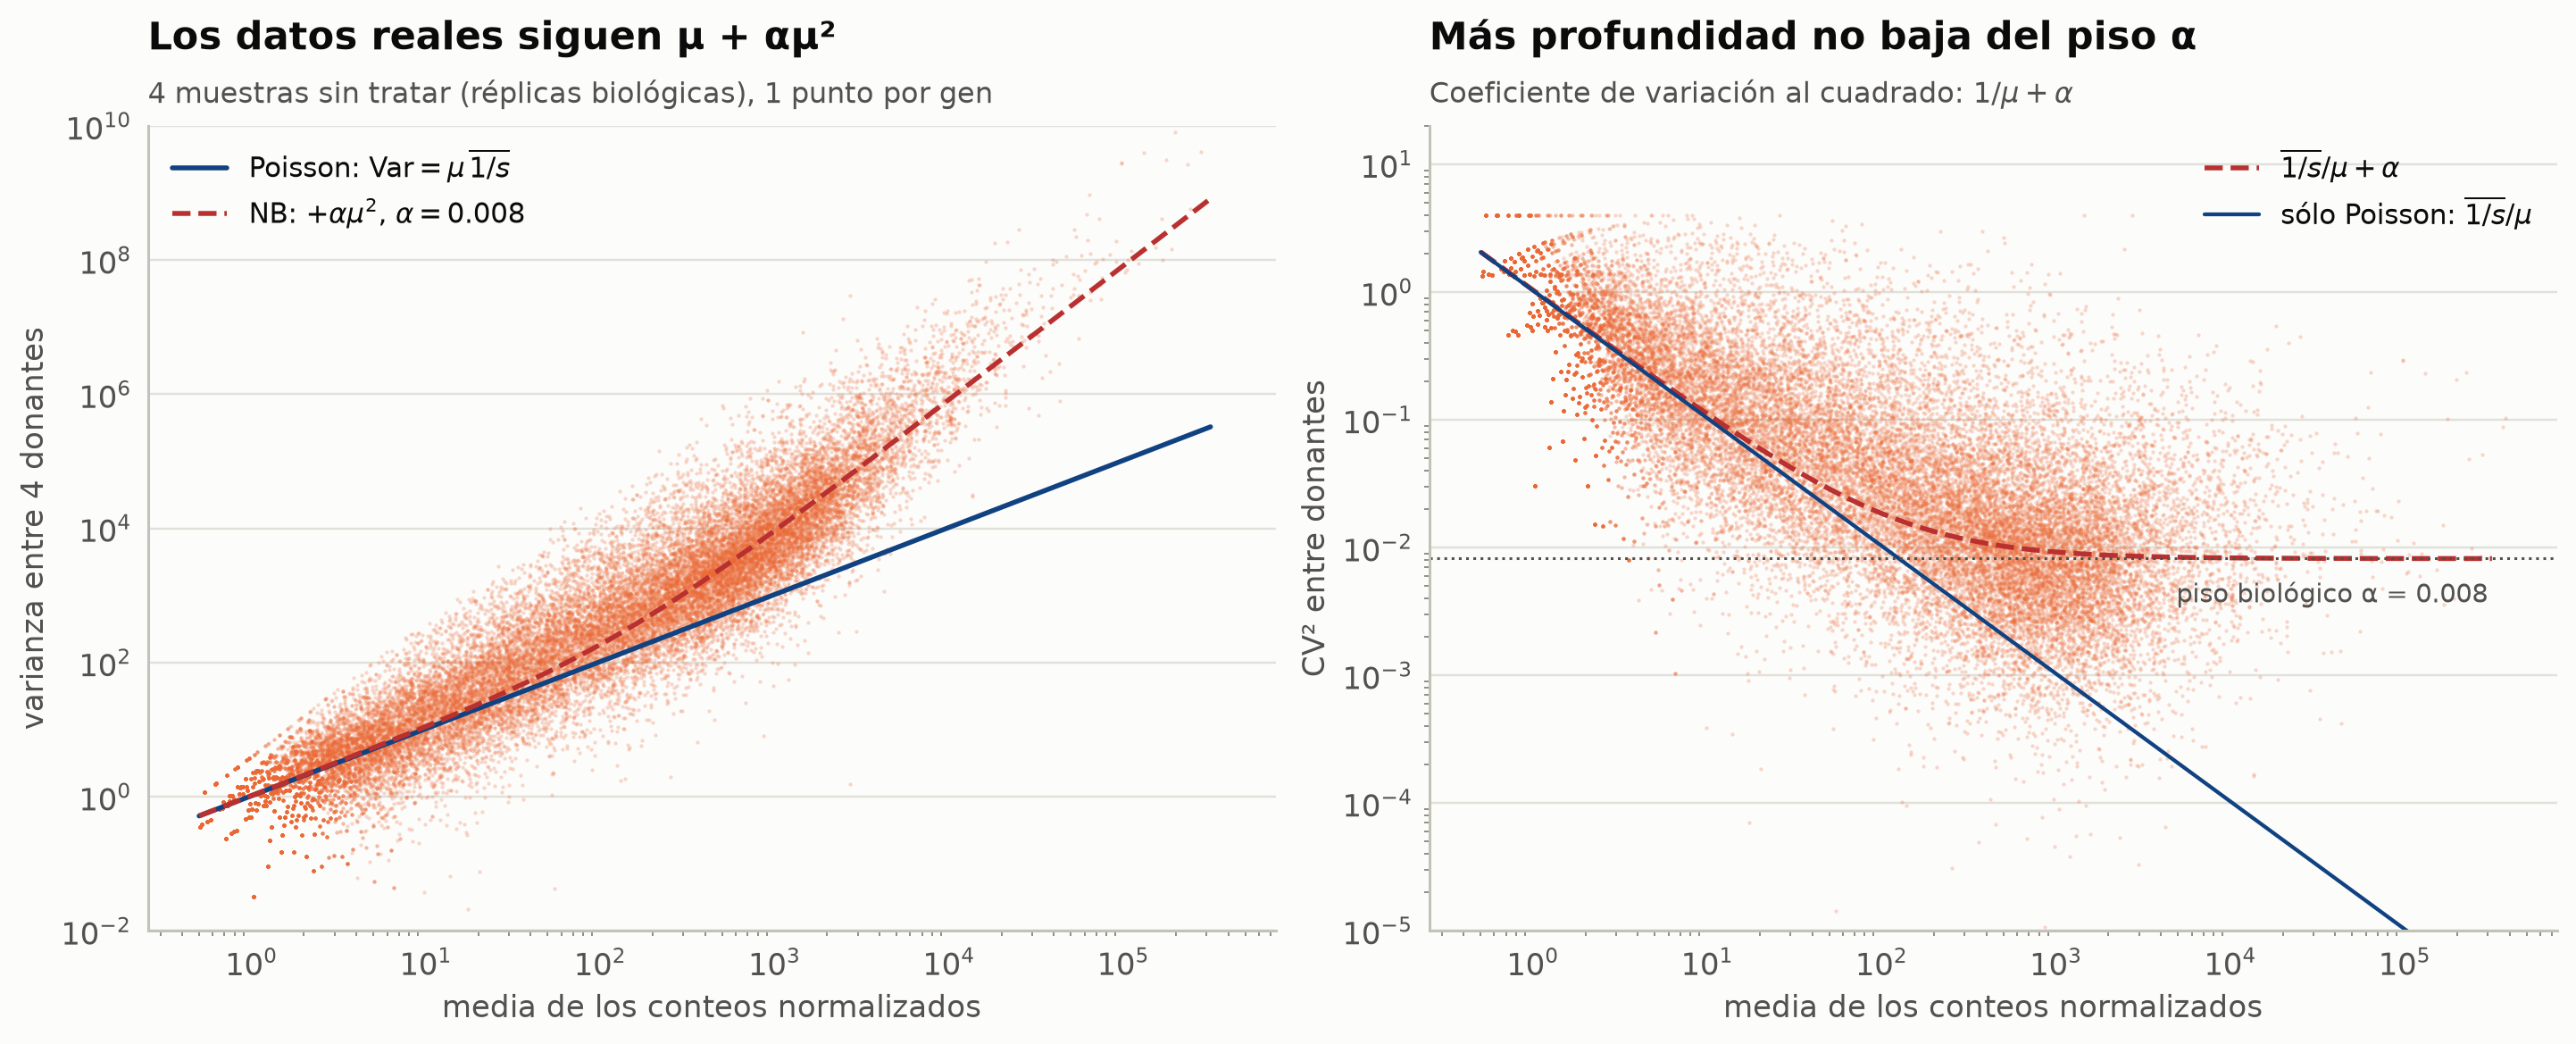

In [20]:
is_untr = (samples.treatment == "Untreated").to_numpy()
s_u = s16[is_untr]
Q_u = K_all[:, is_untr] / s_u                        # conteos normalizados de las 4 réplicas sin tratar
m_u, v_u = Q_u.mean(1), Q_u.var(1, ddof=1)
okmv = m_u > 0.5
inv_s = np.mean(1 / s_u)
hi_u = m_u > 1000
alpha_mom = np.median((v_u[hi_u] - inv_s * m_u[hi_u]) / m_u[hi_u] ** 2)
print(f"genes con media > 0,5: {okmv.sum():,}".replace(",", " "))
print(f"α común (momentos, mediana en genes con media > 1000): {alpha_mom:.4f}  →  CV biológico ≈ {np.sqrt(alpha_mom):.0%}")
print(f"en esos genes, Var/media mediana = {np.median(v_u[hi_u] / m_u[hi_u]):.0f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))
mm, vv = m_u[okmv], np.maximum(v_u[okmv], 1e-2)
ax1.scatter(mm, vv, s=2, color=ec.ORANGE, alpha=0.25, lw=0, rasterized=True)
xx = np.logspace(-0.3, 5.5, 100)
ax1.plot(xx, inv_s * xx, color="#104281", lw=1.8, label="Poisson: $\\mathrm{Var}=\\mu\\,\\overline{1/s}$")
ax1.plot(xx, inv_s * xx + alpha_mom * xx ** 2, color="#b8302f", lw=1.8, ls="--",
         label=f"NB: $+\\alpha\\mu^2$, $\\alpha={alpha_mom:.3f}$")
ax1.set_xscale("log"); ax1.set_yscale("log"); ax1.set_ylim(1e-2, 1e10)
ax1.set_xlabel("media de los conteos normalizados"); ax1.set_ylabel("varianza entre 4 donantes")
ax1.legend(loc="upper left", frameon=False)
ec.title(ax1, "Los datos reales siguen μ + αμ²", "4 muestras sin tratar (réplicas biológicas), 1 punto por gen")
cv2 = v_u[okmv] / m_u[okmv] ** 2
ax2.scatter(mm, cv2, s=2, color=ec.ORANGE, alpha=0.25, lw=0, rasterized=True)
ax2.plot(xx, inv_s / xx + alpha_mom, color="#b8302f", lw=1.8, ls="--", label="$\\overline{1/s}/\\mu+\\alpha$")
ax2.plot(xx, inv_s / xx, color="#104281", lw=1.4, label="sólo Poisson: $\\overline{1/s}/\\mu$")
ax2.axhline(alpha_mom, color=ec.INK_2, lw=1, ls=":")
ax2.text(3e5, alpha_mom / 2.2, f"piso biológico α = {alpha_mom:.3f}", ha="right", fontsize=9.5, color=ec.INK_2)
ax2.set_xscale("log"); ax2.set_yscale("log"); ax2.set_ylim(1e-5, 20)
ax2.set_xlabel("media de los conteos normalizados"); ax2.set_ylabel("CV² entre donantes")
ax2.legend(loc="upper right", frameon=False)
ec.title(ax2, "Más profundidad no baja del piso α", "Coeficiente de variación al cuadrado: $1/\\mu+\\alpha$")
plt.show()

> 🔎 **Qué observamos.** Izquierda: la nube real sigue la diagonal de Poisson en genes de pocas lecturas y se curva
> hacia arriba (pendiente 2) en los muy expresados, exactamente como en la simulación. El $\alpha$ común de estas
> células en cultivo es pequeño (≈ 0,008, un CV biológico de ~9 %): son líneas celulares de laboratorio
> cultivadas en condiciones controladas, mucho más homogéneas que biopsias de pacientes. Derecha: el
> $\mathrm{CV}^2$ baja como $1/\mu$ mientras manda el muestreo y luego **se aplana** en el piso $\alpha$. Un gen con
> 10 000 lecturas no se mide con más precisión *biológica* que uno con 1 000.

**Consecuencia práctica para el diseño.** Con $\alpha\approx0{,}01$ y un gen de $\mu=200$, el CV² por réplica es
$1/200+0{,}01=0{,}015$. Duplicar la profundidad lo baja a $0{,}0125$ (−17 %); duplicar las réplicas divide por dos el
error de la media del grupo (−50 %). En un experimento con presupuesto fijo, **casi siempre conviene más réplicas con
menos lecturas cada una** (Lección 11.1).

## 7. El modelo lineal generalizado

Con la distribución elegida, el modelo completo de DESeq2 (Love et al., 2014), casi idéntico al de edgeR (Robinson
et al., 2010; McCarthy et al., 2012), es un **modelo lineal generalizado** (GLM) con enlace logarítmico:

$$
\boxed{\;K_{ij}\sim\mathrm{NB}\!\left(\mu_{ij},\,\alpha_i\right),\qquad
\mu_{ij}=s_j\,q_{ij},\qquad
\log_2 q_{ij}=\sum_{r}x_{jr}\,\beta_{ir}\;}
\qquad\text{(ecuación 11-glm)}
$$

| Símbolo | Significado |
|---|---|
| $s_j$ | factor de tamaño de la muestra (mediana de razones); entra como **desplazamiento fijo**, no se estima gen a gen |
| $q_{ij}$ | expresión normalizada esperada del gen $i$ en la muestra $j$ |
| $x_{jr}$ | matriz de diseño: condición, lote, donante… de la muestra $j$ |
| $\beta_{ir}$ | coeficientes del gen $i$; con un diseño «$\sim$ lote $+$ condición», el de la condición es el $\log_2$ del cambio (LFC) corregido por lote |
| $\alpha_i$ | dispersión propia del gen $i$ |

Esta formulación tiene tres virtudes. Los conteos se modelan **crudos**, con la normalización como desplazamiento,
así que el modelo sabe que 10 lecturas son menos fiables que 10 000. El enlace logarítmico hace que los efectos sean
**multiplicativos**, que es como se comporta la expresión. Y la matriz de diseño admite cualquier experimento:
covariables, lotes, interacciones, datos **pareados**.

### 7.1 La matriz de diseño de *airway*

Nuestro diseño principal es `~ cell + dex`: 8 muestras, un intercepto (línea N61311 sin tratar), tres columnas que
permiten a cada una de las otras líneas su propio nivel basal, y una columna de dexametasona. El coeficiente de
dexametasona compara **cada muestra tratada con la sin tratar de su misma línea**: el diseño pareado elimina la
variación entre donantes del error del efecto.

In [21]:
is8 = samples.treatment.isin(["Untreated", "Dexamethasone"]).to_numpy()
S8 = samples[is8].reset_index(drop=True)
K8 = K_all[:, is8]
s8 = size_factors(K8)                                     # factores de tamaño de las 8 muestras del diseño
cells = list(dict.fromkeys(S8.cell))                      # orden de aparición: N61311 es la referencia
X = np.column_stack([np.ones(8)] + [(S8.cell == c).to_numpy(float) for c in cells[1:]]
                    + [(S8.treatment == "Dexamethasone").to_numpy(float)])
COEF = ["intercepto"] + [f"línea {c}" for c in cells[1:]] + ["dexametasona"]
pd.DataFrame(X.astype(int), columns=COEF, index=[f"{r} ({c}, {t})" for r, c, t in zip(S8.run, S8.cell, S8.tratamiento)]) \
  .assign(s_j=s8.round(3))

,intercepto,línea N052611,línea N080611,línea N061011,dexametasona,s_j
"SRR1039508 (N61311, sin tratar)",1,0,0,0,0,0.768
"SRR1039509 (N61311, dexametasona)",1,0,0,0,1,0.679
"SRR1039512 (N052611, sin tratar)",1,1,0,0,0,0.897
"SRR1039513 (N052611, dexametasona)",1,1,0,0,1,1.369
"SRR1039516 (N080611, sin tratar)",1,0,1,0,0,0.999
"SRR1039517 (N080611, dexametasona)",1,0,1,0,1,1.059
"SRR1039520 (N061011, sin tratar)",1,0,0,1,0,1.168
"SRR1039521 (N061011, dexametasona)",1,0,0,1,1,1.298


### 7.2 Máxima verosimilitud por IRLS

Los $\beta$ se estiman por máxima verosimilitud con **mínimos cuadrados iterativamente reponderados** (IRLS): en cada
iteración se linealiza el modelo alrededor del ajuste actual y se resuelve un problema de mínimos cuadrados
ponderados. Para la NB, los pesos y la covarianza de los coeficientes son

$$
W_{jj}=\frac{\mu_{ij}}{1+\alpha_i\mu_{ij}},\qquad
\widehat{\mathrm{Cov}}(\hat\beta_i)=\left(X^{\top}WX\right)^{-1}
\qquad\text{(ecuación 11-irls)}
$$

| Símbolo | Significado |
|---|---|
| $W$ | matriz diagonal de pesos: la información de Fisher que aporta cada observación |
| $X$ | matriz de diseño ($m$ muestras $\times$ $p$ coeficientes) |
| $z$ | «respuesta de trabajo» $z_j=\eta_j-\log s_j+(K_{ij}-\mu_{ij})/\mu_{ij}$, con $\eta_j=\log\mu_{ij}$ |

El peso **tiende a $1/\alpha_i$** cuando $\mu$ crece: por muchos conteos que tenga una muestra, su información está
acotada por la variación biológica. Es la misma lección de la sección 6, ahora dentro de la maquinaria del ajuste.
Implementamos IRLS **vectorizado**: resolvemos a la vez los sistemas $5\times5$ de decenas de miles de genes.

In [22]:
def irls_nb(Y, X, s, alpha, iters=25):
    """GLM binomial negativo con enlace log y desplazamiento log(s), para muchos genes a la vez.
    Y: genes × muestras; alpha: dispersión por gen. Devuelve beta (escala ln), mu ajustada y errores estándar."""
    Y = np.asarray(Y, float); G, p = Y.shape[0], X.shape[1]
    off = np.log(s)[None, :]
    beta = np.zeros((G, p))
    beta[:, 0] = np.log(np.maximum((Y / s).mean(1), 0.5))          # arranque: media normalizada
    for _ in range(iters):
        eta = beta @ X.T + off
        mu = np.exp(eta)
        W = mu / (1 + alpha[:, None] * mu)                          # pesos IRLS de la NB (ecuación 11-irls)
        z = eta - off + (Y - mu) / mu                               # respuesta de trabajo
        XtWX = np.einsum("jr,gj,js->grs", X, W, X) + 1e-9 * np.eye(p)
        XtWz = np.einsum("jr,gj->gr", X, W * z)
        beta = np.clip(np.linalg.solve(XtWX, XtWz[..., None])[..., 0], -30, 30)
    mu = np.exp(beta @ X.T + off)
    W = mu / (1 + alpha[:, None] * mu)
    cov = np.linalg.inv(np.einsum("jr,gj,js->grs", X, W, X))
    return beta, mu, np.sqrt(np.einsum("grr->gr", cov))

demo = ["FKBP5", "ZBTB16", "TSC22D3", "GAPDH"]
idx_demo = [int(np.where(SYMBOL == g)[0][0]) for g in demo]
b_demo, mu_demo, se_demo = irls_nb(K8[idx_demo], X, s8, np.full(4, 0.02))
for g, b, se in zip(demo, b_demo, se_demo):
    print(f"{g:<8} LFC dexametasona = {b[-1] / np.log(2):+.2f} (EE {se[-1] / np.log(2):.2f})  →  ×{2 ** (b[-1] / np.log(2)):.1f}")
print("(α = 0,02 provisional; la dispersión de cada gen se estima en la sección 8 y el análisis formal llega en 11.3)")

FKBP5    LFC dexametasona = +4.02 (EE 0.15)  →  ×16.2
ZBTB16   LFC dexametasona = +7.16 (EE 0.33)  →  ×142.7
TSC22D3  LFC dexametasona = +3.20 (EE 0.15)  →  ×9.2
GAPDH    LFC dexametasona = -0.19 (EE 0.14)  →  ×0.9
(α = 0,02 provisional; la dispersión de cada gen se estima en la sección 8 y el análisis formal llega en 11.3)


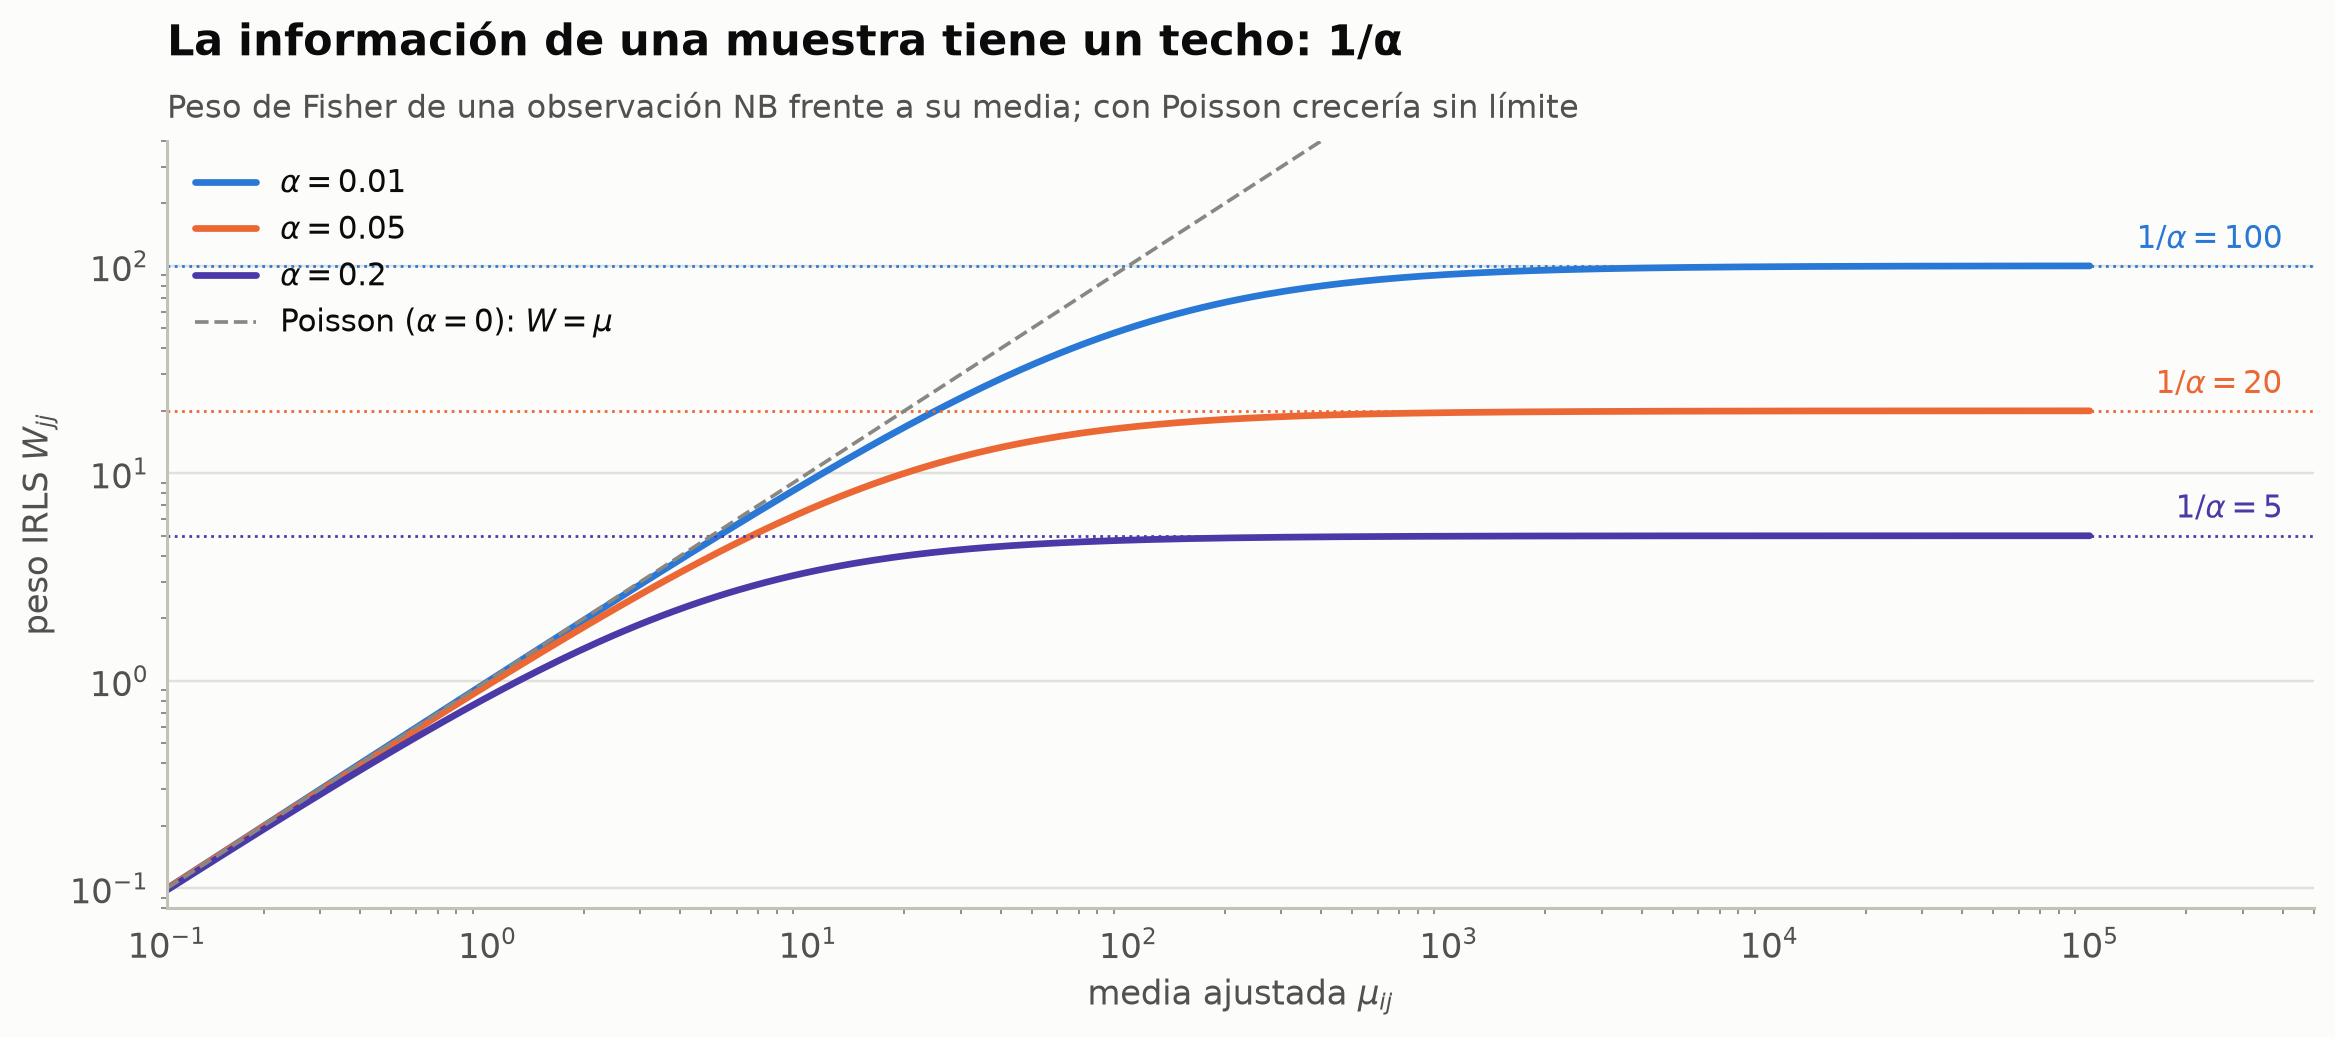

In [23]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
mu_grid = np.logspace(-1, 5, 300)
for a, c in zip([0.01, 0.05, 0.2], [ec.BLUE, ec.ORANGE, ec.VIOLET]):
    ax.plot(mu_grid, mu_grid / (1 + a * mu_grid), color=c, lw=2.2, label=f"$\\alpha={a}$")
    ax.axhline(1 / a, color=c, lw=0.9, ls=":")
    ax.text(4e5, 1 / a * 1.12, f"$1/\\alpha={1 / a:.0f}$", va="bottom", ha="right", fontsize=10, color=c)
ax.plot(mu_grid, mu_grid, color=ec.MUTED, lw=1.2, ls="--", label="Poisson ($\\alpha=0$): $W=\\mu$")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(0.1, 5e5); ax.set_ylim(0.08, 400)
ax.set_xlabel("media ajustada $\\mu_{ij}$"); ax.set_ylabel("peso IRLS $W_{jj}$")
ax.legend(loc="upper left", frameon=False)
ec.title(ax, "La información de una muestra tiene un techo: 1/α",
         "Peso de Fisher de una observación NB frente a su media; con Poisson crecería sin límite")
plt.show()

> 🔎 **Qué observamos.** Los genes de respuesta a glucocorticoides salen con cambios enormes (*ZBTB16* se multiplica
> por cientos, *FKBP5* por más de diez), mientras que *GAPDH* apenas se mueve: el GLM pareado ya «ve» la biología. En
> la figura, el peso de una observación crece como $\mu$ mientras manda Poisson y se estanca en $1/\alpha$: con
> $\alpha=0{,}05$, una muestra nunca aporta más información que 20 lecturas de Poisson, por muchas que tenga.

## 8. Estimar la dispersión con pocas réplicas: contracción

Todo depende de $\alpha_i$, y $\alpha_i$ es **muy difícil de estimar con tres o cuatro réplicas**: la figura de la
sección 6.1 mostraba cuánto se dispersan las varianzas muestrales. Si subestimamos $\alpha_i$, los errores estándar
serán demasiado pequeños y aparecerán **falsos positivos**; si la sobreestimamos, perderemos **potencia**.

La salida es **compartir información entre genes**. Aunque cada gen tiene su propia dispersión, los genes de
expresión similar tienen dispersiones parecidas, y con veinte mil genes podemos aprender esa regularidad con gran
precisión. Es lo que hace un buen tasador: el precio de una casa concreta se estima mejor combinando su propia
información con lo que se sabe de las casas parecidas del barrio. El procedimiento de DESeq2, un ejemplo de **Bayes
empírico**, tiene tres pasos:

1. **Estimación gen a gen**, $\hat\alpha_i^{\,\mathrm{gw}}$, por máxima verosimilitud con el **ajuste de Cox-Reid**,
   que corrige el sesgo de estimar la dispersión después de haber estimado los $\beta$ con las mismas observaciones:
   $\ell^{\mathrm{CR}}_i(\alpha)=\ell_i(\alpha)-\tfrac12\log\det\!\left(X^\top WX\right)$.
2. **Tendencia**: se ajusta una curva $\alpha_{\mathrm{tr}}(\bar\mu)$ de las estimaciones gen a gen frente a la media
   normalizada.
3. **Contracción**: se combina la verosimilitud de cada gen con una distribución previa log-normal centrada en la
   tendencia y se toma el máximo *a posteriori*.

En fórmulas,

$$
\alpha_{\mathrm{tr}}(\bar\mu)=a_0+\frac{a_1}{\bar\mu},\qquad
\log\alpha_i\sim\mathcal N\!\left(\log\alpha_{\mathrm{tr}}(\bar\mu_i),\,\sigma_d^2\right)
\qquad\text{(ecuación 11-disp)}
$$

$$
\boxed{\;\hat\alpha_i^{\,\mathrm{MAP}}=\operatorname*{arg\,max}_{\alpha}\Big[\ell_i(\alpha)+\log p(\alpha)\Big]\;}
\qquad\text{(ecuación 11-map)}
$$

| Símbolo | Significado |
|---|---|
| $\bar\mu_i$ | media de los conteos normalizados del gen $i$ |
| $a_0,\ a_1$ | parámetros de la tendencia: $a_0$ es la dispersión biológica asintótica; $a_1/\bar\mu$ recoge el exceso de variabilidad de los genes poco expresados |
| $\sigma_d^2$ | varianza previa: cuánto se apartan de verdad las dispersiones de la tendencia, estimada restando a la varianza de los residuos la varianza de muestreo esperada |
| $\ell_i(\alpha)$ | log-verosimilitud (ajustada por Cox-Reid) del gen $i$ como función de la dispersión |
| $p(\alpha)$ | densidad previa log-normal de la ecuación 11-disp |

La cantidad de contracción **se regula sola**. Con pocas réplicas, la verosimilitud de cada gen es plana y la previa
pesa mucho; con muchas, la verosimilitud es aguda y domina. Los genes cuya estimación gen a gen queda muy por encima
de la tendencia (más de dos desviaciones previas) **conservan su valor propio**, para no ocultar una variabilidad
real.

**¿De dónde sale la varianza de muestreo?** Si la varianza de un gen se estima con $\nu=m-p$ grados de libertad
residuales, $\hat\sigma^2/\sigma^2\sim\chi^2_\nu/\nu$, y la varianza de su logaritmo es la función **trigamma**
$\psi_1(\nu/2)$. Restarla a la varianza observada de los residuos $\log\hat\alpha^{\mathrm{gw}}-\log\alpha_{\mathrm{tr}}$
deja la parte que se debe a diferencias **reales** entre genes: $\sigma_d^2$.

### 8.1 La simulación del libro, paso a paso

Usamos el experimento 3 frente a 3 del libro (10 000 genes simulados, de los que 9 992 tienen alguna lectura). Como
el diseño es de dos grupos, las medias ajustadas son las medias de grupo, y la verosimilitud se evalúa en una rejilla
de 300 valores de $\alpha$ entre $10^{-4}$ y 20.

In [24]:
def nb_loglik(y, m, a):
    """Log-verosimilitud NB elemento a elemento (media m, dispersión a)."""
    r = 1.0 / a
    return (special.gammaln(y + r) - special.gammaln(r) - special.gammaln(y + 1)
            + r * np.log(r / (r + m)) + y * np.log(m / (r + m)))

Yb, condb = BOOK["Y"], BOOK["cond"]
sfb = size_factors(Yb)
print("factores de tamaño estimados:", sfb.round(3), "  libro: [0.784 1.175 0.98 0.888 1.283 1.088]")
Ynb = Yb / sfb
base_b = Ynb.mean(1)
qg = np.stack([Ynb[:, condb == c].mean(1) for c in (0, 1)], 1)       # medias de grupo (normalizadas)
mu_hat_b = np.maximum(qg[:, condb] * sfb[None, :], 1e-8)
GRID = np.exp(np.linspace(np.log(1e-4), np.log(20), 300))

# Paso 1: gen a gen, con ajuste de Cox-Reid  -0,5·log det(XᵀWX)  (para dos grupos, det = s00·s11 − s01²)
LLb = np.stack([nb_loglik(Yb, mu_hat_b, a).sum(1) for a in GRID], 1)
def cr_adj(a):
    Wm = mu_hat_b / (1 + a * mu_hat_b)
    s00 = Wm.sum(1); s01 = (Wm * condb).sum(1)
    return -0.5 * np.log(s00 * s01 - s01 ** 2)
LLb += np.stack([cr_adj(a) for a in GRID], 1)
a_gw_b = GRID[LLb.argmax(1)]

# Paso 2: tendencia a0 + a1/μ, ajustada como un GLM gamma con enlace identidad (minimizando la devianza gamma)
def fit_trend(base, a_gw):
    use = (base > 1) & (a_gw > 1e-3) & (a_gw < GRID[-1])
    def gdev(p):
        f = np.abs(p[0]) + np.abs(p[1]) / base[use]
        r = a_gw[use] / f
        return 2 * np.sum(r - np.log(r) - 1)
    p = optimize.minimize(gdev, [0.1, 1.0], method="Nelder-Mead").x
    return abs(p[0]), abs(p[1]), use

a0_b, a1_b, use_b = fit_trend(base_b, a_gw_b)
a_tr_b = a0_b + a1_b / base_b
print(f"tendencia: a0 = {a0_b:.4f}, a1 = {a1_b:.3f}   (libro: 0.0480 y 1.757; verdad: 0.05 y 1)")

# Paso 3: varianza previa y máximo a posteriori
res_b = np.log(a_gw_b[use_b]) - np.log(a_tr_b[use_b])
sd_rob_b = stats.median_abs_deviation(res_b, scale="normal")
samp_b = special.polygamma(1, (6 - 2) / 2)                          # trigamma(ν/2) con ν = 6 − 2
s2p_b = max(sd_rob_b ** 2 - samp_b, 0.25)
print(f"sd robusta de los residuos = {sd_rob_b:.3f}; var. de muestreo = {samp_b:.3f}; var. previa = {s2p_b:.3f}"
      "   (libro: 0.950, 0.645, 0.257)")
logprior_b = -0.5 * (np.log(GRID)[None, :] - np.log(a_tr_b)[:, None]) ** 2 / s2p_b
a_map_b = GRID[(LLb + logprior_b).argmax(1)]
outl_b = np.log(a_gw_b) > np.log(a_tr_b) + 2 * np.sqrt(s2p_b)
a_fin_b = np.where(outl_b, a_gw_b, a_map_b)
true_b = BOOK["disp"]
print(f"genes con dispersión atípica (> 2 sd sobre la tendencia) = {outl_b.sum()}   (libro: 406)")
e_gw = np.mean((np.log(a_gw_b) - np.log(true_b))[base_b > 1] ** 2)
e_map = np.mean((np.log(a_map_b) - np.log(true_b))[base_b > 1] ** 2)
print(f"error cuadrático medio en log: gen a gen = {e_gw:.3f}, MAP = {e_map:.3f}   (libro: 6.602 y 0.172)")
print(f"estimaciones gen a gen en el límite inferior 1e-4: {np.mean(a_gw_b[base_b > 0.5] <= GRID[0]):.0%}")

factores de tamaño estimados: [0.784 1.175 0.98  0.888 1.283 1.088]   libro: [0.784 1.175 0.98 0.888 1.283 1.088]


tendencia: a0 = 0.0480, a1 = 1.757   (libro: 0.0480 y 1.757; verdad: 0.05 y 1)
sd robusta de los residuos = 0.950; var. de muestreo = 0.645; var. previa = 0.257   (libro: 0.950, 0.645, 0.257)
genes con dispersión atípica (> 2 sd sobre la tendencia) = 406   (libro: 406)
error cuadrático medio en log: gen a gen = 6.602, MAP = 0.172   (libro: 6.602 y 0.172)
estimaciones gen a gen en el límite inferior 1e-4: 11%


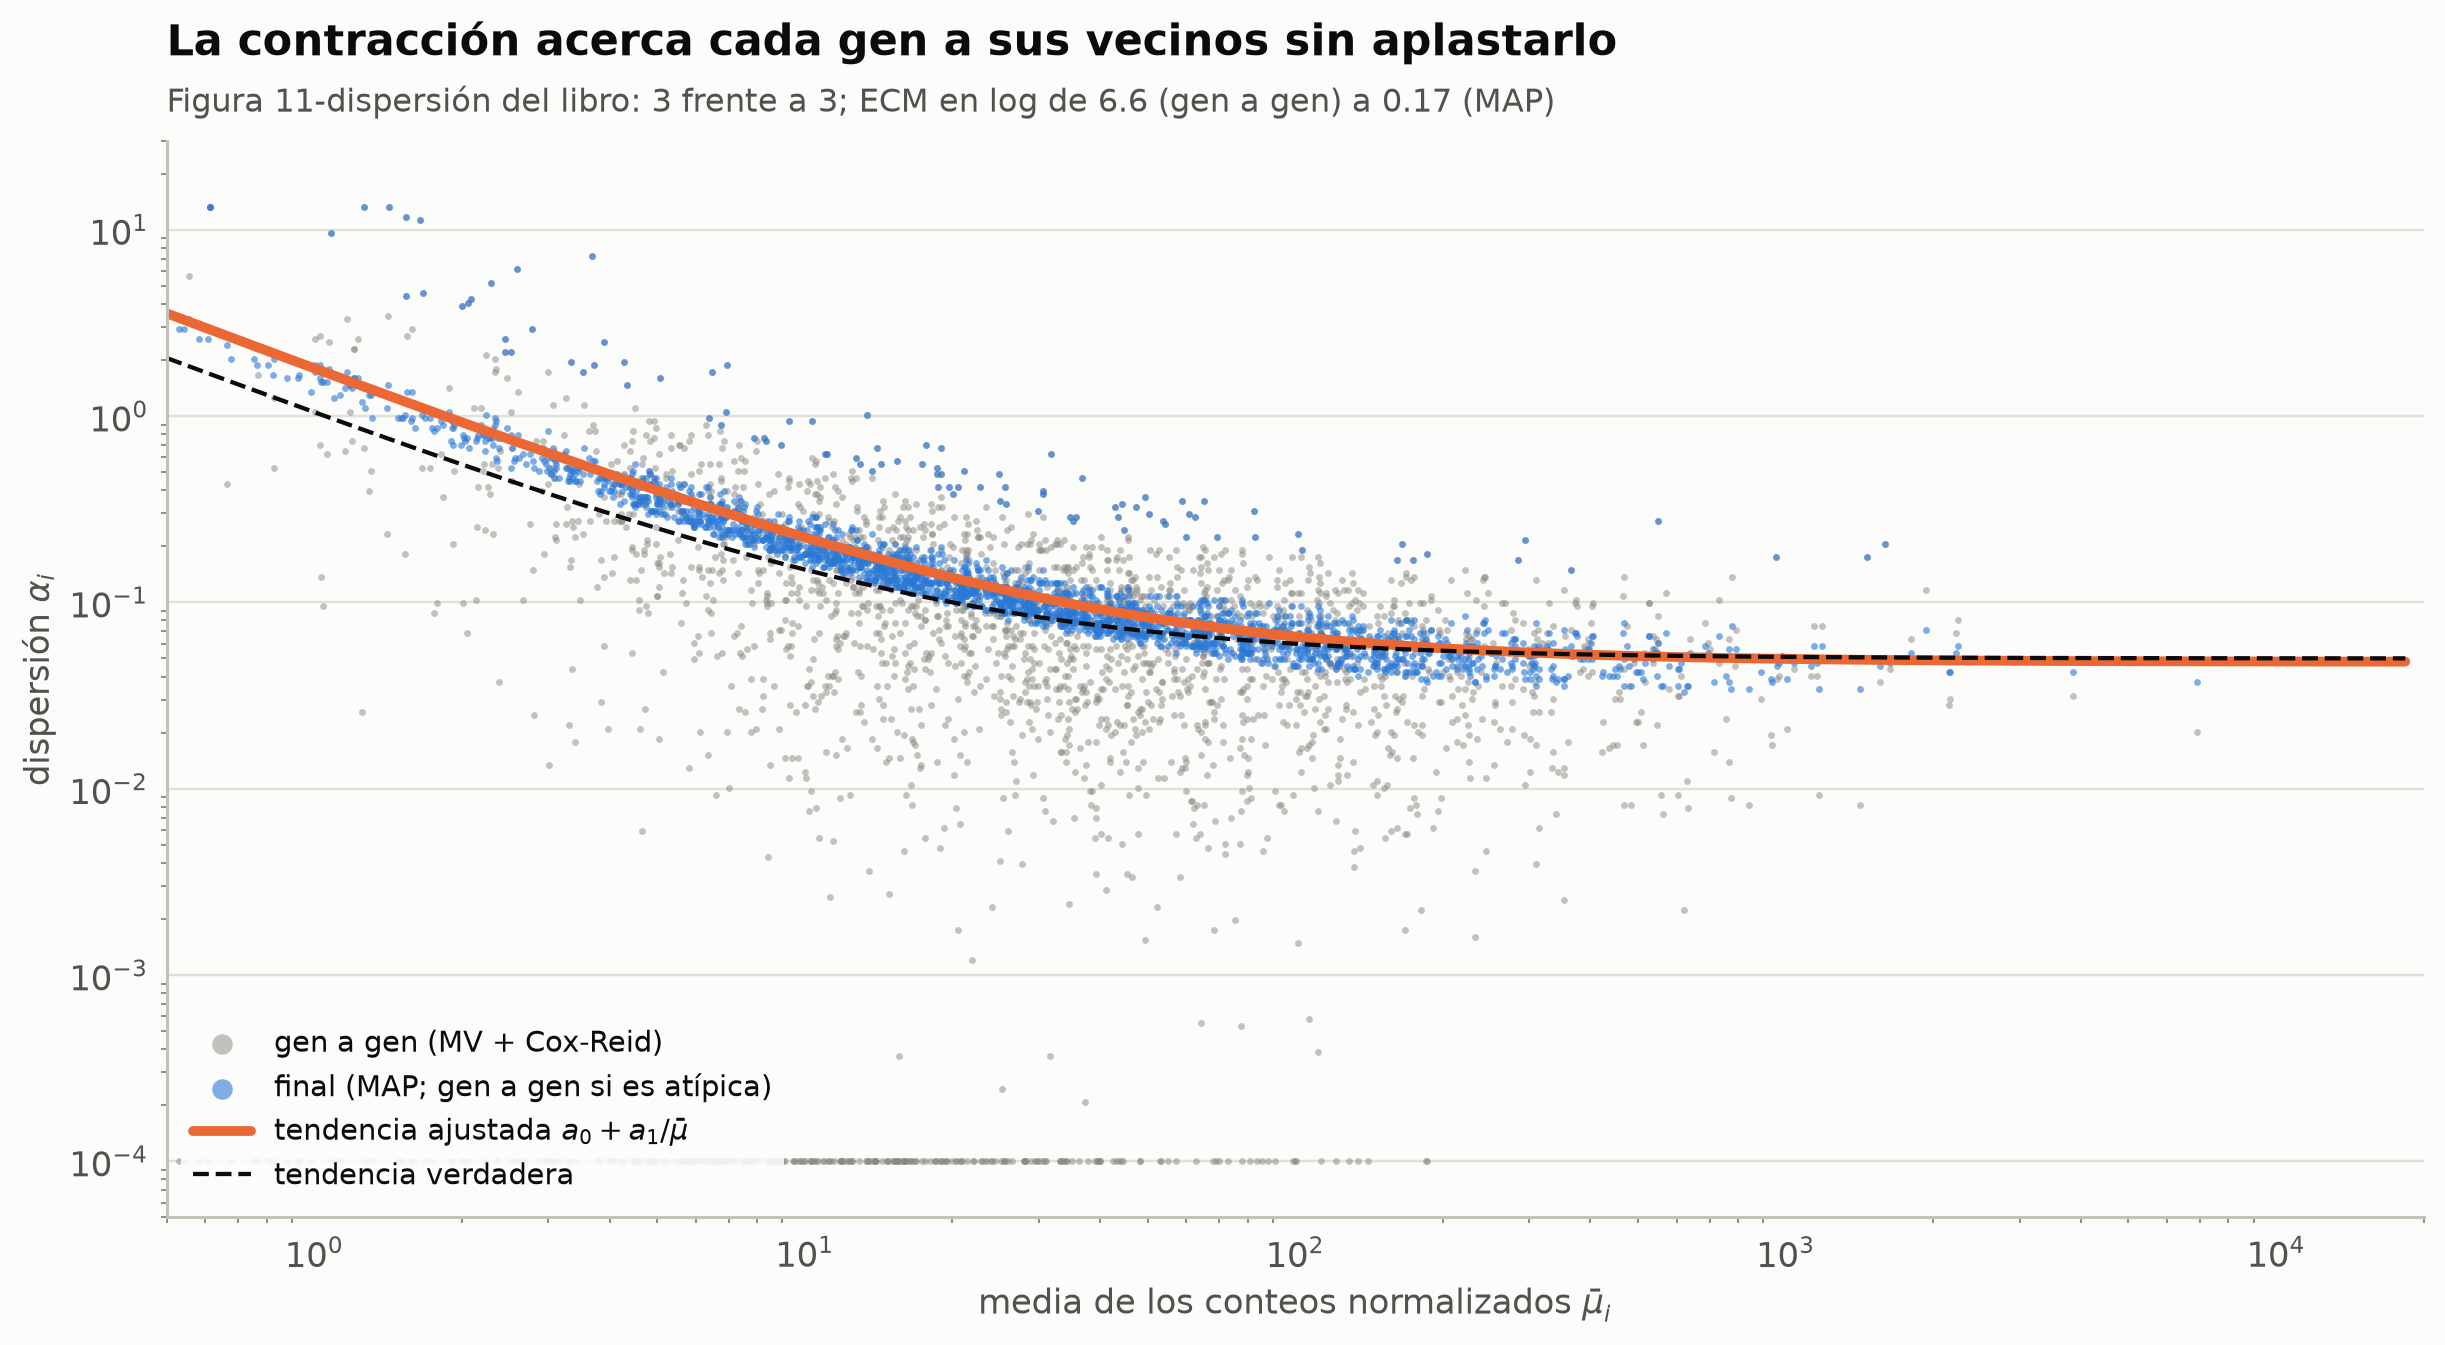

In [25]:
subd = BOOK["rng"].choice(np.where(base_b > 0.5)[0], 2500, replace=False)   # la misma submuestra del libro
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(base_b[subd], a_gw_b[subd], s=5, color=ec.MUTED, alpha=0.5, lw=0, label="gen a gen (MV + Cox-Reid)")
ax.scatter(base_b[subd], a_fin_b[subd], s=5, color=ec.BLUE, alpha=0.6, lw=0, label="final (MAP; gen a gen si es atípica)")
xs = np.exp(np.linspace(np.log(0.5), np.log(base_b.max()), 60))
ax.plot(xs, a0_b + a1_b / xs, color=ec.ORANGE, lw=3.2, label="tendencia ajustada $a_0+a_1/\\bar\\mu$")
ax.plot(xs, 0.05 + 1 / xs, color=ec.INK, lw=1.4, ls="--", label="tendencia verdadera")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(0.5, 2e4); ax.set_ylim(5e-5, 30)
ax.set_xlabel("media de los conteos normalizados $\\bar\\mu_i$"); ax.set_ylabel("dispersión $\\alpha_i$")
ax.legend(loc="lower left", frameon=True, framealpha=0.9, markerscale=3, fontsize=9.5)
ec.title(ax, "La contracción acerca cada gen a sus vecinos sin aplastarlo",
         f"Figura 11-dispersión del libro: 3 frente a 3; ECM en log de {e_gw:.1f} (gen a gen) a {e_map:.2f} (MAP)")
plt.show()

> 🔎 **Qué observamos.** Todas las cifras del libro se reproducen. Las estimaciones gen a gen (gris) son muy
> ruidosas; muchas caen al límite inferior de la búsqueda ($10^{-4}$) porque, con seis muestras, la varianza
> observada puede ser menor que la de Poisson por puro azar. La tendencia ajustada (naranja, $a_0=0{,}048$,
> $a_1=1{,}76$) sigue de cerca a la verdadera ($0{,}05$ y $1$). Las estimaciones contraídas (azul) se agrupan
> alrededor de la tendencia sin colapsar sobre ella: conservan la variación genuina entre genes y reducen el error
> cuadrático medio en escala logarítmica de 6,6 a 0,17. Los puntos azules muy por encima de la curva son los 406
> genes con dispersión atípica que conservan su estimación propia.

### Ejemplo: un gen con media 20 (ejemplo 11-disp del libro)

En la simulación, un gen con media normalizada $\bar\mu=20{,}0$ tiene una dispersión verdadera de $0{,}162$. Su
estimación gen a gen es $0{,}351$: más del doble, por el azar de tres réplicas. La tendencia en ese nivel de expresión
vale $0{,}136$, y la estimación contraída, $0{,}183$, un compromiso entre ambas mucho más cercano a la verdad. Con
$0{,}351$ el gen habría perdido potencia; con la tendencia sola, se habría ignorado que es algo más variable que sus
vecinos. La varianza previa usada fue $\hat\sigma_d^2=0{,}257$: la varianza robusta de los residuos logarítmicos
alrededor de la tendencia ($0{,}950^2=0{,}903$) menos la que se espera sólo por muestreo con cuatro grados de libertad
residuales ($\psi_1(2)=0{,}645$).

Veamos las tres curvas que se combinan: la log-verosimilitud del gen, la log-previa y su suma.

gen de ejemplo: media = 20.0; gen a gen = 0.351; tendencia = 0.136; MAP = 0.183; verdad = 0.162
                libro: media=20.0: gen a gen=0.351, tendencia=0.136, MAP=0.183, verdad=0.162
conteos crudos del gen: [28  8 22 11 17 32]


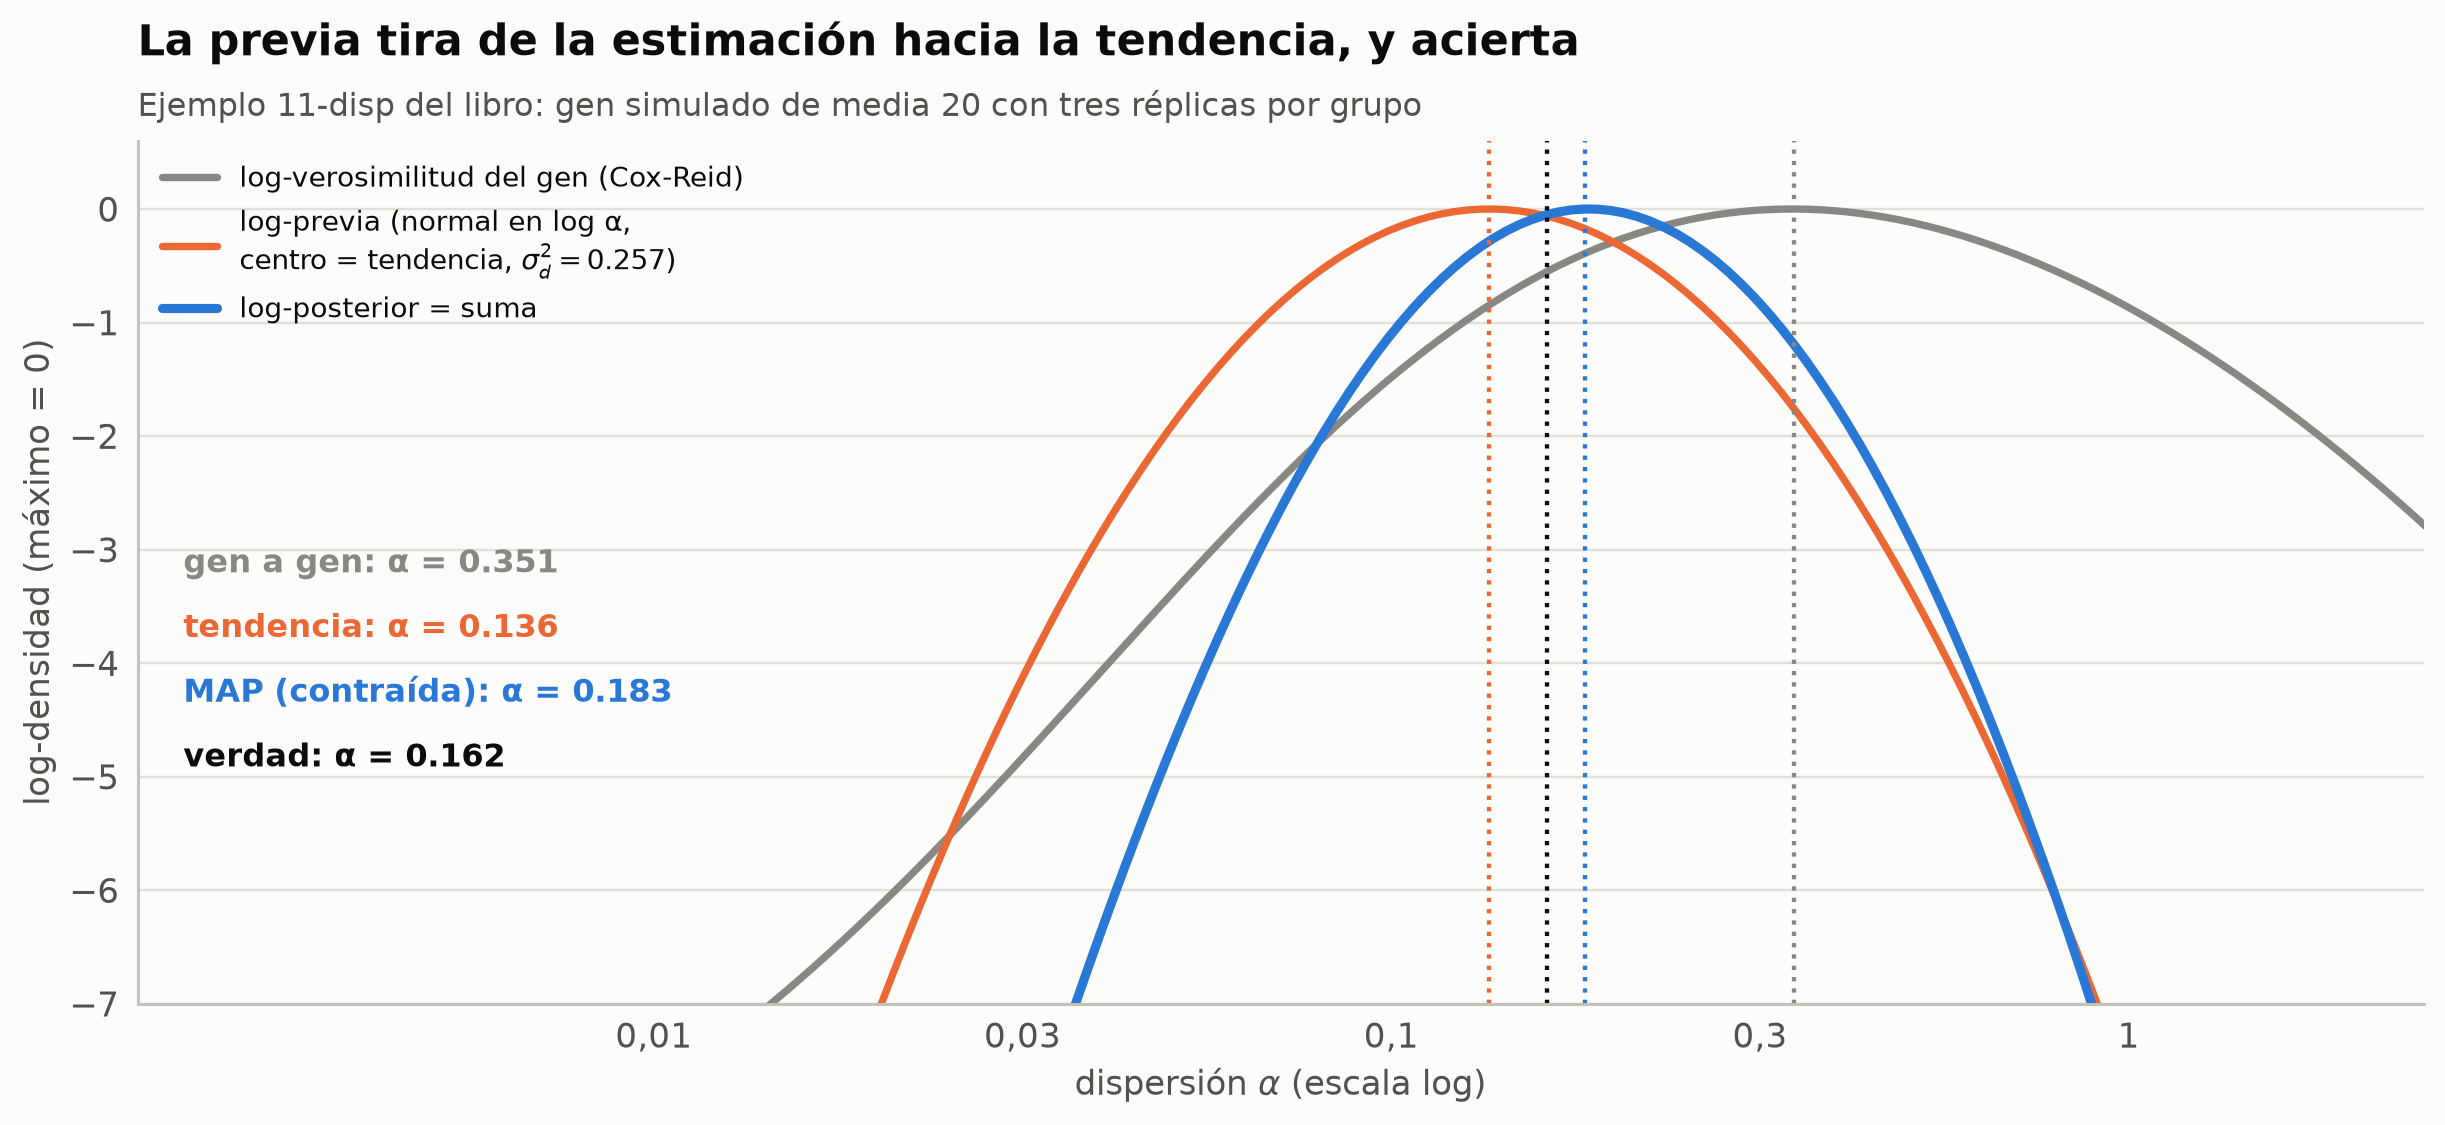

In [26]:
g20 = int(np.argmin(np.abs(base_b - 20)))
print(f"gen de ejemplo: media = {base_b[g20]:.1f}; gen a gen = {a_gw_b[g20]:.3f}; tendencia = {a_tr_b[g20]:.3f}; "
      f"MAP = {a_map_b[g20]:.3f}; verdad = {true_b[g20]:.3f}")
print("                libro: media=20.0: gen a gen=0.351, tendencia=0.136, MAP=0.183, verdad=0.162")
print(f"conteos crudos del gen: {Yb[g20]}")

lg = np.log10(GRID)
ll = LLb[g20] - LLb[g20].max()
lp = logprior_b[g20] - logprior_b[g20].max()
post = LLb[g20] + logprior_b[g20]; post -= post.max()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(lg, ll, color=ec.MUTED, lw=2.4, label="log-verosimilitud del gen (Cox-Reid)")
ax.plot(lg, lp, color=ec.ORANGE, lw=2.4, label=f"log-previa (normal en log α,\ncentro = tendencia, $\\sigma_d^2={s2p_b:.3f}$)")
ax.plot(lg, post, color=ec.BLUE, lw=3, label="log-posterior = suma")
for k_, (val, c, t) in enumerate([(a_gw_b[g20], ec.MUTED, "gen a gen"), (a_tr_b[g20], ec.ORANGE, "tendencia"),
                                  (a_map_b[g20], ec.BLUE, "MAP (contraída)"), (true_b[g20], ec.INK, "verdad")]):
    ax.axvline(np.log10(val), color=c, lw=1.4, ls=":")
    ax.text(0.02, 0.5 - 0.075 * k_, f"{t}: α = {val:.3f}", transform=ax.transAxes, ha="left",
            color=c, fontsize=10.5, fontweight="bold")
ax.set_xlim(-2.7, 0.4); ax.set_ylim(-7, 0.6)
ax.set_xticks([-2, -1.5, -1, -0.5, 0], ["0,01", "0,03", "0,1", "0,3", "1"])
ax.set_xlabel("dispersión $\\alpha$ (escala log)"); ax.set_ylabel("log-densidad (máximo = 0)")
ax.legend(loc="upper left", frameon=False, fontsize=9)
ec.title(ax, "La previa tira de la estimación hacia la tendencia, y acierta",
         "Ejemplo 11-disp del libro: gen simulado de media 20 con tres réplicas por grupo")
plt.show()

> 🔎 **Qué observamos.** La verosimilitud del gen (gris) es **muy plana**: con seis conteos, valores de $\alpha$
> entre 0,1 y 1 son casi igual de compatibles con los datos. La previa (naranja), más estrecha, está centrada en la
> tendencia. La suma (azul) tiene su máximo entre ambas, en $0{,}183$, cerca de la verdad ($0{,}162$). Si el gen
> tuviera 30 réplicas, la curva gris sería mucho más aguda y la previa apenas movería el máximo: así se regula sola
> la contracción.

> ✅ **Compruebe su comprensión.** ¿Qué pasaría con $\hat\alpha^{\mathrm{MAP}}$ si $\sigma_d^2$ fuera muy grande
> (por ejemplo 10)? ¿Y si fuera casi cero? *(Con $\sigma_d^2$ grande la previa es plana y el MAP se acerca a la
> estimación gen a gen, 0,351; con $\sigma_d^2\to0$ el MAP colapsa sobre la tendencia, 0,136.)*

### 8.2 Las dispersiones reales de *airway*

Ahora lo mismo con las 8 muestras reales y el diseño pareado `~ cell + dex`. El estimador es el mismo (máxima
verosimilitud con Cox-Reid), con dos diferencias:

* Las medias ajustadas $\hat\mu_{ij}$ salen del **GLM de 5 coeficientes** de la sección 7 (con una dispersión
  provisional de 0,05, como el arranque aproximado de DESeq2), y el ajuste de Cox-Reid usa el determinante de la
  matriz $5\times5$ $X^\top WX$ de cada gen.
* Quedan $\nu=8-5=3$ grados de libertad residuales, así que la varianza de muestreo esperada es
  $\psi_1(3/2)=0{,}935$ en lugar de $0{,}645$: con tres grados de libertad, una varianza se estima todavía peor.

Filtramos los genes con menos de 10 lecturas en total (no aportan información sobre la dispersión).

> 🤔 **Antes de ejecutar, prediga…** ¿Esperaría una asíntota $a_0$ mayor o menor que la del libro (0,05)? Piense en
> el $\alpha$ común que medimos en la sección 6.2.

In [27]:
t0 = time.time()
keep8 = K8.sum(1) >= 10
Y8 = K8[keep8]
sym8, type8 = SYMBOL[keep8], GTYPE[keep8]
base8 = (Y8 / s8).mean(1)
_, mu8, _ = irls_nb(Y8, X, s8, np.full(len(Y8), 0.05))        # medias ajustadas con una dispersión provisional

GRID8 = np.exp(np.linspace(np.log(1e-4), np.log(20), 150))
LL8 = np.empty((len(Y8), len(GRID8)))
for k_, a in enumerate(GRID8):
    W = mu8 / (1 + a * mu8)
    XtWX = np.einsum("jr,gj,js->grs", X, W, X)
    LL8[:, k_] = nb_loglik(Y8, mu8, a).sum(1) - 0.5 * np.linalg.slogdet(XtWX)[1]   # Cox-Reid
a_gw8 = GRID8[LL8.argmax(1)]
GRID = GRID8                                                   # fit_trend usa el borde superior de la rejilla
a0_8, a1_8, use8 = fit_trend(base8, a_gw8)
a_tr8 = a0_8 + a1_8 / base8
res8 = np.log(a_gw8[use8]) - np.log(a_tr8[use8])
sd_rob8 = stats.median_abs_deviation(res8, scale="normal")
samp8 = special.polygamma(1, (8 - 5) / 2)
s2p8 = max(sd_rob8 ** 2 - samp8, 0.25)
logprior8 = -0.5 * (np.log(GRID8)[None, :] - np.log(a_tr8)[:, None]) ** 2 / s2p8
a_map8 = GRID8[(LL8 + logprior8).argmax(1)]
outl8 = np.log(a_gw8) > np.log(a_tr8) + 2 * np.sqrt(s2p8)
a_fin8 = np.where(outl8, a_gw8, a_map8)
print(f"{len(Y8):,} genes con ≥ 10 lecturas · {time.time() - t0:.1f} s".replace(",", " "))
print(f"tendencia: a0 = {a0_8:.4f} (CV biológico asintótico {np.sqrt(a0_8):.0%}), a1 = {a1_8:.2f}")
print(f"sd robusta de residuos = {sd_rob8:.3f}; var. de muestreo ψ1(3/2) = {samp8:.3f}; var. previa = {s2p8:.3f}")
print(f"gen a gen en el límite inferior 1e-4: {np.mean(a_gw8 <= GRID8[0]):.0%};  atípicos conservados: {outl8.sum()}")

26 564 genes con ≥ 10 lecturas · 2.6 s
tendencia: a0 = 0.0132 (CV biológico asintótico 11%), a1 = 2.43
sd robusta de residuos = 1.195; var. de muestreo ψ1(3/2) = 0.935; var. previa = 0.494
gen a gen en el límite inferior 1e-4: 29%;  atípicos conservados: 685


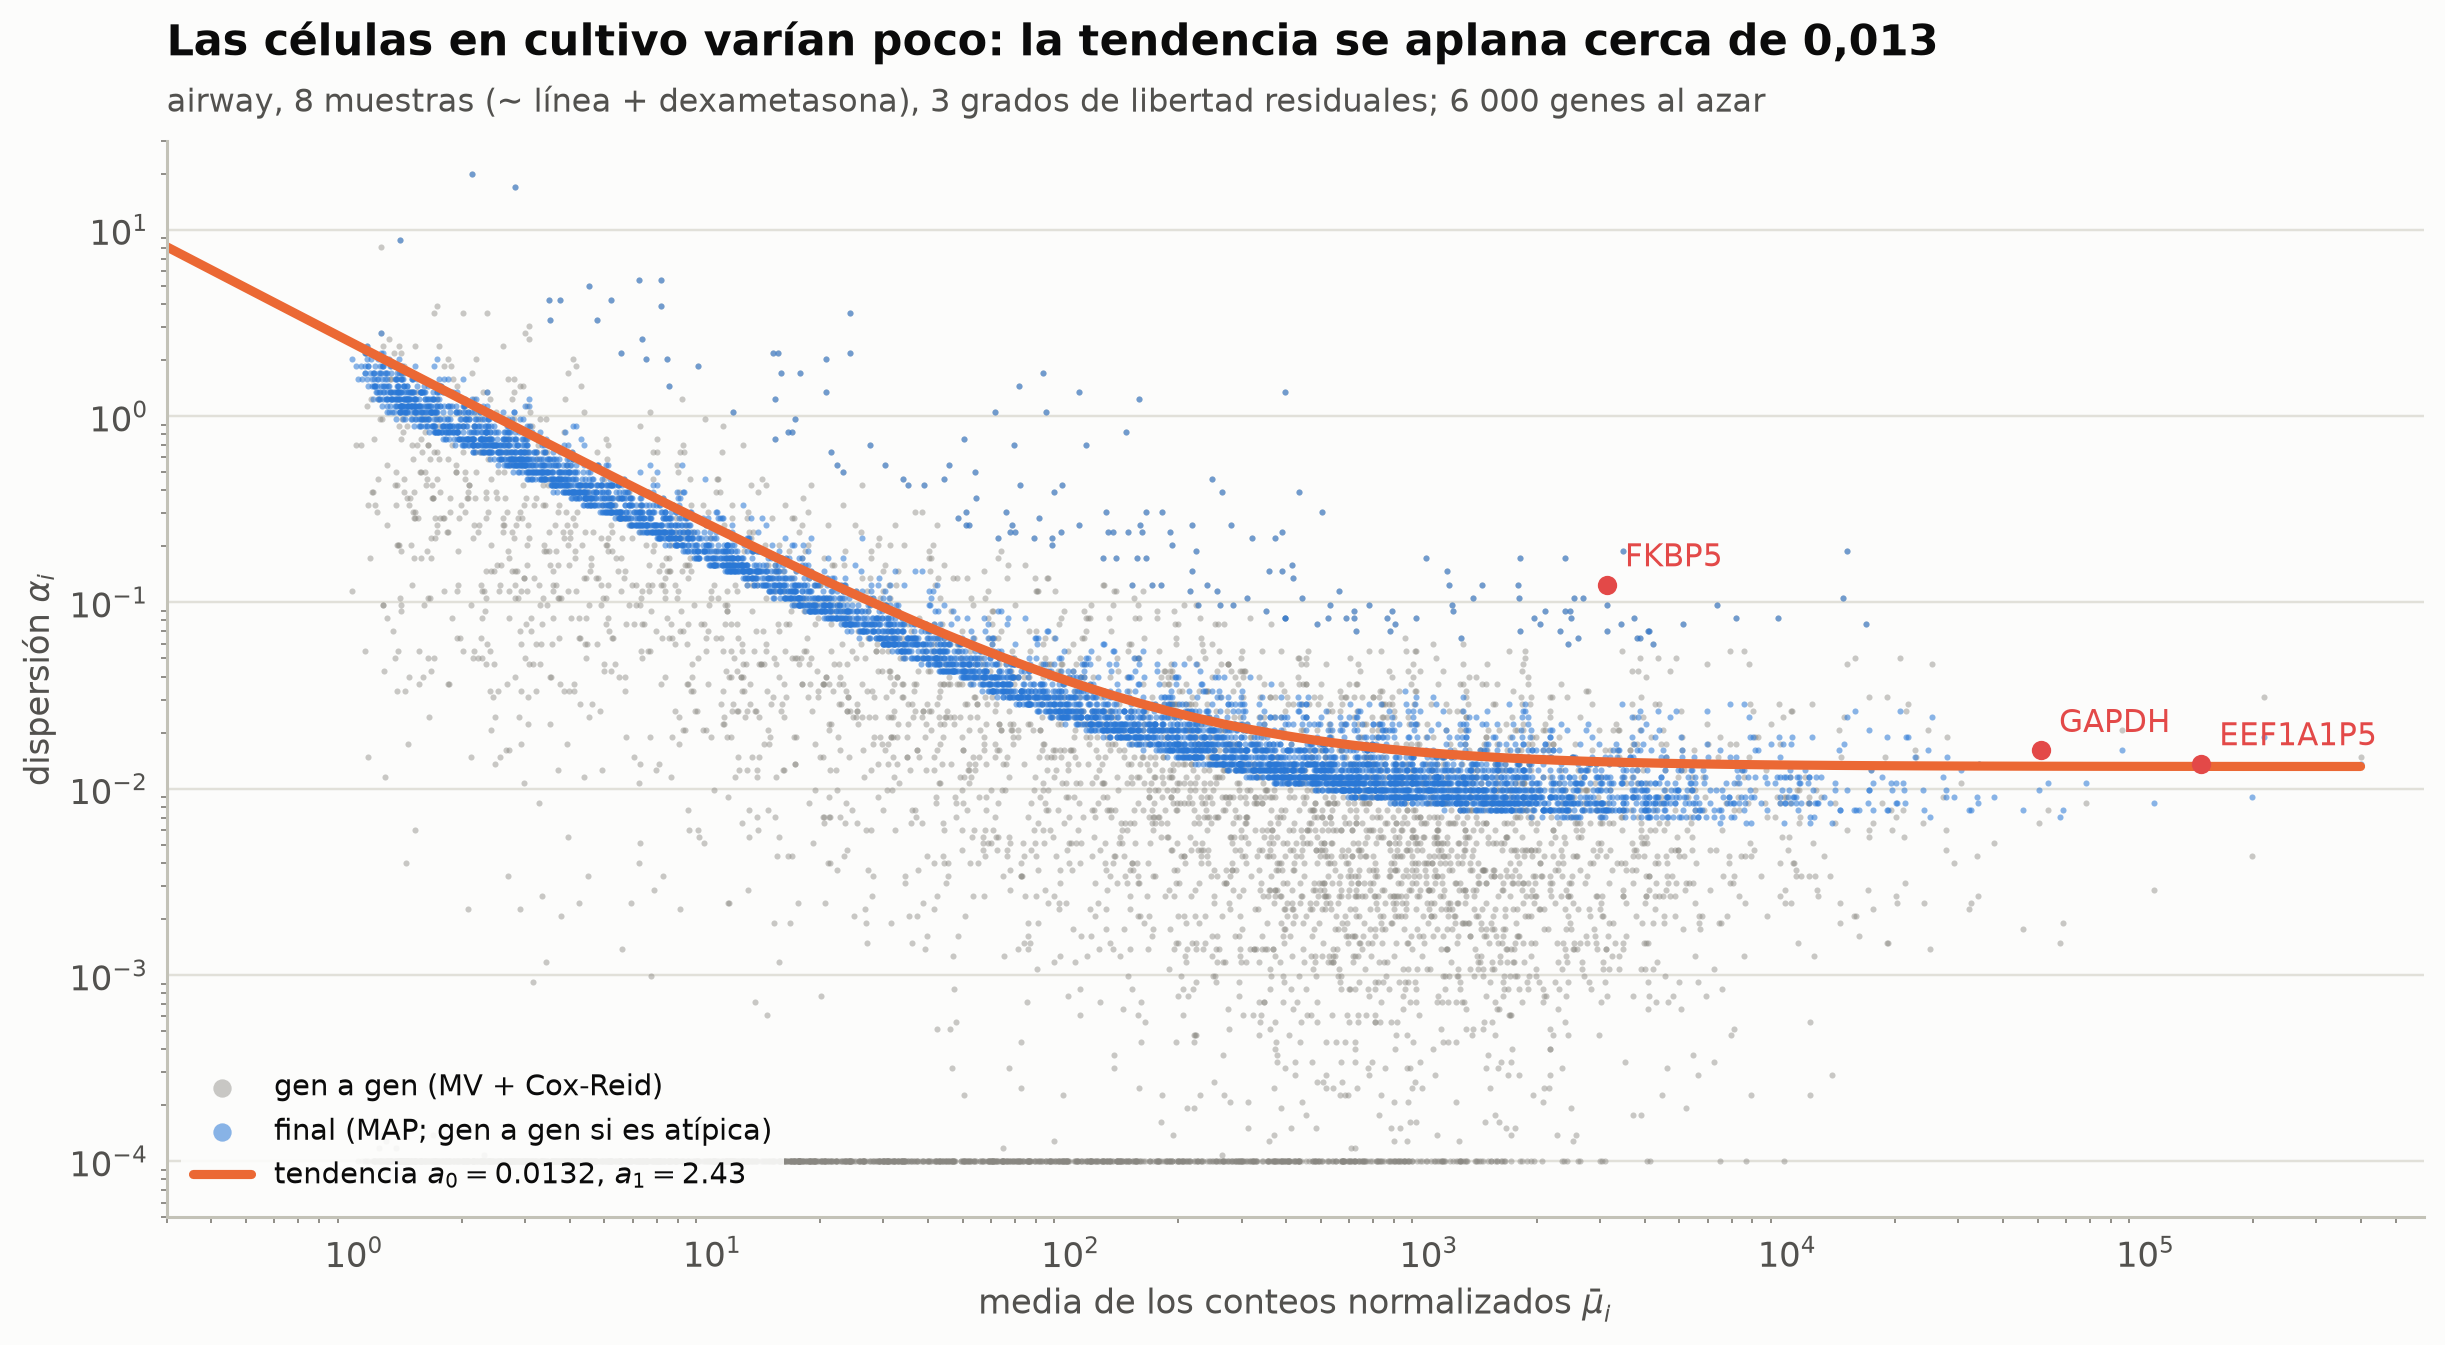

In [28]:
fig, ax = plt.subplots(figsize=(11, 6))
rs = np.random.default_rng(3).choice(len(Y8), 6000, replace=False)
ax.scatter(base8[rs], a_gw8[rs], s=4, color=ec.MUTED, alpha=0.45, lw=0, label="gen a gen (MV + Cox-Reid)", rasterized=True)
ax.scatter(base8[rs], a_fin8[rs], s=4, color=ec.BLUE, alpha=0.55, lw=0, label="final (MAP; gen a gen si es atípica)", rasterized=True)
xs8 = np.logspace(np.log10(0.3), np.log10(base8.max()), 80)
ax.plot(xs8, a0_8 + a1_8 / xs8, color=ec.ORANGE, lw=3, label=f"tendencia $a_0={a0_8:.4f}$, $a_1={a1_8:.2f}$")
for g in ["FKBP5", "GAPDH", "EEF1A1P5"]:
    i = np.where(sym8 == g)[0]
    if len(i):
        i = i[0]
        ax.scatter(base8[i], a_fin8[i], s=40, color=ec.RED, zorder=4)
        ax.annotate(g, (base8[i], a_fin8[i]), xytext=(6, 6), textcoords="offset points", fontsize=10, color=ec.RED)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(5e-5, 30); ax.set_xlim(0.3, base8.max() * 1.5)
ax.set_xlabel("media de los conteos normalizados $\\bar\\mu_i$"); ax.set_ylabel("dispersión $\\alpha_i$")
ax.legend(loc="lower left", frameon=True, framealpha=0.9, markerscale=3, fontsize=9.5)
ec.title(ax, "Las células en cultivo varían poco: la tendencia se aplana cerca de 0,013",
         "airway, 8 muestras (~ línea + dexametasona), 3 grados de libertad residuales; 6 000 genes al azar")
plt.show()

> 🔎 **Qué observamos.** El dibujo tiene la misma forma que el del libro, pero la asíntota es **cuatro veces menor**:
> $a_0\approx0{,}013$, un CV biológico de ~11 % entre donantes, coherente con el $\alpha$ común de la sección 6.2.
> El término $a_1/\bar\mu$ es mayor ($\approx2{,}4$): los genes poco expresados son más variables de lo que predice
> Poisson, en parte por el redondeo de la cobertura de recount3 y por lecturas ambiguas. Casi un 30 % de las
> estimaciones gen a gen caen al límite inferior, como anunciaba el libro: con 3 grados de libertad, muchas
> varianzas observadas salen por debajo de la de Poisson por azar. La varianza previa (~0,49) es mayor que la del
> libro (0,257): entre los genes reales hay más heterogeneidad genuina de dispersión que en la simulación. En la
> Lección 11.3 el mismo procedimiento sobre los mismos datos da cifras algo distintas ($a_0\approx0{,}009$, varianza
> previa $\approx0{,}75$) porque cambia la configuración: allí la rejilla de la dispersión baja hasta $10^{-8}$ (aquí,
> como en el libro, se detiene en $10^{-4}$) y las medias iniciales se estiman de otro modo. Con 3 grados de libertad
> residuales, esos detalles mueven la tendencia y la varianza previa.

### 8.3 Animación: la contracción en movimiento

Cada punto parte de su estimación gen a gen y viaja hasta su valor final. Observe quién se mueve mucho (genes con
pocas lecturas, cuya verosimilitud es plana) y quién casi no se mueve (atípicos que conservan su valor).

![Contracción de dispersiones en airway: cada gen viaja de su estimación gen a gen (gris) a su estimación a posteriori (azul), atraído por la tendencia naranja; los atípicos se quedan donde estaban](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-11-rnaseq/11.2_contraccion.gif)

*Contracción de dispersiones en airway: cada gen viaja de su estimación gen a gen (gris) a su estimación a posteriori (azul), atraído por la tendencia naranja; los atípicos se quedan donde estaban*

In [29]:
import matplotlib as mpl
ra = np.random.default_rng(7).choice(np.where(base8 > 0.5)[0], 2500, replace=False)
x_a, y0_a, y1_a = np.log10(base8[ra]), np.log10(a_gw8[ra]), np.log10(a_fin8[ra])
tt = np.concatenate([np.zeros(6), (1 - np.cos(np.linspace(0, np.pi, 30))) / 2, np.ones(8)])   # pausa-viaje-pausa
fig, ax = plt.subplots(figsize=(10.5, 5.6))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.88))
ax.plot(np.log10(xs8), np.log10(a0_8 + a1_8 / xs8), color=ec.ORANGE, lw=3, zorder=3)
sc = ax.scatter(x_a, y0_a, s=6, c=[ec.MUTED] * len(ra), lw=0, alpha=0.7)
ax.set_xlim(np.log10(0.5), np.log10(base8.max() * 1.5)); ax.set_ylim(-4.2, 1.4)
ax.set_xticks(range(0, 6), ["1", "10", "100", "1 000", "10 000", "100 000"])
ax.set_yticks(range(-4, 2), ["$10^{-4}$", "0,001", "0,01", "0,1", "1", "10"])
ax.set_xlabel("media de los conteos normalizados"); ax.set_ylabel("dispersión $\\alpha_i$")
lab = ax.text(0.98, 0.95, "", transform=ax.transAxes, ha="right", va="top", fontsize=13, fontweight="bold", color=ec.INK)
fig.text(0.01, 0.985, "Bayes empírico: cada gen se acerca a sus vecinos", fontsize=15, fontweight="bold",
         color=ec.INK, va="top")
fig.text(0.01, 0.935, "2 500 genes reales de airway; naranja: tendencia $a_0+a_1/\\bar\\mu$; los atípicos (> 2 sd) "
         "conservan su estimación", fontsize=10.5, color=ec.INK_2, va="top")
col0, col1 = np.array(mpl.colors.to_rgba(ec.MUTED)), np.array(mpl.colors.to_rgba(ec.BLUE))

def update(f):
    t = tt[f]
    sc.set_offsets(np.column_stack([x_a, y0_a + t * (y1_a - y0_a)]))
    sc.set_facecolor((1 - t) * col0 + t * col1)
    lab.set_text("gen a gen" if t == 0 else ("a posteriori (MAP)" if t == 1 else "contrayendo…"))
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(tt), interval=110, name="11.2_contraccion")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En los primeros cuadros, la nube gris es ancha y tiene un «suelo» en $10^{-4}$. Durante el
> viaje, los genes de pocas lecturas (izquierda) recorren grandes distancias hacia la curva naranja, y los del suelo
> suben: sus varianzas «menores que Poisson» eran azar. A la derecha los desplazamientos son más cortos: con muchas
> lecturas la verosimilitud es más aguda. Los puntos que quedan muy por encima de la tendencia no se mueven: son los
> atípicos que conservan su valor.

### 🎛️ Interactivo: explore las dispersiones reales gen a gen

Pase el cursor sobre cualquier gen para ver su nombre, su tipo, su media y sus tres dispersiones. Los genes con
dispersión atípica están en rojo. Haga zoom sobre la esquina superior derecha: ¿qué clase de genes son?

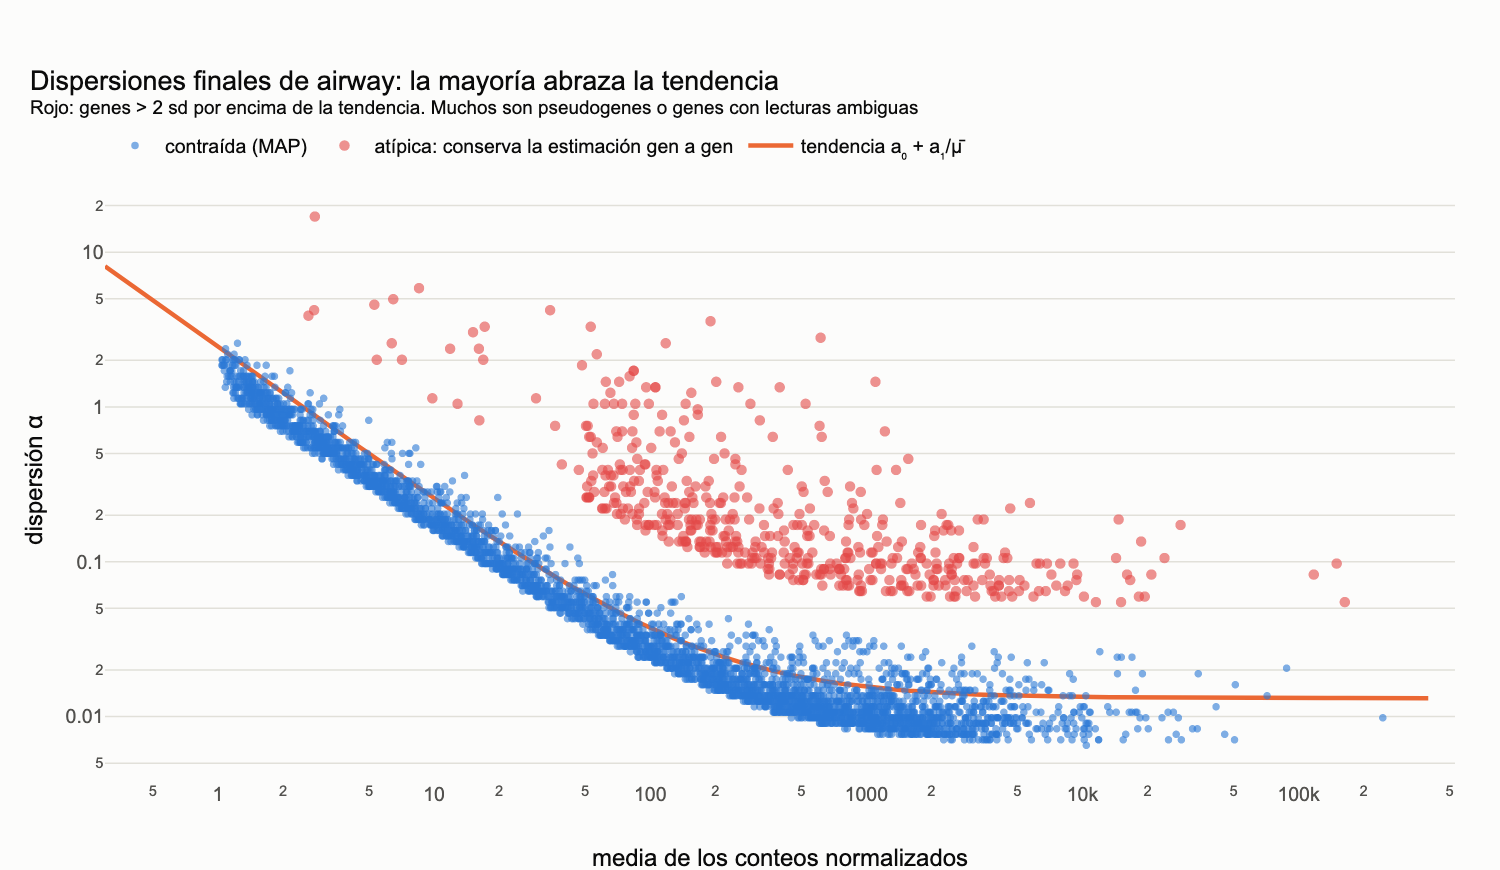

In [30]:
r_i = np.random.default_rng(11).choice(np.where(base8 > 1)[0], 4000, replace=False)
r_i = np.union1d(r_i, np.where(outl8 & (base8 > 50))[0])          # todos los atípicos bien expresados
df_d = pd.DataFrame(dict(gen=sym8[r_i], tipo=type8[r_i], media=base8[r_i], gw=a_gw8[r_i], tr=a_tr8[r_i],
                         amap=a_map8[r_i], final=a_fin8[r_i], atipico=outl8[r_i]))
fig = go.Figure()
for flag, name, col in [(False, "contraída (MAP)", ec.BLUE), (True, "atípica: conserva la estimación gen a gen", ec.RED)]:
    d = df_d[df_d.atipico == flag]
    fig.add_trace(go.Scattergl(
        x=d.media, y=d.final, mode="markers", name=name, marker=dict(size=5 if not flag else 7, color=col, opacity=0.6),
        customdata=np.column_stack([d.gen, d.tipo, d.gw, d.tr, d.amap, np.sqrt(d.final) * 100]),
        hovertemplate=("<b>%{customdata[0]}</b> (%{customdata[1]})<br>media normalizada = %{x:.1f}<br>"
                       "α gen a gen = %{customdata[2]:.4f}<br>α tendencia = %{customdata[3]:.4f}<br>"
                       "α MAP = %{customdata[4]:.4f}<br><b>α final = %{y:.4f}</b> → CV biológico ≈ %{customdata[5]:.0f} %"
                       "<extra></extra>")))
fig.add_trace(go.Scatter(x=xs8, y=a0_8 + a1_8 / xs8, mode="lines", line=dict(color=ec.ORANGE, width=3),
                         name="tendencia a₀ + a₁/μ̄", hoverinfo="skip"))
fig.update_layout(
    title="Dispersiones finales de airway: la mayoría abraza la tendencia<br><sup>Rojo: genes > 2 sd por encima de la "
          "tendencia. Muchos son pseudogenes o genes con lecturas ambiguas</sup>",
    xaxis=dict(type="log", title="media de los conteos normalizados"), yaxis=dict(type="log", title="dispersión α"),
    height=580, margin=dict(t=120, l=70, r=30, b=60), legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

In [31]:
# ¿Quiénes son los atípicos bien expresados? Tipo de gen de los 40 con mayor exceso sobre la tendencia (media > 50)
exc = np.where(base8 > 50, np.log(a_gw8) - np.log(a_tr8), -np.inf)
top_o = np.argsort(-exc)[:40]
print("tipo de gen de los 40 genes con mayor exceso de dispersión (media > 50):")
print(pd.Series(type8[top_o]).value_counts().to_string())
print("\nfracción de pseudogenes entre todos los genes con media > 50:",
      f"{np.mean(np.char.find(type8[base8 > 50].astype(str), 'pseudogene') >= 0):.0%}")
pd.DataFrame(dict(gen=sym8[top_o[:10]], tipo=type8[top_o[:10]], media=base8[top_o[:10]].round(0),
                  alfa_gen_a_gen=a_gw8[top_o[:10]].round(3), tendencia=a_tr8[top_o[:10]].round(4)))

tipo de gen de los 40 genes con mayor exceso de dispersión (media > 50):
processed_pseudogene    32
protein_coding           7
lincRNA                  1

fracción de pseudogenes entre todos los genes con media > 50: 9%


,gen,tipo,media,alfa_gen_a_gen,tendencia
0,EEF1A1P29,processed_pseudogene,614.0,2.800,0.0171
1,FTH1P1,processed_pseudogene,190.0,3.580,0.0259
2,EEF1A1P14,processed_pseudogene,1102.0,1.454,0.0154
3,RPL21P7,processed_pseudogene,118.0,2.580,0.0338
4,FTH1P15,processed_pseudogene,397.0,1.340,0.0193
5,MTRNR2L8,protein_coding,256.0,1.340,0.0226
6,EEF1A1P22,processed_pseudogene,523.0,1.048,0.0178
7,MTND4P12,processed_pseudogene,202.0,1.454,0.0252
8,RP11-1094M14.1,processed_pseudogene,53.0,3.299,0.0590
9,EEF1A1P8,processed_pseudogene,291.0,1.048,0.0215


> 🔎 **Qué observamos.** Entre los genes con dispersión más anómala dominan los **pseudogenes procesados** de genes
> muy expresados (*EEF1A1P…*, *FTH1P…*, *RPL…P…*, *MTND…P…*), muy por encima de su peso en el conjunto de genes. No es
> biología: un pseudogén procesado es una copia casi idéntica del ARNm de su gen parental, y las lecturas que caen en
> las zonas idénticas se reparten entre ambos de forma variable de una muestra a otra. Esa variación **técnica**
> infla la dispersión. Es una buena noticia que el método los marque como atípicos en lugar de contraerlos: así no
> producirán falsos positivos. Es también un recordatorio de la Lección 11.1: los cuantificadores que reparten lecturas
> ambiguas con un modelo (Salmon, RSEM) sufren menos este problema que el conteo de cobertura.

> ⚠️ **Conteos normalizados: para mirar, no para modelar.** Los conteos divididos por $\hat s_j$ son útiles para
> gráficos y tablas, pero **nunca** deben entrar en DESeq2 o edgeR, que esperan conteos **crudos** y aplican la
> normalización internamente (como desplazamiento). Para análisis exploratorios (agrupamiento, componentes
> principales) conviene además **estabilizar la varianza**, porque en la escala logarítmica simple los genes poco
> expresados dominan la variabilidad.

## 9. Conteos normalizados para mirar: VST y control de calidad

### 9.1 La transformación estabilizadora de varianza

Buscamos una función $g$ tal que $g(K)$ tenga **la misma varianza** para todos los genes, sea cual sea su media. El
método delta dice que $\operatorname{Var}[g(K)]\approx g'(\mu)^2\operatorname{Var}[K]$; para que sea constante hace
falta $g'(\mu)\propto1/\sqrt{v(\mu)}$, es decir,

$$
g(q)=\int^{q}\frac{d\mu}{\sqrt{v(\mu)}},\qquad v(\mu)=\mu+\alpha_{\mathrm{tr}}(\mu)\,\mu^2=(1+a_1)\mu+a_0\mu^2 .
$$

Con la tendencia paramétrica de la sección 8 la integral tiene forma cerrada, y es la que usa DESeq2
(`varianceStabilizingTransformation` con ajuste paramétrico):

$$
\boxed{\;\mathrm{VST}(q)=\log_2\!\frac{1+a_1+2a_0q+2\sqrt{a_0q\,(1+a_1+a_0q)}}{4a_0}\;}
$$

| Símbolo | Significado |
|---|---|
| $q$ | conteo normalizado $K_{ij}/\hat s_j$ |
| $a_0,\ a_1$ | parámetros de la tendencia de dispersión (sección 8.2) |
| $v(\mu)$ | varianza esperada de un conteo con media $\mu$ |

Para $q$ grande, $\mathrm{VST}(q)\approx\log_2 q$: se comporta como un logaritmo. Para $q$ pequeño se aplana y evita
que el ruido de Poisson de los genes de pocas lecturas domine. Usamos la tendencia estimada con las 8 muestras del
diseño `~ cell + dex`: si la estimáramos con las 16 muestras ignorando los tratamientos (el modo *blind* de DESeq2),
los efectos del fármaco inflarían la dispersión.

Comparemos la desviación estándar entre los cuatro donantes sin tratar (réplicas) en función de la media, con
$\log_2(q+1)$ y con la VST.

VST(0) = 6.03;  VST(1000) = 10.14 frente a log2(1000) = 9.97


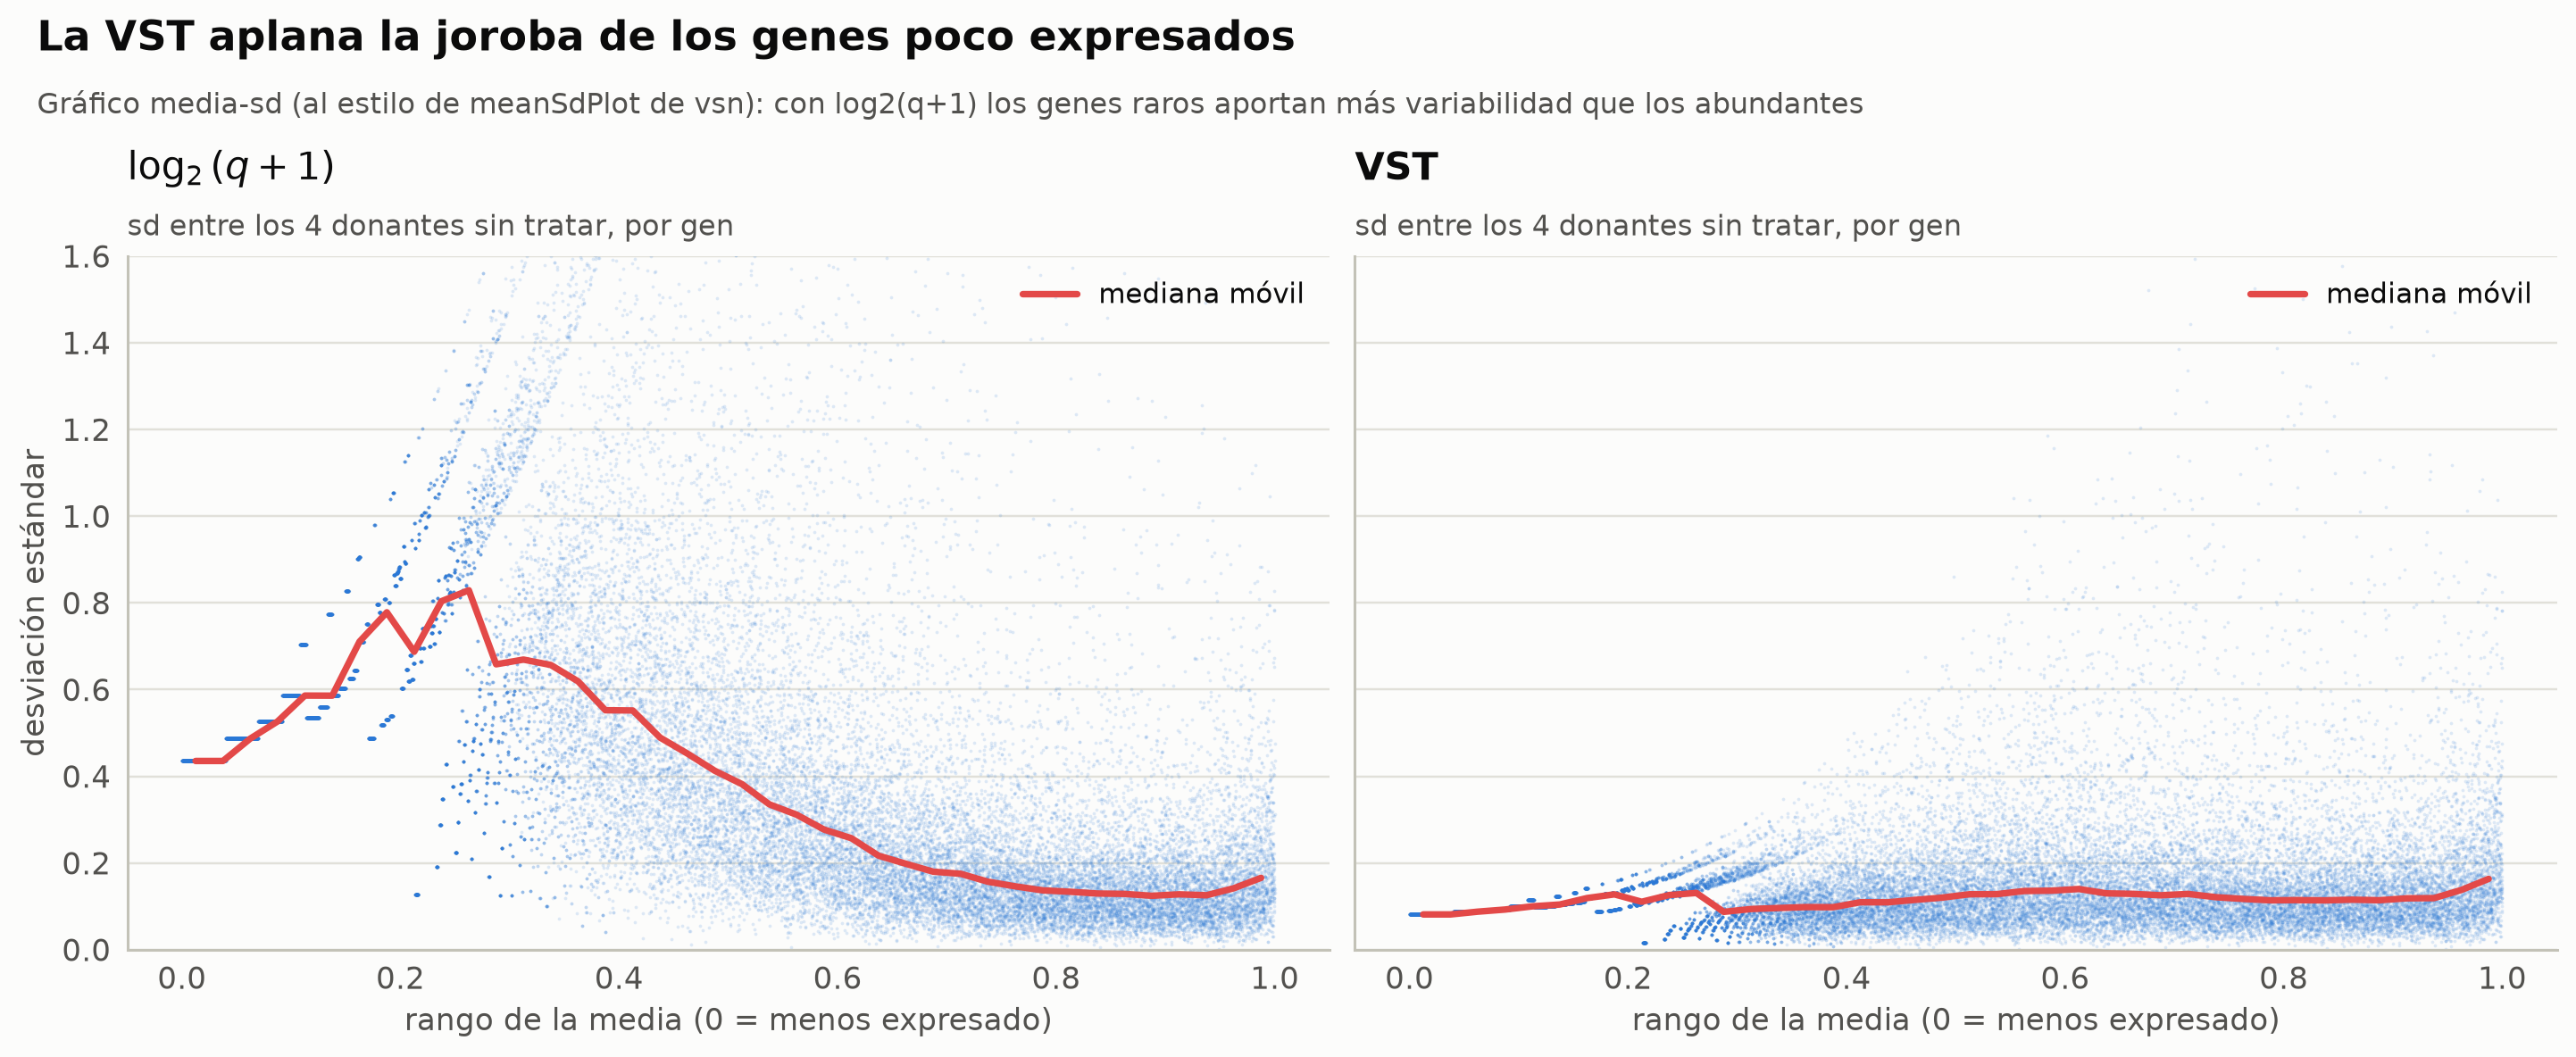

In [32]:
def vst(q, a0=a0_8, a1=a1_8):
    """Transformación estabilizadora de varianza para la tendencia a0 + a1/μ (forma cerrada de DESeq2)."""
    return np.log2((1 + a1 + 2 * a0 * q + 2 * np.sqrt(a0 * q * (1 + a1 + a0 * q))) / (4 * a0))

Qn = K_all / s16                                         # conteos normalizados de las 16 muestras
V16 = vst(Qn)
L16 = np.log2(Qn + 1)
print(f"VST(0) = {vst(0.0):.2f};  VST(1000) = {vst(1000.0):.2f} frente a log2(1000) = {np.log2(1000):.2f}")

expr = Qn[:, is_untr].mean(1) > 0
rank = stats.rankdata(Qn[expr][:, is_untr].mean(1), method="ordinal") / expr.sum()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, M_, name in [(axes[0], L16, "$\\log_2(q+1)$"), (axes[1], V16, "VST")]:
    sd = M_[expr][:, is_untr].std(1, ddof=1)
    ax.scatter(rank, sd, s=1.5, color=ec.BLUE, alpha=0.15, lw=0, rasterized=True)
    bins_r = np.linspace(0, 1, 41)
    med = [np.median(sd[(rank > a) & (rank <= b)]) for a, b in zip(bins_r[:-1], bins_r[1:])]
    ax.plot((bins_r[:-1] + bins_r[1:]) / 2, med, color=ec.RED, lw=2.4, label="mediana móvil")
    ax.set_xlabel("rango de la media (0 = menos expresado)"); ax.set_ylim(0, 1.6)
    ax.legend(loc="upper right", frameon=False)
    ec.title(ax, name, "sd entre los 4 donantes sin tratar, por gen")
axes[0].set_ylabel("desviación estándar")
ec.fig_title(fig, "La VST aplana la joroba de los genes poco expresados",
             "Gráfico media-sd (al estilo de meanSdPlot de vsn): con log2(q+1) los genes raros aportan más variabilidad que los abundantes")
plt.show()

> 🔎 **Qué observamos.** Con $\log_2(q+1)$ (izquierda) la desviación estándar forma una **joroba** en los genes de
> baja expresión: el ruido de Poisson, amplificado por el logaritmo, hace que esos genes parezcan los más variables.
> En un PCA dominarían el análisis sin tener nada interesante que decir. Con la VST (derecha) la curva queda mucho
> más plana. Ahora sí podemos comparar muestras con distancias euclídeas.

### 9.2 Control de calidad de las 16 muestras

Antes de cualquier prueba estadística hay que **mirar** los datos. Dos herramientas estándar, ambas sobre la VST:

* **Distancias entre muestras**: la distancia euclídea entre los vectores VST de cada par de muestras, dibujada como
  mapa de calor.
* **PCA** con los 500 genes de mayor varianza (el comportamiento por defecto de `plotPCA` de DESeq2).

> 🤔 **Antes de ejecutar, prediga…** Hay dos factores: línea celular (4 donantes) y tratamiento (4 niveles). Si la
> dexametasona es el efecto más fuerte, ¿cuántos grupos esperaría ver a lo largo del primer componente?

varianza explicada por PC1–PC4: [39.9 24.8 16.2 10.4] %


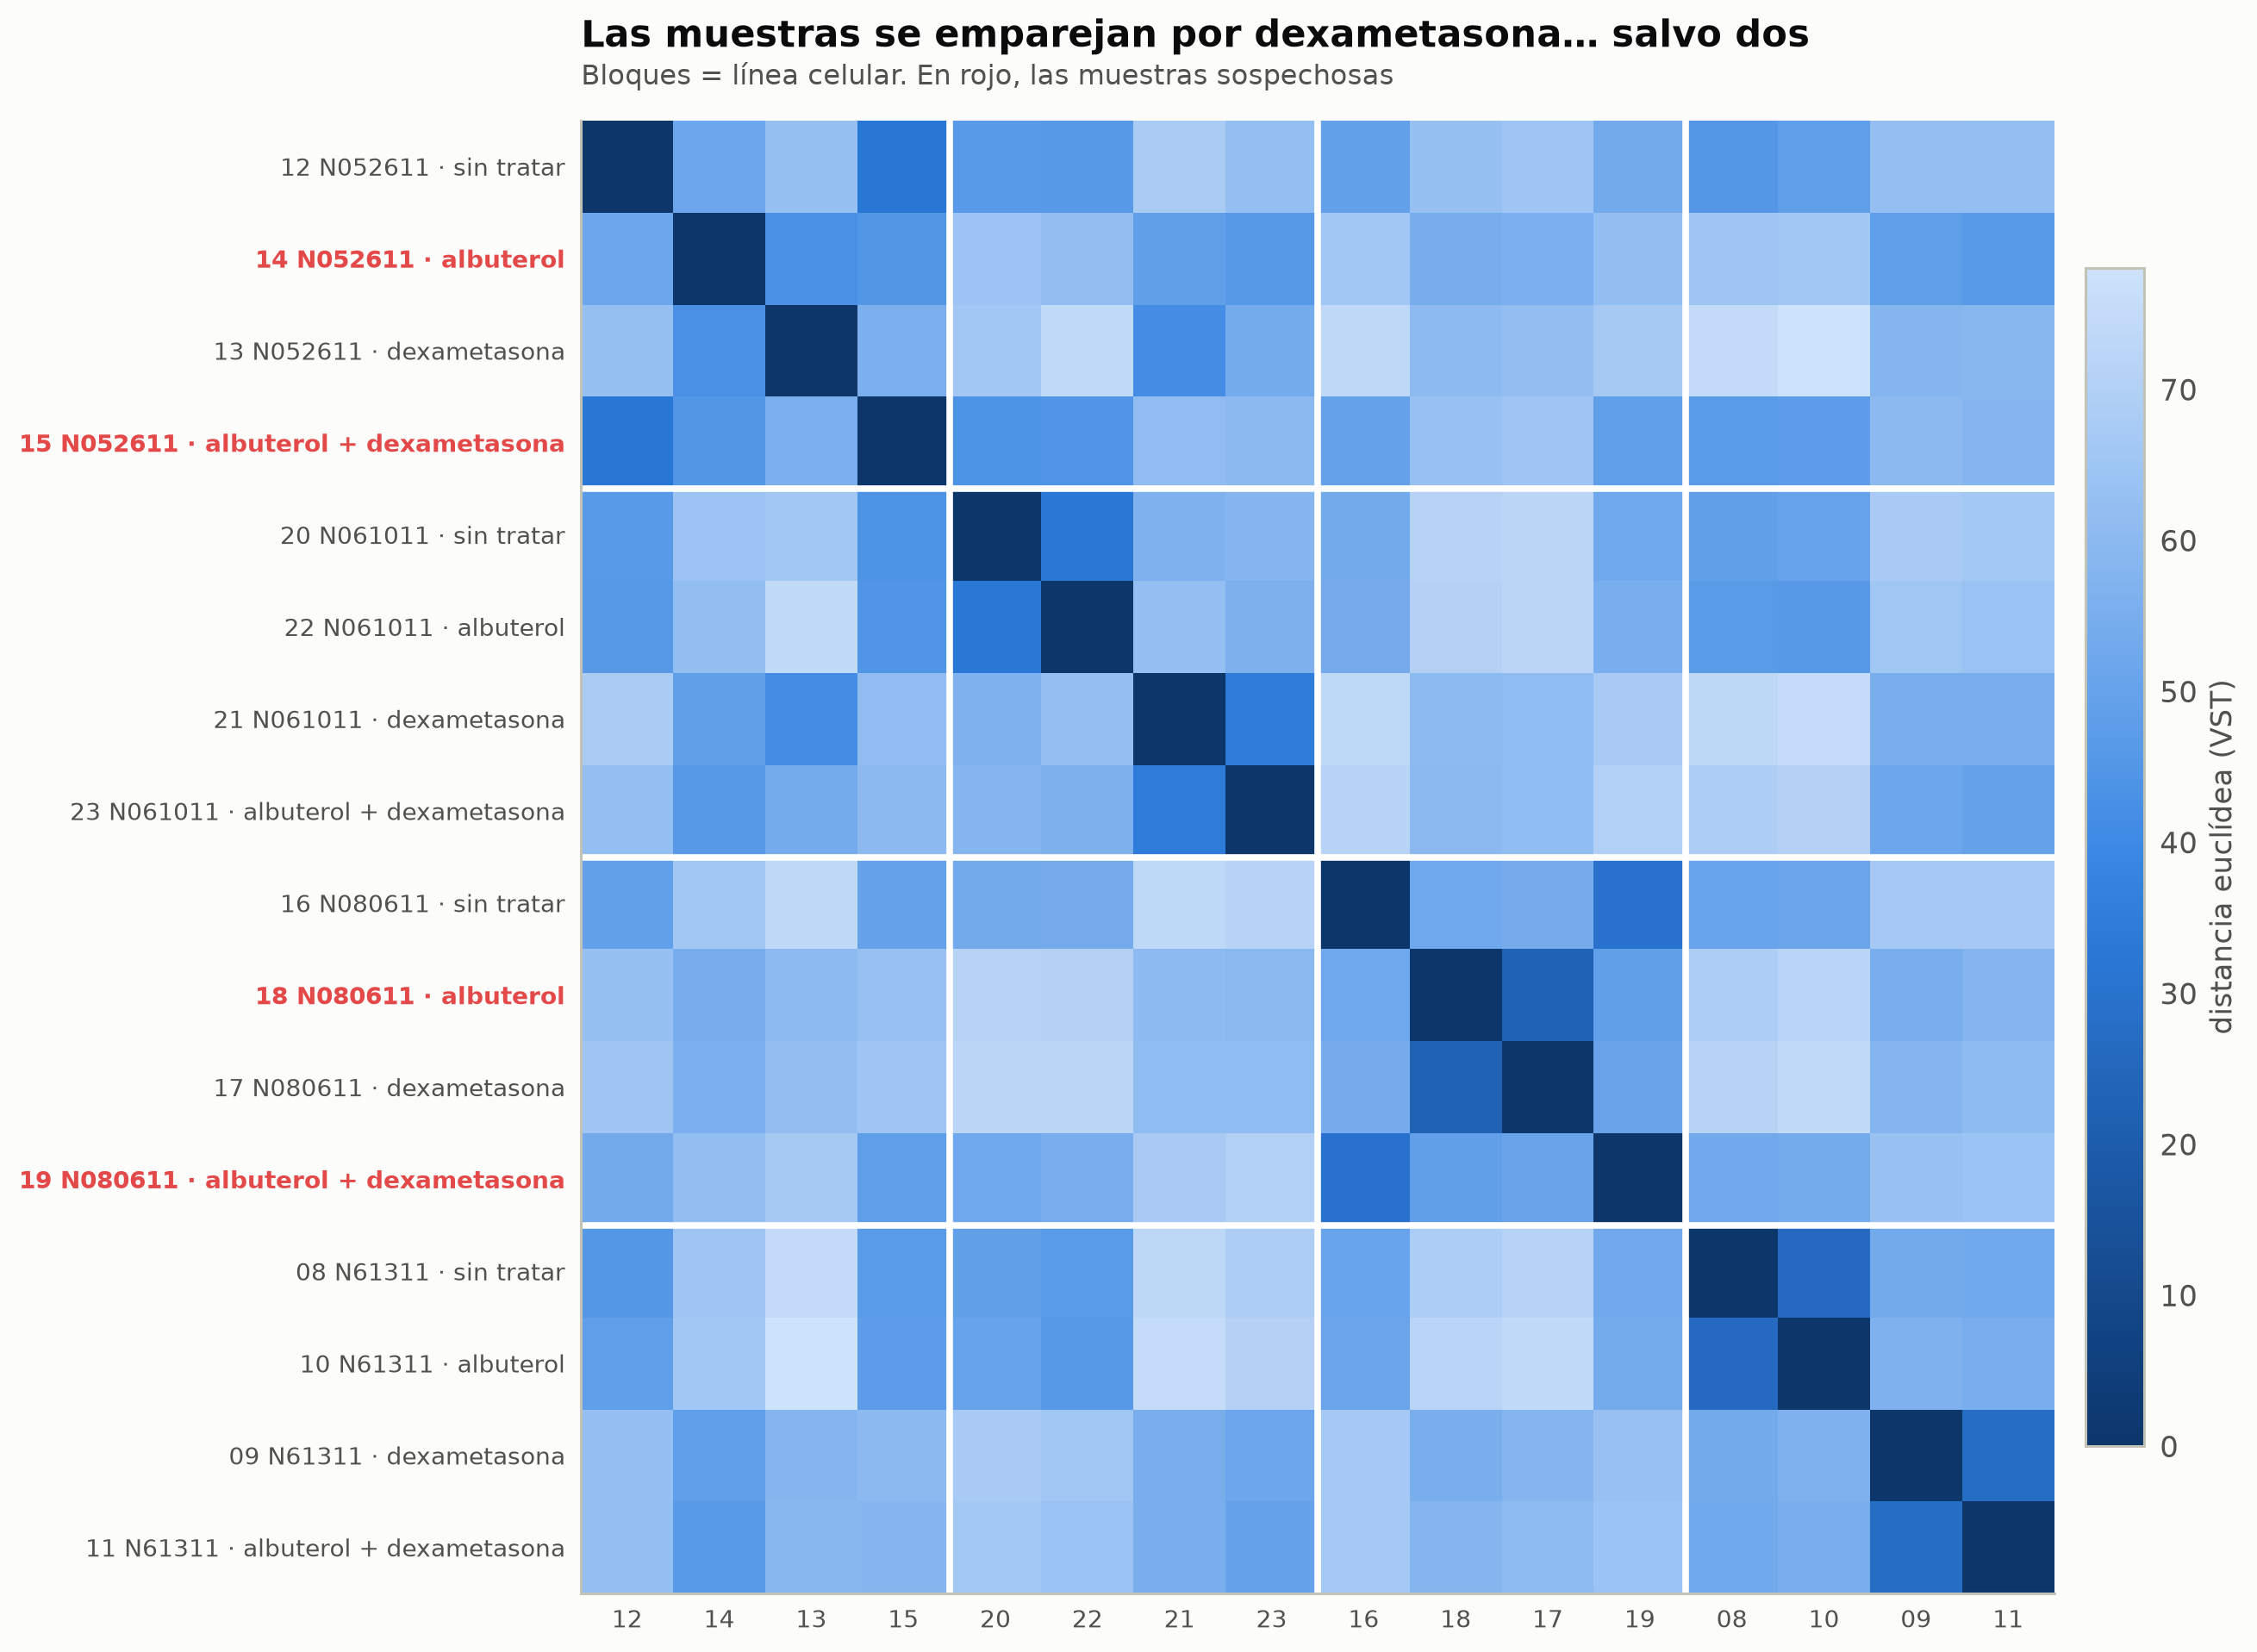

In [33]:
top500 = np.argsort(-V16.var(1))[:500]
Zc = V16[top500] - V16[top500].mean(1, keepdims=True)
U_, sv, Vt = np.linalg.svd(Zc, full_matrices=False)
pve = sv ** 2 / np.sum(sv ** 2)
PC = Vt[:3].T * sv[:3]
dex_lab = samples.treatment.str.contains("Dex").to_numpy(float)
for c_ in range(3):                                                    # orientación reproducible de los ejes
    if np.corrcoef(PC[:, c_], dex_lab if c_ == 0 else np.arange(16))[0, 1] < 0:
        PC[:, c_] *= -1
samples["PC1"], samples["PC2"] = PC[:, 0], PC[:, 1]
print("varianza explicada por PC1–PC4:", (pve[:4] * 100).round(1), "%")

# Distancias entre muestras, ordenadas por línea celular y tratamiento rotulado
ord_t = ["Untreated", "Albuterol", "Dexamethasone", "Albuterol_Dexamethasone"]
order = samples.assign(o=samples.treatment.map(ord_t.index)).sort_values(["cell", "o"]).index.to_numpy()
D = np.sqrt(((V16[:, order, None] - V16[:, None, order]) ** 2).sum(0))
labels = [f"{samples.run[i][-2:]} {samples.cell[i]} · {samples.tratamiento[i]}" for i in order]
fig, ax = plt.subplots(figsize=(11.5, 8.6))
im = ax.imshow(D, cmap=ec.CMAP_SEQ.reversed())
ax.set_xticks(range(16), [samples.run[i][-2:] for i in order], fontsize=9)
ax.set_yticks(range(16), labels, fontsize=9)
for b in range(4, 16, 4):
    ax.axhline(b - 0.5, color="white", lw=2.5); ax.axvline(b - 0.5, color="white", lw=2.5)
for y, i in enumerate(order):
    if samples.run[i] in ("SRR1039514", "SRR1039515", "SRR1039518", "SRR1039519"):
        ax.get_yticklabels()[y].set_color(ec.RED); ax.get_yticklabels()[y].set_fontweight("bold")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02); cb.set_label("distancia euclídea (VST)")
ec.title(ax, "Las muestras se emparejan por dexametasona… salvo dos",
         "Bloques = línea celular. En rojo, las muestras sospechosas")
plt.show()

> 🔎 **Qué observamos.** Los cuatro bloques de la diagonal son las cuatro líneas celulares: el donante es una fuente
> de variación enorme (por eso el diseño es pareado). Dentro de cada bloque, en N61311 y N061011 el patrón es
> limpio: «sin tratar» se parece a «albuterol» y «dexametasona» a «albuterol + dexametasona», es decir, las muestras
> se agrupan según **hayan recibido o no dexametasona**, y el albuterol apenas cambia el transcriptoma a las 18 h.
> En N052611 y N080611, en cambio, la muestra rotulada **«albuterol»** se parece a «dexametasona», y la rotulada
> **«albuterol + dexametasona»** se parece a «sin tratar».

### 🎛️ Interactivo: el PCA de las 16 muestras

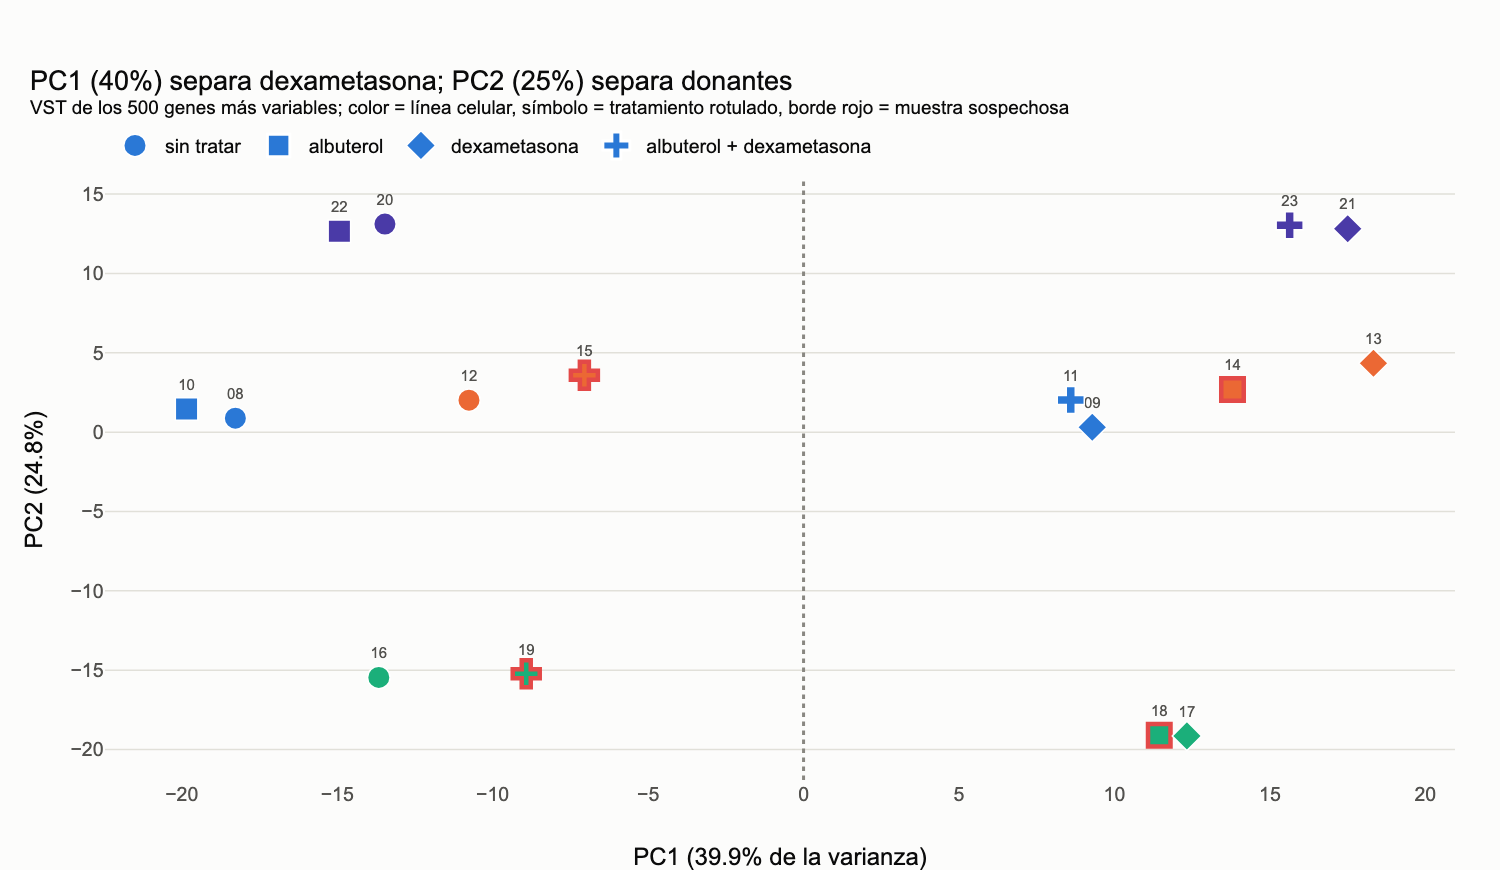

       run    cell              tratamiento   PC1   PC2
SRR1039508  N61311               sin tratar -18.3   0.9
SRR1039509  N61311             dexametasona   9.3   0.3
SRR1039510  N61311                albuterol -19.8   1.5
SRR1039511  N61311 albuterol + dexametasona   8.6   2.0
SRR1039512 N052611               sin tratar -10.8   2.0
SRR1039513 N052611             dexametasona  18.3   4.3
SRR1039514 N052611                albuterol  13.8   2.7
SRR1039515 N052611 albuterol + dexametasona  -7.1   3.6
SRR1039516 N080611               sin tratar -13.7 -15.5
SRR1039517 N080611             dexametasona  12.3 -19.1
SRR1039518 N080611                albuterol  11.4 -19.1
SRR1039519 N080611 albuterol + dexametasona  -8.9 -15.2
SRR1039520 N061011               sin tratar -13.5  13.1
SRR1039521 N061011             dexametasona  17.5  12.8
SRR1039522 N061011                albuterol -14.9  12.7
SRR1039523 N061011 albuterol + dexametasona  15.6  13.0


In [34]:
sym_map = {"Untreated": "circle", "Dexamethasone": "diamond", "Albuterol": "square", "Albuterol_Dexamethasone": "cross"}
cell_col = dict(zip(samples.cell.unique(), [ec.BLUE, ec.ORANGE, ec.AQUA, ec.VIOLET]))
fig = go.Figure()
for t in ord_t:
    d = samples[samples.treatment == t]
    sus = d.run.isin(["SRR1039514", "SRR1039515", "SRR1039518", "SRR1039519"])
    fig.add_trace(go.Scatter(
        x=d.PC1, y=d.PC2, mode="markers+text", name=TREAT_ES[t], text=[r[-2:] for r in d.run],
        textposition="top center", textfont=dict(size=10, color=ec.INK_2),
        marker=dict(symbol=sym_map[t], size=15, color=[cell_col[c] for c in d.cell],
                    line=dict(color=np.where(sus, ec.RED, "white"), width=np.where(sus, 3, 1))),
        customdata=np.column_stack([d.run, d.cell, d.tratamiento, np.where(sus, "⚠️ patrón de dexametasona "
                                    "no coincide con la etiqueta", "etiqueta coherente con el perfil")]),
        hovertemplate=("<b>%{customdata[0]}</b><br>línea celular: %{customdata[1]}<br>tratamiento rotulado: "
                       "%{customdata[2]}<br>PC1 = %{x:.1f} · PC2 = %{y:.1f}<br>%{customdata[3]}<extra></extra>")))
fig.update_layout(
    title=f"PC1 ({pve[0]:.0%}) separa dexametasona; PC2 ({pve[1]:.0%}) separa donantes<br><sup>VST de los 500 genes más "
          "variables; color = línea celular, símbolo = tratamiento rotulado, borde rojo = muestra sospechosa</sup>",
    xaxis_title=f"PC1 ({pve[0]:.1%} de la varianza)", yaxis_title=f"PC2 ({pve[1]:.1%})",
    height=580, margin=dict(t=120, l=70, r=30, b=60), legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.add_vline(x=0, line=dict(color=ec.MUTED, dash="dot"))
fig.show()
print(samples[["run", "cell", "tratamiento", "PC1", "PC2"]].round(1).to_string(index=False))

> 🔎 **Qué observamos.** PC1, el eje de mayor variación, separa las muestras en dos grupos de ocho: **con** y **sin**
> dexametasona. PC2 separa a los donantes. Los rombos (dexametasona) caen todos del lado derecho, y los círculos (sin
> tratar), todos del izquierdo. Pero dos cuadrados («albuterol»: SRR1039514 y SRR1039518) están del lado de la
> dexametasona, y dos cruces («albuterol + dexametasona»: SRR1039515 y SRR1039519) del lado sin dexametasona. Pase el
> cursor por ellas.

### 9.3 ¿Es la dexametasona? Una firma independiente

Un PCA puede engañar. Hagamos una prueba más dirigida y, sobre todo, **independiente** de las muestras sospechosas:

1. Definimos la **firma de dexametasona** usando **sólo** las dos líneas «limpias» (N61311 y N061011): los 200 genes
   con mayor cambio $|\Delta\mathrm{VST}|$ entre dexametasona y sin tratar, promediado en las dos líneas.
2. Para **cada** muestra tratada de las cuatro líneas calculamos su cambio $\mathbf d_j$ respecto a la muestra sin
   tratar de **su misma línea**, y lo comparamos con la firma $\mathbf f$ de dos maneras: la **correlación** $r$
   (¿va en la misma dirección?) y la **amplitud** $b_j=\mathbf d_j^\top\mathbf f/\mathbf f^\top\mathbf f$, la
   pendiente de la regresión de $\mathbf d_j$ sobre $\mathbf f$ (¿con qué intensidad? 1 = respuesta completa).

Si una muestra recibió dexametasona, su amplitud debería rondar 1; si no, cercana a 0. Además miramos los genes
clásicos de respuesta al receptor de glucocorticoides: *FKBP5*, *ZBTB16*, *TSC22D3* (GILZ), *PER1*, *KLF15*, *DUSP1*
y *CRISPLD2* (el gen que da título al trabajo de Himes et al.).

In [35]:
untr_of = {c: int(np.where((samples.cell == c) & (samples.treatment == "Untreated"))[0][0]) for c in samples.cell.unique()}
clean = ["N61311", "N061011"]
dex_of = {c: int(np.where((samples.cell == c) & (samples.treatment == "Dexamethasone"))[0][0]) for c in samples.cell.unique()}
expressed = Qn.mean(1) > 10
delta_sig = np.mean([V16[:, dex_of[c]] - V16[:, untr_of[c]] for c in clean], axis=0)
sig_genes = np.where(expressed)[0][np.argsort(-np.abs(delta_sig[expressed]))[:200]]
print(f"firma: 200 genes; {np.sum(delta_sig[sig_genes] > 0)} suben y {np.sum(delta_sig[sig_genes] < 0)} bajan con dexametasona")

rows = []
for j in range(16):
    if samples.treatment[j] == "Untreated":
        continue
    dj = V16[sig_genes, j] - V16[sig_genes, untr_of[samples.cell[j]]]
    ds = delta_sig[sig_genes]
    rows.append(dict(run=RUNS[j], linea=samples.cell[j], rotulo=samples.tratamiento[j],
                     r_firma=np.corrcoef(dj, ds)[0, 1],
                     amplitud=np.dot(dj, ds) / np.dot(ds, ds),       # pendiente: 1 = respuesta de la firma completa
                     en_la_firma="sí" if samples.cell[j] in clean and samples.treatment[j] == "Dexamethasone" else "no"))
score = pd.DataFrame(rows)
score.round(3)

firma: 200 genes; 145 suben y 55 bajan con dexametasona


,run,linea,rotulo,r_firma,amplitud,en_la_firma
0,SRR1039509,N61311,dexametasona,0.987,0.954,sí
1,SRR1039510,N61311,albuterol,-0.225,-0.031,no
2,SRR1039511,N61311,albuterol + dexametasona,0.967,0.940,no
3,SRR1039513,N052611,dexametasona,0.962,0.918,no
4,SRR1039514,N052611,albuterol,0.964,0.853,no
5,SRR1039515,N052611,albuterol + dexametasona,0.509,0.164,no
6,SRR1039517,N080611,dexametasona,0.914,0.800,no
7,SRR1039518,N080611,albuterol,0.924,0.780,no
8,SRR1039519,N080611,albuterol + dexametasona,0.604,0.154,no
9,SRR1039521,N061011,dexametasona,0.988,1.046,sí


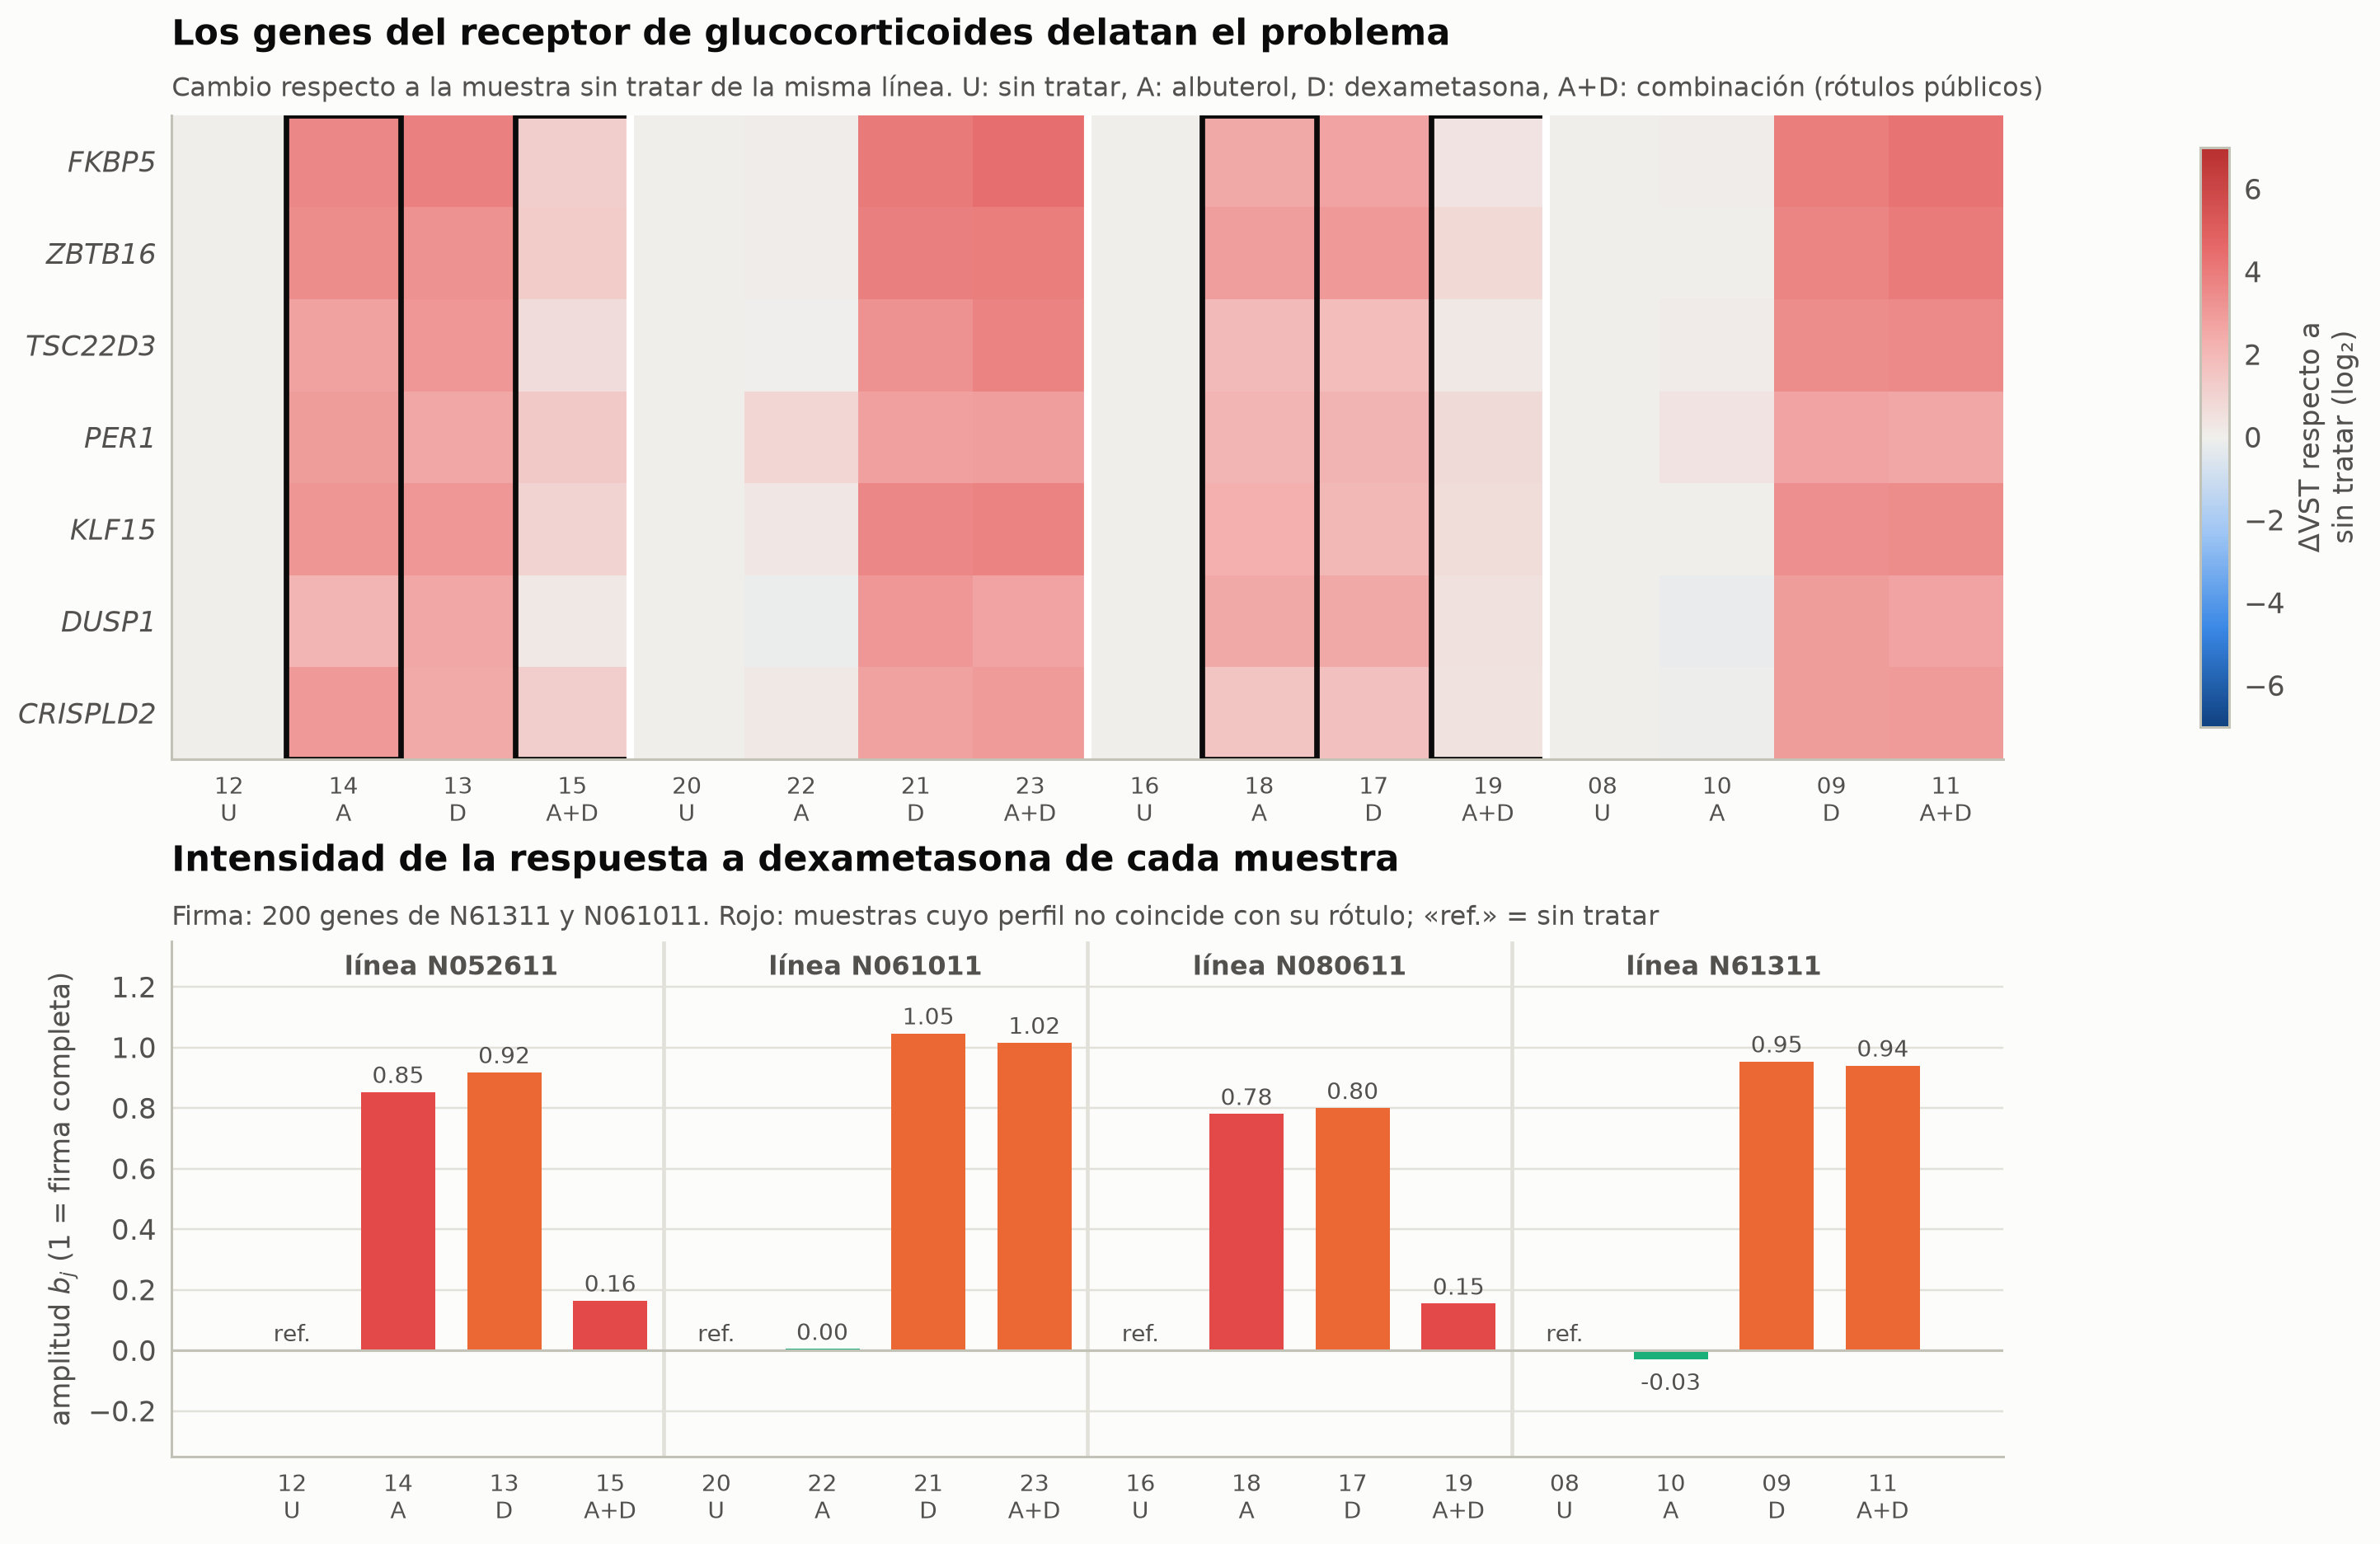

In [36]:
GR = ["FKBP5", "ZBTB16", "TSC22D3", "PER1", "KLF15", "DUSP1", "CRISPLD2"]
gi = [int(np.where(SYMBOL == g)[0][0]) for g in GR]
H = np.array([[V16[i, j] - V16[i, untr_of[samples.cell[j]]] for j in order] for i in gi])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8.4), gridspec_kw=dict(height_ratios=[1.25, 1]))
im = ax1.imshow(H, cmap=ec.CMAP_DIV, vmin=-7, vmax=7, aspect="auto")
ax1.set_yticks(range(len(GR)), GR, fontstyle="italic")
ax1.set_xticks(range(16), [f"{samples.run[i][-2:]}\n{['U', 'A', 'D', 'A+D'][ord_t.index(samples.treatment[i])]}" for i in order], fontsize=9)
for b in range(4, 16, 4):
    ax1.axvline(b - 0.5, color="white", lw=3)
for x, i in enumerate(order):
    if samples.run[i] in ("SRR1039514", "SRR1039515", "SRR1039518", "SRR1039519"):
        ax1.add_patch(plt.Rectangle((x - 0.5, -0.5), 1, len(GR), fill=False, ec=ec.INK, lw=2.2))
ax1.grid(False)
cb = fig.colorbar(im, ax=ax1, shrink=0.9, pad=0.01); cb.set_label("ΔVST respecto a\nsin tratar (log₂)")
ec.title(ax1, "Los genes del receptor de glucocorticoides delatan el problema",
         "Cambio respecto a la muestra sin tratar de la misma línea. U: sin tratar, A: albuterol, D: dexametasona, "
         "A+D: combinación (rótulos públicos)")
sc_ = score.set_index("run").reindex([RUNS[i] for i in order])
xb_ = np.arange(16)
colors_b = [ec.MUTED if pd.isna(v) else (ec.RED if RUNS[i] in ("SRR1039514", "SRR1039515", "SRR1039518", "SRR1039519")
            else (ec.ORANGE if "dexa" in samples.tratamiento[i] else ec.AQUA)) for v, i in zip(sc_.amplitud, order)]
ax2.bar(xb_, sc_.amplitud.fillna(0), color=colors_b, width=0.7)
for x, v, i in zip(xb_, sc_.amplitud, order):
    ax2.text(x, (0 if pd.isna(v) else v) + (0.03 if (pd.isna(v) or v >= 0) else -0.1), "ref." if pd.isna(v) else f"{v:.2f}",
             ha="center", fontsize=9, color=ec.INK_2)
ax2.set_xticks(xb_, [f"{samples.run[i][-2:]}\n{['U', 'A', 'D', 'A+D'][ord_t.index(samples.treatment[i])]}" for i in order], fontsize=9)
for b in range(4, 16, 4):
    ax2.axvline(b - 0.5, color=ec.GRID, lw=1.5)
ax2.set_ylim(-0.35, 1.35); ax2.axhline(0, color=ec.BASELINE, lw=1)
for k_, c in enumerate(samples.cell[order][::4]):
    ax2.text(k_ * 4 + 1.5, 1.24, f"línea {c}", ha="center", fontsize=10.5, fontweight="bold", color=ec.INK_2)
ax2.set_ylabel("amplitud $b_j$ (1 = firma completa)")
ec.title(ax2, "Intensidad de la respuesta a dexametasona de cada muestra",
         "Firma: 200 genes de N61311 y N061011. Rojo: muestras cuyo perfil no coincide con su rótulo; «ref.» = sin tratar")
plt.show()

> 🔎 **Qué observamos.** En las líneas limpias el patrón es de manual: los siete genes se encienden (rojo) en «D» y
> «A+D» y no en «A». *ZBTB16* sube más de 6 unidades de $\log_2$ (≈ ×100). En N052611 y N080611 los genes se
> encienden con fuerza en la muestra rotulada **«A»** (albuterol solo) y apenas se mueven en la rotulada **«A+D»**.
> La firma independiente confirma el cuadro. Las muestras de dexametasona de N052611 y N080611, que **no** se usaron
> para construirla, dan $r\approx0{,}9$ y amplitud 0,8–0,9: la firma funciona en líneas nuevas. Las rotuladas
> «albuterol» en esas líneas (SRR1039514, SRR1039518) dan exactamente lo mismo ($r\approx0{,}92$–$0{,}96$,
> amplitud ≈ 0,8), mientras que las rotuladas «albuterol + dexametasona» (SRR1039515, SRR1039519) muestran una
> respuesta **débil**: amplitud ≈ 0,15 y $r\approx0{,}5$–$0{,}6$. En las líneas limpias, el albuterol solo da
> amplitud ≈ 0 y la combinación ≈ 1.

**Interpretación prudente.** El patrón **sugiere** que en las líneas N052611 y N080611 las etiquetas «albuterol» y
«albuterol + dexametasona» están **intercambiadas** en los metadatos públicos: es **compatible con** un error al rotular
los tubos o al subir los datos. No podemos demostrarlo desde aquí. Una inducción débil residual en SRR1039515 y
SRR1039519 (por ejemplo, *FKBP5* algo por encima de su muestra sin tratar) deja abiertas otras explicaciones, como una
exposición distinta o una contaminación cruzada; sólo los autores, con sus registros de laboratorio, podrían
confirmarlo. Lo que sí podemos decir es que **analizar el efecto del albuterol con estas etiquetas sería arriesgado**.
Por eso el análisis principal del Módulo 11, como la viñeta de DESeq2, usa **sólo sin tratar frente a
dexametasona**, cuyas etiquetas son coherentes con los datos en las cuatro líneas.

> 💡 **La lección de control de calidad.** Ninguna prueba de expresión diferencial habría detectado esto: con las
> etiquetas intercambiadas, DESeq2 habría dado resultados «válidos» para una pregunta mal planteada. Los errores de
> etiquetado no son raros en los repositorios públicos. Mire siempre el PCA y las distancias entre muestras antes de
> modelar, y compruebe genes marcadores de efecto conocido (aquí, la respuesta clásica a glucocorticoides; en otros
> estudios, *XIST* y genes del cromosoma Y para el sexo).

> ✅ **Compruebe su comprensión.** ¿Por qué construimos la firma sólo con N61311 y N061011 y no con las cuatro
> líneas? *(Para que la prueba sea independiente de las muestras bajo sospecha: si la firma incluyera sus
> dexametasonas, cualquier rareza de esas líneas contaminaría la referencia con la que las juzgamos.)*

## 10. Ejercicios

**Ejercicio 1 · Robustez de la mediana de razones.** Tome la tabla del ejemplo a mano (genes g1–g5) y añada un gen
g6 con conteos $(100, 220, 1400)$: un gen que se dispara en la muestra 3. (a) Calcule los factores de tamaño con la
mediana de razones y compárelos con $(0{,}691;\ 1{,}525;\ 0{,}939)$. (b) Calcule los factores «por total» (suma de
cada columna dividida por la media geométrica de las sumas) con y sin g6. ¿Cuál de los dos métodos se deja arrastrar
por g6?

**Ejercicio 2 · ¿Poisson o binomial negativa?** Un gen tiene $\mu=100$ lecturas en réplicas biológicas y $\alpha=0{,}05$.
(a) Calcule la varianza y el coeficiente de variación. (b) Calcule $P(K\geq150)$ bajo Poisson y bajo la NB.
(c) ¿Qué profundidad (factor sobre $\mu$) haría falta para que el ruido de Poisson fuera sólo el 1 % de la varianza?

**Ejercicio 3 · Cuánto contraer.** Con el gen de media 20 del libro (sección 8.1), recalcule
$\hat\alpha^{\mathrm{MAP}}$ con varianzas previas $\sigma_d^2\in\{0{,}05;\ 0{,}257;\ 1;\ 5\}$. Dibuje
$\hat\alpha^{\mathrm{MAP}}$ frente a $\sigma_d^2$ y marque la tendencia (0,136), la estimación gen a gen (0,351) y la
verdad (0,162).

**Ejercicio 4 · Control de calidad con la escala equivocada.** Repita el PCA de la sección 9.2 usando $\log_2(q+1)$ en
lugar de la VST, con los 500 genes más variables. (a) ¿Qué porcentaje de varianza explica PC1? (b) ¿Qué fracción de
esos 500 genes tiene una media normalizada menor que 20, en cada escala? (c) ¿Se sigue viendo el intercambio de
etiquetas?

In [37]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
K_ex = np.vstack([K_toy, [100, 220, 1400]])
print("mediana de razones sin g6:", size_factors(K_toy).round(3))
print("mediana de razones con g6:", size_factors(K_ex).round(3))
def total_factors(K):
    tot = K.sum(0)
    return tot / np.exp(np.log(tot).mean())
print("por total sin g6:        ", total_factors(K_toy).round(3))
print("por total con g6:        ", total_factors(K_ex).round(3))
# La mediana de razones apenas cambia (0,939 -> 0,962): g6 es un voto entre cinco y cae en una cola. El factor por
# total de la muestra 3 salta de 0,93 a 1,22 (+31 %) y los de las muestras 1 y 2 bajan: g6 aporta 1 400 lecturas e
# "infla" la pizza, de modo que los demás genes de la muestra 3 parecerían reprimidos si normalizáramos por total.
# Es el efecto de composición en miniatura.

mediana de razones sin g6: [0.691 1.525 0.939]
mediana de razones con g6: [0.687 1.512 0.962]
por total sin g6:         [0.704 1.528 0.93 ]
por total con g6:         [0.615 1.336 1.218]


In [38]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
mu_e, a_e = 100.0, 0.05
var_e = mu_e + a_e * mu_e ** 2
print(f"(a) Var = {var_e:.0f}; CV = {np.sqrt(var_e) / mu_e:.1%} (Poisson sola: {1 / np.sqrt(mu_e):.0%})")
r_e = 1 / a_e
print(f"(b) P(K ≥ 150): Poisson = {stats.poisson.sf(149, mu_e):.2e};  NB = {stats.nbinom.sf(149, r_e, r_e / (r_e + mu_e)):.3f}")
# (c) ruido de Poisson / varianza = mu / (mu + a mu²) = 1 / (1 + a mu) = 0,01  ->  a·mu = 99  ->  mu = 1980
mu_need = 99 / a_e
print(f"(c) hace falta μ = {mu_need:.0f}, es decir ×{mu_need / mu_e:.1f} de profundidad: a partir de ahí, más lecturas "
      "no mejoran casi nada; sólo más réplicas reducen el término biológico")

(a) Var = 600; CV = 24.5% (Poisson sola: 10%)
(b) P(K ≥ 150): Poisson = 1.88e-06;  NB = 0.032
(c) hace falta μ = 1980, es decir ×19.8 de profundidad: a partir de ahí, más lecturas no mejoran casi nada; sólo más réplicas reducen el término biológico


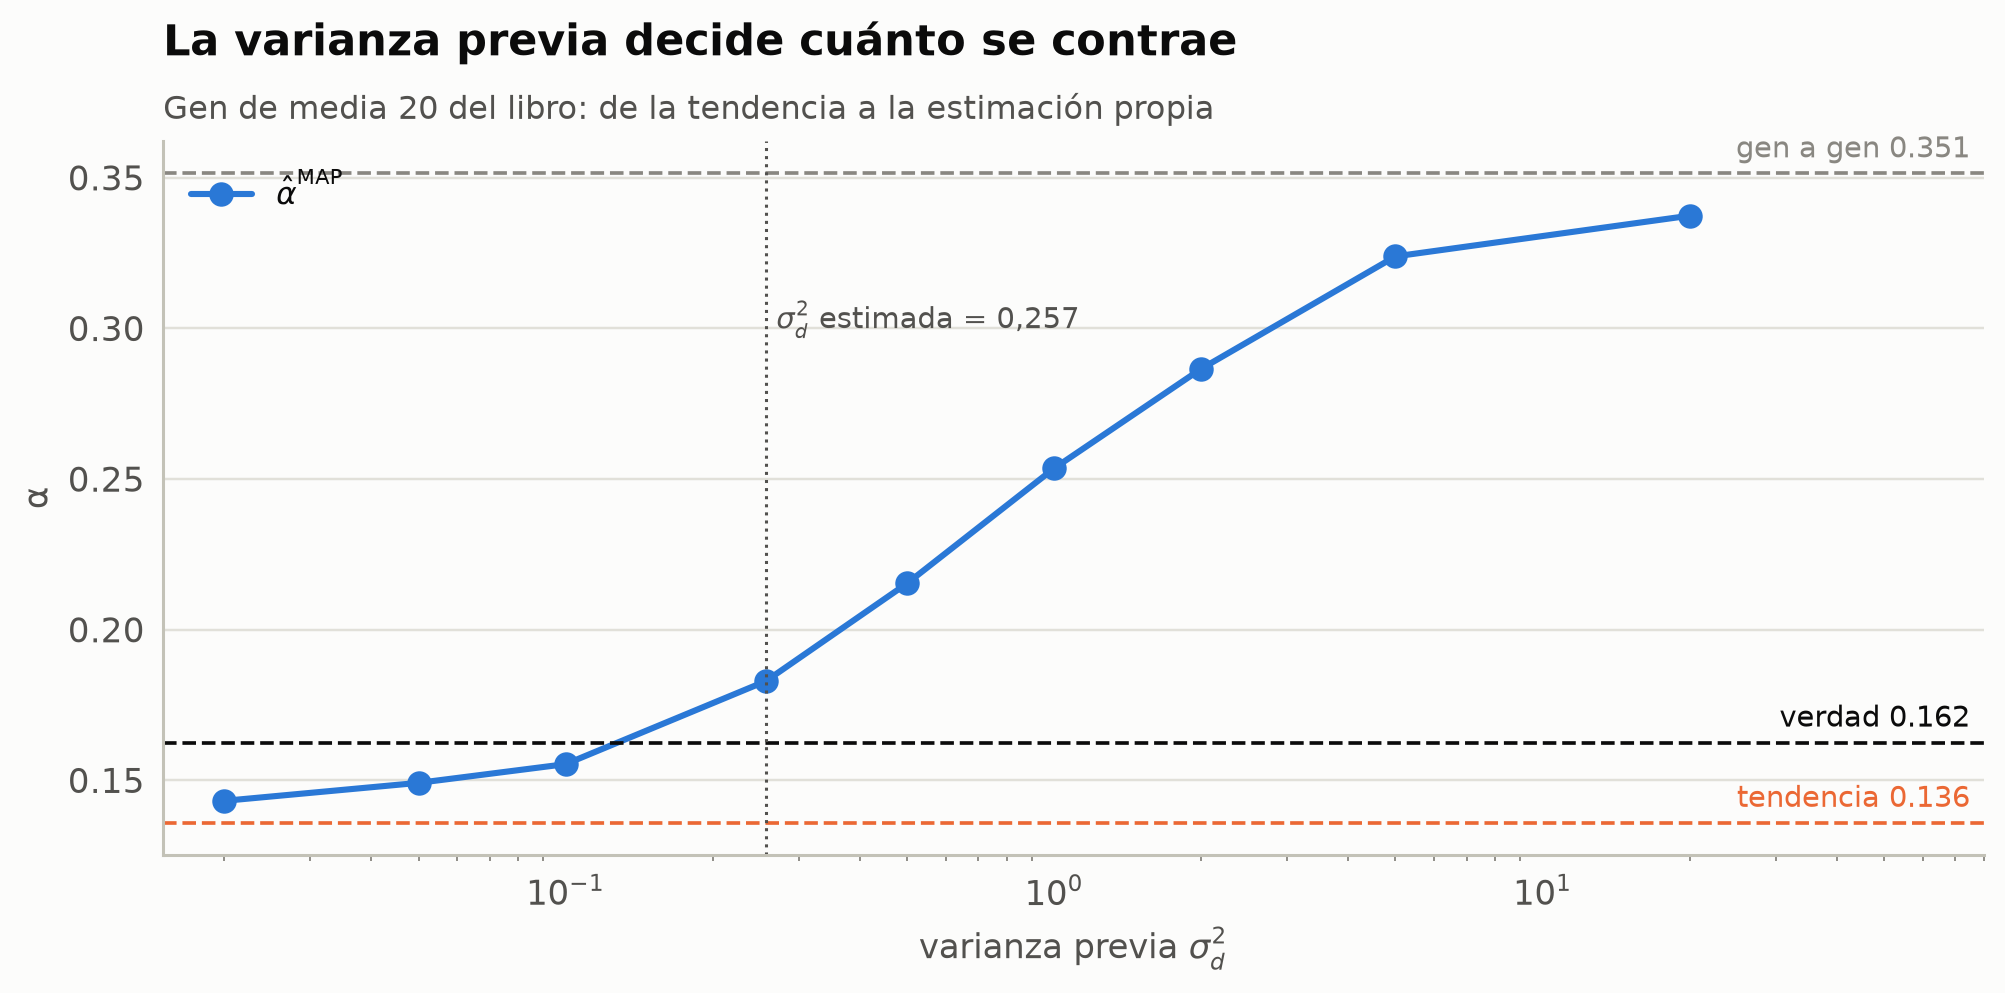

In [39]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
s2_list = np.array([0.02, 0.05, 0.1, 0.257, 0.5, 1, 2, 5, 20])
maps = []
for s2 in s2_list:
    lp_ = -0.5 * (np.log(GRID_B := np.exp(np.linspace(np.log(1e-4), np.log(20), 300))) - np.log(a_tr_b[g20])) ** 2 / s2
    maps.append(GRID_B[np.argmax(LLb[g20] + lp_)])
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(s2_list, maps, "o-", color=ec.BLUE, lw=2, label="$\\hat\\alpha^{\\mathrm{MAP}}$")
for v, c, t in [(a_tr_b[g20], ec.ORANGE, "tendencia"), (a_gw_b[g20], ec.MUTED, "gen a gen"), (true_b[g20], ec.INK, "verdad")]:
    ax.axhline(v, color=c, ls="--", lw=1.2); ax.text(75, v + 0.003, f"{t} {v:.3f}", va="bottom", ha="right", color=c, fontsize=9.5)
ax.axvline(0.257, color=ec.INK_2, ls=":", lw=1); ax.text(0.27, 0.3, "$\\sigma_d^2$ estimada = 0,257", fontsize=9.5, color=ec.INK_2)
ax.set_xscale("log"); ax.set_xlim(0.015, 80); ax.set_xlabel("varianza previa $\\sigma_d^2$"); ax.set_ylabel("α")
ax.legend(loc="upper left", frameon=False)
ec.title(ax, "La varianza previa decide cuánto se contrae", "Gen de media 20 del libro: de la tendencia a la estimación propia")
plt.show()
# Con σ²_d pequeña el MAP se pega a la tendencia; con σ²_d grande, a la estimación gen a gen. El valor estimado a
# partir de los datos (0,257) cae en una zona intermedia que, para este gen, queda muy cerca de la verdad.

In [40]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
for name, M_ in [("log2(q+1)", L16), ("VST", V16)]:
    t5 = np.argsort(-M_.var(1))[:500]
    Z_ = M_[t5] - M_[t5].mean(1, keepdims=True)
    u_, s_, vt_ = np.linalg.svd(Z_, full_matrices=False)
    pc1 = vt_[0] * s_[0]
    if np.corrcoef(pc1, dex_lab)[0, 1] < 0:
        pc1 = -pc1
    low = np.mean(Qn[t5].mean(1) < 20)
    sus = {RUNS[j][-2:]: round(pc1[j], 1) for j in range(16) if RUNS[j] in ("SRR1039514", "SRR1039515", "SRR1039518", "SRR1039519")}
    print(f"{name:<10} PC1 = {s_[0] ** 2 / np.sum(s_ ** 2):.1%} · genes con media < 20 entre los 500: {low:.0%} · PC1 de sospechosas: {sus}")
# Con log2(q+1), casi la mitad de los 500 genes "más variables" tiene media < 20 (con la VST, ninguno): su varianza
# es ruido de Poisson amplificado por el logaritmo. PC1 baja del 40 % al 28 % y deja de ser el eje de la
# dexametasona: las muestras sospechosas ya no se ordenan de forma coherente y el intercambio no se vería. La escala
# de transformación puede ocultar un problema de calidad real.

log2(q+1)  PC1 = 27.9% · genes con media < 20 entre los 500: 45% · PC1 de sospechosas: {'14': np.float64(-10.4), '15': np.float64(13.0), '18': np.float64(-26.1), '19': np.float64(4.5)}
VST        PC1 = 39.9% · genes con media < 20 entre los 500: 0% · PC1 de sospechosas: {'14': np.float64(13.8), '15': np.float64(-7.1), '18': np.float64(11.4), '19': np.float64(-8.9)}


## 📌 Resumen

* El conteo esperado depende de la profundidad **y** de la composición: $\mathbb E[K_{ij}]=N_j\mu_{ij}L_i/S_j$
  (11-composición). CPM corrige $N_j$ pero no $S_j$: si unos pocos genes se disparan, todos los demás parecen bajar
  (simulación del libro: centro en $-0{,}485$, dilución teórica $-0{,}486$).
* **TMM** (edgeR) promedia, con pesos de varianza inversa, los $M$ que sobreviven a un recorte del 30 % por cola de $M$
  y 5 % de $A$ (11-tmm): $\log_2 f=-0{,}461$ en el ejemplo. La **mediana de razones** (DESeq2) usa la media
  geométrica como pseudomuestra (11-mor): $\hat s=(0{,}691;\ 1{,}525;\ 0{,}939)$ en el ejemplo a mano. Ambos suponen
  que la mayoría de los genes no cambia; si no es así, hacen falta *spike-ins*.
* En *airway*, los dos métodos coinciden (correlación 0,999) y corrigen hasta un ±6 % de composición además de la
  profundidad; las muestras con dexametasona quedan sistemáticamente por debajo de su pareja sin tratar.
* La **binomial negativa** es una mezcla gamma-Poisson: $\operatorname{Var}=\mu+\alpha\mu^2$ (11-nbvar). $\mu$ es ruido
  de muestreo, $\alpha\mu^2$ variación biológica; $\mathrm{CV}^2=1/\mu+\alpha$ tiene un piso que sólo las réplicas
  vencen. Con $\mu=20$, $\alpha=0{,}2$: $P(K\geq40)$ pasa de $5\times10^{-5}$ (Poisson) a $0{,}044$.
* DESeq2 ajusta un **GLM NB** con enlace log y factor de tamaño como desplazamiento (11-glm) por IRLS; el peso de una
  observación está acotado por $1/\alpha$ (11-irls). El diseño pareado `~ cell + dex` quita la variación entre donantes.
* **Dispersión en tres pasos**: gen a gen con Cox-Reid → tendencia $a_0+a_1/\bar\mu$ → MAP con previa log-normal
  de varianza $\sigma_d^2=\mathrm{sd}_{\text{rob}}^2-\psi_1(\nu/2)$ (11-disp, 11-map). Libro: $a_0=0{,}048$,
  $a_1=1{,}76$; gen de media 20: $0{,}351\to0{,}183$ (verdad $0{,}162$); ECM en log de 6,6 a 0,17.
* En *airway* (3 g.l. residuales): $a_0\approx0{,}013$ (CV biológico ~11 %, células en cultivo), ~30 % de
  estimaciones gen a gen en el suelo y atípicos dominados por **pseudogenes** con lecturas ambiguas.
* Para mirar, **VST** (forma cerrada con $a_0,a_1$), nunca para modelar. El PCA y las distancias de las 16 muestras
  muestran que PC1 es la dexametasona y **sugieren un intercambio de etiquetas** albuterol ↔ albuterol +
  dexametasona en N052611 y N080611; por eso el Módulo 11 compara sólo sin tratar frente a dexametasona.

## 📚 Lecturas recomendadas

* Robinson, M. D. y Oshlack, A. (2010). A scaling normalization method for differential expression analysis of
  RNA-seq data. *Genome Biology*, 11(3), R25. https://doi.org/10.1186/gb-2010-11-3-r25
* Anders, S. y Huber, W. (2010). Differential expression analysis for sequence count data. *Genome Biology*, 11(10),
  R106. https://doi.org/10.1186/gb-2010-11-10-r106
* Love, M. I., Huber, W. y Anders, S. (2014). Moderated estimation of fold change and dispersion for RNA-seq data
  with DESeq2. *Genome Biology*, 15(12), 550. https://doi.org/10.1186/s13059-014-0550-8
* Robinson, M. D., McCarthy, D. J. y Smyth, G. K. (2010). edgeR: a Bioconductor package for differential expression
  analysis of digital gene expression data. *Bioinformatics*, 26(1), 139–140. https://doi.org/10.1093/bioinformatics/btp616
* McCarthy, D. J., Chen, Y. y Smyth, G. K. (2012). Differential expression analysis of multifactor RNA-Seq
  experiments with respect to biological variation. *Nucleic Acids Research*, 40(10), 4288–4297.
  https://doi.org/10.1093/nar/gks042
* Cox, D. R. y Reid, N. (1987). Parameter orthogonality and approximate conditional inference. *Journal of the Royal
  Statistical Society: Series B*, 49(1), 1–18. https://doi.org/10.1111/j.2517-6161.1987.tb01422.x
* Law, C. W., Chen, Y., Shi, W. y Smyth, G. K. (2014). voom: precision weights unlock linear model analysis tools
  for RNA-seq read counts. *Genome Biology*, 15(2), R29. https://doi.org/10.1186/gb-2014-15-2-r29
* Evans, C., Hardin, J. y Stoebel, D. M. (2018). Selecting between-sample RNA-Seq normalization methods from the
  perspective of their assumptions. *Briefings in Bioinformatics*, 19(5), 776–792. https://doi.org/10.1093/bib/bbx008
* Himes, B. E. et al. (2014). RNA-Seq transcriptome profiling identifies CRISPLD2 as a glucocorticoid responsive gene
  that modulates cytokine function in airway smooth muscle cells. *PLoS ONE*, 9(6), e99625.
  https://doi.org/10.1371/journal.pone.0099625
* Wilks, C. et al. (2021). recount3: summaries and queries for large-scale RNA-seq expression and splicing. *Genome
  Biology*, 22, 323. https://doi.org/10.1186/s13059-021-02533-6
* Holmes, S. y Huber, W. (2019). *Modern Statistics for Modern Biology*. Cambridge University Press (capítulo 8,
  datos de conteo de alto rendimiento).

In [41]:
print(f"⏱️ Tiempo total de ejecución del notebook: {time.time() - t_start:.0f} s")

⏱️ Tiempo total de ejecución del notebook: 28 s


---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)